# ICT3902C Capstone Project
## Economic Event-Driven Forex Trading Assistant using Machine Learning

**Muhammad Mursyid Bin Hassan | 2300435 | Supervisor: Dr Li Xiaorong**

---

Predicting daily EUR/USD direction from macroeconomic event surprises, 2007 to 2025.

**Finding: statistically detectable, economically insufficient.** A Random Forest on 48
hybrid features achieves a mean fold AUC of 0.5389 across 36 non-overlapping out-of-sample
folds, above random at one-sided p = 0.0003. No strategy built on that edge beats Buy and
Hold after transaction costs.

### Contents

1. Data Collection
2. Economic Event Data
3. Feature Engineering
4. Model Training and Hyperparameter Selection
5. Evaluation Design
6. Walk-Forward Evaluation
7. Trade Signal Generation and Backtest
8. Feature Importance and Interpretability
9. Deployment Export
10. Summary and Limitations

Restart kernel and run all.

In [1]:
# core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# sklearn models and utilities
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    classification_report, roc_auc_score
)
from sklearn.inspection import permutation_importance

# interpretability
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. Data Collection

Daily EUR/USD prices come from Yahoo Finance via `yfinance`.

Daily data is the right frequency here. The economic events used as
features (CPI, NFP, FOMC, ECB) move the market over one to three days,
not within a single trading session.

In [2]:
import yfinance as yf

# download EUR/USD daily OHLCV
START_DATE = '2007-01-01'
END_DATE   = '2026-01-01'

raw = yf.download('EURUSD=X', start=START_DATE, end=END_DATE,
                  interval='1d', progress=False)

# yfinance occasionally returns multi-level columns; flatten if so
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.columns = ['open', 'high', 'low', 'close', 'volume']
df.dropna(inplace=True)
df.sort_index(inplace=True)

print(f"Downloaded {len(df)} trading days")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Downloaded 4927 trading days
Date range: 2007-01-01 to 2025-12-31


,open,high,low,close,volume
Date,,,,,
2007-01-01,1.319801,1.321999,1.317593,1.321895,0
2007-01-02,1.321895,1.329398,1.321755,1.327598,0
2007-01-03,1.327598,1.329098,1.315547,1.317107,0
2007-01-04,1.317107,1.318096,1.308096,1.309295,0
2007-01-05,1.309003,1.310393,1.298398,1.298499,0


In [3]:
# quick sanity check on the downloaded data
print("Close price summary:")
print(df['close'].describe().round(4))

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Positive days (close > previous close): {(df['close'].pct_change() > 0).mean()*100:.1f}%")

Close price summary:
count    4927.0000
mean        1.2211
std         0.1358
min         0.9596
25%         1.1076
50%         1.1800
75%         1.3336
max         1.5988
Name: close, dtype: float64

Missing values: 0
Positive days (close > previous close): 49.7%


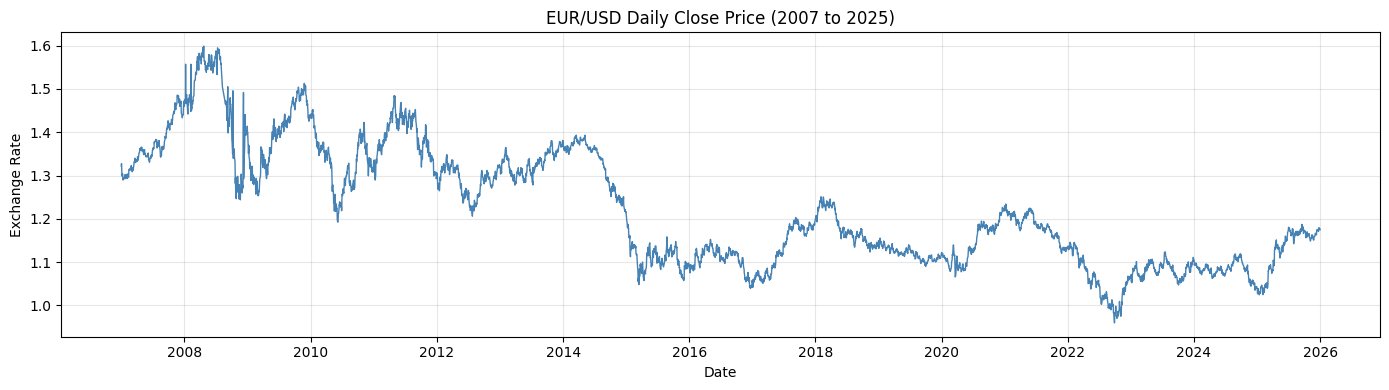

In [4]:
# visualise the price series
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['close'], color='steelblue', lw=1)
plt.title(f'EUR/USD Daily Close Price ({df.index[0].year} to {df.index[-1].year})')
plt.ylabel('Exchange Rate')
plt.xlabel('Date')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Economic Event Data

Economic event surprises form the core feature set of this project. Six event types are loaded from pre-scraped ForexFactory CSVs:

**USD events** (drive USD strength):
- CPI m/m — US inflation, released monthly
- Non-Farm Payrolls (NFP) — US jobs report, first Friday each month
- Federal Funds Rate (FOMC) — Fed rate decisions, approximately 8 per year

**EUR events** (drive EUR strength, added per supervisor feedback):
- Main Refinancing Rate — ECB policy rate decisions
- CPI Flash Estimate y/y — Euro area inflation
- Core CPI Flash Estimate y/y — Euro area core inflation

Markets react to the **surprise** (actual minus consensus forecast), not the raw release value. A hotter-than-expected US CPI strengthens USD and pushes EUR/USD down; a hotter EU CPI does the reverse.

**Normalisation**: raw surprise values have different scales across events (basis points for rate decisions, thousands of jobs for NFP, percentage points for CPI). To make them comparable and to handle time-varying scale within each event, each surprise is converted to an **expanding-window percentile rank** within its own historical distribution. Look-ahead bias is avoided because each observation is ranked only against earlier values.

In [5]:
# load surprise CSVs produced by the ForexFactory scraper
# each file has two columns: date, <event>_surprise

# Load corrected event CSVs produced by the Run 2 scraper

# USD events
cpi_df = pd.read_csv(
    'cpi_surprise.csv',
    parse_dates=['date']
)

nfp_df = pd.read_csv(
    'nfp_surprise.csv',
    parse_dates=['date']
)

fomc_df = pd.read_csv(
    'fomc_surprise.csv',
    parse_dates=['date']
)

# EUR events
ecb_rate_df = pd.read_csv(
    'ecb_rate_surprise.csv',
    parse_dates=['date']
)

eu_cpi_df = pd.read_csv(
    'eu_cpi_surprise.csv',
    parse_dates=['date']
)

eu_core_cpi_df = pd.read_csv(
    'eu_core_cpi_surprise.csv',
    parse_dates=['date']
)

# Confirm that the new availability columns exist
event_datasets = [
    ('USD CPI', cpi_df, 'cpi_surprise', 'cpi_available'),
    ('USD NFP', nfp_df, 'nfp_surprise', 'nfp_available'),
    ('USD FOMC', fomc_df, 'fomc_surprise', 'fomc_available'),
    (
        'ECB Rate',
        ecb_rate_df,
        'ecb_rate_surprise',
        'ecb_rate_available'
    ),
    (
        'EU CPI',
        eu_cpi_df,
        'eu_cpi_surprise',
        'eu_cpi_available'
    ),
    (
        'EU Core CPI',
        eu_core_cpi_df,
        'eu_core_cpi_surprise',
        'eu_core_cpi_available'
    )
]

for name, event_df, surprise_col, available_col in event_datasets:
    required_columns = {
        'date',
        surprise_col,
        available_col
    }

    missing_columns = required_columns - set(event_df.columns)

    if missing_columns:
        raise ValueError(
            f"{name} is missing columns: {missing_columns}"
        )

    print(
        f"{name}: "
        f"{len(event_df)} total events, "
        f"{event_df[available_col].sum()} valid surprises"
    )

USD CPI: 226 total events, 226 valid surprises
USD NFP: 228 total events, 227 valid surprises
USD FOMC: 155 total events, 151 valid surprises
ECB Rate: 185 total events, 184 valid surprises
EU CPI: 228 total events, 228 valid surprises
EU Core CPI: 152 total events, 139 valid surprises


In [6]:
import numpy as np


def add_expanding_pct_rank(
    event_df,
    surprise_col,
    available_col,
    min_history=12
):
    """
    Calculate percentile ranks using only earlier valid releases.

    Missing surprises and the first 12 valid releases receive a
    neutral percentile of 0.5.
    """
    df_out = (
        event_df.copy()
        .sort_values('date')
        .reset_index(drop=True)
    )

    percentile_values = []
    valid_history = []

    for _, row in df_out.iterrows():
        current_value = row[surprise_col]

        is_available = (
            row[available_col] == 1
            and pd.notna(current_value)
        )

        if not is_available:
            percentile_values.append(0.5)

        elif len(valid_history) < min_history:
            percentile_values.append(0.5)

        else:
            history = np.asarray(
                valid_history,
                dtype=float
            )

            current_value = float(current_value)

            # Historical empirical percentile with tie adjustment
            percentile = (
                np.sum(history < current_value)
                + 0.5 * np.sum(history == current_value)
            ) / len(history)

            percentile_values.append(
                float(percentile)
            )

        # Add current release only after calculating its percentile
        if is_available:
            valid_history.append(
                float(current_value)
            )

    df_out[f'{surprise_col}_pct'] = percentile_values

    return df_out


# Apply to all six event datasets
cpi_df = add_expanding_pct_rank(
    cpi_df,
    'cpi_surprise',
    'cpi_available'
)

nfp_df = add_expanding_pct_rank(
    nfp_df,
    'nfp_surprise',
    'nfp_available'
)

fomc_df = add_expanding_pct_rank(
    fomc_df,
    'fomc_surprise',
    'fomc_available'
)

ecb_rate_df = add_expanding_pct_rank(
    ecb_rate_df,
    'ecb_rate_surprise',
    'ecb_rate_available'
)

eu_cpi_df = add_expanding_pct_rank(
    eu_cpi_df,
    'eu_cpi_surprise',
    'eu_cpi_available'
)

eu_core_cpi_df = add_expanding_pct_rank(
    eu_core_cpi_df,
    'eu_core_cpi_surprise',
    'eu_core_cpi_available'
)

print(
    cpi_df[
        [
            'date',
            'cpi_surprise',
            'cpi_available',
            'cpi_surprise_pct'
        ]
    ].head(15)
)

         date  cpi_surprise  cpi_available  cpi_surprise_pct
0  2007-01-18           0.0              1          0.500000
1  2007-02-21           0.0              1          0.500000
2  2007-03-16           0.1              1          0.500000
3  2007-04-17           0.0              1          0.500000
4  2007-05-15          -0.1              1          0.500000
5  2007-06-15           0.1              1          0.500000
6  2007-07-18           0.1              1          0.500000
7  2007-08-15          -0.1              1          0.500000
8  2007-09-19          -0.1              1          0.500000
9  2007-10-17           0.1              1          0.500000
10 2007-11-15           0.0              1          0.500000
11 2007-12-14           0.2              1          0.500000
12 2008-01-16           0.1              1          0.666667
13 2008-02-20           0.1              1          0.846154
14 2008-03-14          -0.3              1          0.000000


In [7]:
# Normalise market dates for matching
df.index = pd.to_datetime(
    df.index
).normalize()


def merge_event(
    price_df,
    event_df,
    surprise_col,
    available_col
):
    """
    Merge one event dataset into the daily market dataframe.

    Event-day is based on the existence of the event row, not on
    whether its surprise value was available.
    """
    event_df = event_df.copy()

    pct_col = f'{surprise_col}_pct'

    day_col = surprise_col.replace(
        '_surprise',
        '_day'
    )

    event_df['date'] = pd.to_datetime(
        event_df['date']
    ).dt.normalize()

    # Record that an event genuinely occurred
    event_df['_event_present'] = 1

    event_df = (
        event_df[
            [
                'date',
                surprise_col,
                available_col,
                pct_col,
                '_event_present'
            ]
        ]
        .sort_values('date')
        .drop_duplicates(
            subset=['date'],
            keep='last'
        )
        .set_index('date')
    )

    price_df = price_df.join(
        event_df,
        how='left'
    )

    # Event day remains 1 even when surprise is missing
    price_df[day_col] = (
        price_df['_event_present']
        .fillna(0)
        .astype(int)
    )

    # No event or missing surprise = unavailable
    price_df[available_col] = (
        price_df[available_col]
        .fillna(0)
        .astype(int)
    )

    # Fill model values only after preserving availability
    price_df[surprise_col] = (
        price_df[surprise_col]
        .fillna(0)
    )

    # Neutral percentile on no-event or unavailable rows
    price_df[pct_col] = (
        price_df[pct_col]
        .fillna(0.5)
    )

    price_df = price_df.drop(
        columns=['_event_present']
    )

    return price_df

In [8]:
# Merge the six corrected event datasets

df = merge_event(
    df,
    cpi_df,
    'cpi_surprise',
    'cpi_available'
)

df = merge_event(
    df,
    nfp_df,
    'nfp_surprise',
    'nfp_available'
)

df = merge_event(
    df,
    fomc_df,
    'fomc_surprise',
    'fomc_available'
)

df = merge_event(
    df,
    ecb_rate_df,
    'ecb_rate_surprise',
    'ecb_rate_available'
)

df = merge_event(
    df,
    eu_cpi_df,
    'eu_cpi_surprise',
    'eu_cpi_available'
)

df = merge_event(
    df,
    eu_core_cpi_df,
    'eu_core_cpi_surprise',
    'eu_core_cpi_available'
)

print("Sample CPI event rows:")

print(
    df.loc[
        df['cpi_day'] == 1,
        [
            'cpi_day',
            'cpi_available',
            'cpi_surprise',
            'cpi_surprise_pct'
        ]
    ].head(15)
)

Sample CPI event rows:
            cpi_day  cpi_available  cpi_surprise  cpi_surprise_pct
Date                                                              
2007-01-18        1              1           0.0          0.500000
2007-02-21        1              1           0.0          0.500000
2007-03-16        1              1           0.1          0.500000
2007-04-17        1              1           0.0          0.500000
2007-05-15        1              1          -0.1          0.500000
2007-06-15        1              1           0.1          0.500000
2007-07-18        1              1           0.1          0.500000
2007-08-15        1              1          -0.1          0.500000
2007-09-19        1              1          -0.1          0.500000
2007-10-17        1              1           0.1          0.500000
2007-11-15        1              1           0.0          0.500000
2007-12-14        1              1           0.2          0.500000
2008-01-16        1              1     

In [9]:
# combined event flag: 1 if any event happened on this day
day_flags = [
    'cpi_day',
    'nfp_day',
    'fomc_day',
    'ecb_rate_day',
    'eu_cpi_day',
    'eu_core_cpi_day'
]

df['event_day'] = df[day_flags].eq(1).any(axis=1).astype(int)

# calculate trading-day distance
positions = pd.Series(
    np.arange(len(df)),
    index=df.index,
    dtype='float64'
)

# most recent event position
last_event_position = (
    positions
    .where(df['event_day'].eq(1))
    .ffill()
)

# next event position
next_event_position = (
    positions
    .where(df['event_day'].eq(1))
    .bfill()
)

# trading days since the previous event
df['days_since_event'] = positions - last_event_position

# trading days until the next event
df['days_until_event'] = next_event_position - positions

# 0–3 represent the event window;
# 4 means outside the window or no available event
EVENT_CAP = 4

df['days_since_event'] = (
    df['days_since_event']
    .clip(lower=0, upper=EVENT_CAP)
    .fillna(EVENT_CAP)
    .astype(int)
)

df['days_until_event'] = (
    df['days_until_event']
    .clip(lower=0, upper=EVENT_CAP)
    .fillna(EVENT_CAP)
    .astype(int)
)

In [10]:
checks = [
    (
        'USD CPI',
        'cpi_day',
        'cpi_available',
        'cpi_surprise'
    ),
    (
        'USD NFP',
        'nfp_day',
        'nfp_available',
        'nfp_surprise'
    ),
    (
        'USD FOMC',
        'fomc_day',
        'fomc_available',
        'fomc_surprise'
    ),
    (
        'ECB Rate',
        'ecb_rate_day',
        'ecb_rate_available',
        'ecb_rate_surprise'
    ),
    (
        'EU CPI',
        'eu_cpi_day',
        'eu_cpi_available',
        'eu_cpi_surprise'
    ),
    (
        'EU Core CPI',
        'eu_core_cpi_day',
        'eu_core_cpi_available',
        'eu_core_cpi_surprise'
    )
]

for name, day_col, available_col, surprise_col in checks:
    event_rows = df[df[day_col] == 1]

    print(
        f"{name}: "
        f"merged events={len(event_rows)}, "
        f"valid surprises={event_rows[available_col].sum()}, "
        f"missing surprises="
        f"{len(event_rows) - event_rows[available_col].sum()}"
    )

USD CPI: merged events=225, valid surprises=225, missing surprises=0
USD NFP: merged events=226, valid surprises=226, missing surprises=0
USD FOMC: merged events=153, valid surprises=149, missing surprises=4
ECB Rate: merged events=184, valid surprises=183, missing surprises=1
EU CPI: merged events=228, valid surprises=228, missing surprises=0
EU Core CPI: merged events=152, valid surprises=139, missing surprises=13


In [11]:
print(f"Merged dataset: {df.shape}")

print(
    f"CPI days:          {df['cpi_day'].sum()} "
    f"(available: {df['cpi_available'].sum()})"
)

print(
    f"NFP days:          {df['nfp_day'].sum()} "
    f"(available: {df['nfp_available'].sum()})"
)

print(
    f"FOMC days:         {df['fomc_day'].sum()} "
    f"(available: {df['fomc_available'].sum()})"
)

print(
    f"ECB Rate days:     {df['ecb_rate_day'].sum()} "
    f"(available: {df['ecb_rate_available'].sum()})"
)

print(
    f"EU CPI days:       {df['eu_cpi_day'].sum()} "
    f"(available: {df['eu_cpi_available'].sum()})"
)

print(
    f"EU Core CPI days:  {df['eu_core_cpi_day'].sum()} "
    f"(available: {df['eu_core_cpi_available'].sum()})"
)

print(
    f"Any event:         {df['event_day'].sum()} "
    f"({df['event_day'].mean() * 100:.1f}%)"
)

Merged dataset: (4927, 32)
CPI days:          225 (available: 225)
NFP days:          226 (available: 226)
FOMC days:         153 (available: 149)
ECB Rate days:     184 (available: 183)
EU CPI days:       228 (available: 228)
EU Core CPI days:  152 (available: 139)
Any event:         953 (19.3%)


## 3. Feature Engineering

Six feature groups are constructed from the merged daily dataframe:

1. **Returns and momentum** — log return, lagged percent changes (1, 5, 7, 10, 14 day), and momentum (medium-term minus short-term return)
2. **Volatility and price position** — 5-day and 14-day rolling return std, plus normalised position within the 14-day price range
3. **Market regime** — boolean and continuous distance from 200-day moving average, and 50-day MA slope
4. **Time encoding** — day-of-week as sin/cos pair so Monday and Friday are adjacent in feature space
5. **Technical indicators** — RSI, MACD histogram, Bollinger Band percent position, normalised ATR
6. **Event features** — post-event volatility window plus the event flags and percentile-rank columns from Section 2

**Look-ahead protection**: features use information available at time T to predict direction at time T+1. The target variable is constructed by forward-shifting the log return (`close.shift(-1)`), so features computed using `close` at row T do not leak future information.

The final cell drops warmup rows where rolling features (notably the 200-day MA) are still NaN.

In [12]:
# 3.1 Returns and momentum
close = df['close']

# log return (used directly and as input to volatility features)
df['log_return'] = np.log(close / close.shift(1))

# lagged percent changes at multiple horizons
for lag in [1, 5, 7, 10, 14]:
    df[f'r{lag}d'] = close.pct_change(lag)

# momentum: medium-term return minus short-term return
# captures "is recent action consistent with the trend, or diverging?"
for lag in [5, 7, 10]:
    df[f'mom{lag}'] = df[f'r{lag}d'] - df['r1d']

print("Returns and momentum done")

Returns and momentum done


In [13]:
# 3.2 Volatility and price position

# rolling return volatility at two horizons
df['vol_5d']  = df['log_return'].rolling(5).std()
df['vol_14d'] = df['log_return'].rolling(14).std()

# price position within the 14-day high-low range (0 = at low, 1 = at high)
df['price_pct_14d'] = (
    (close - close.rolling(14).min()) /
    (close.rolling(14).max() - close.rolling(14).min() + 1e-8)
)

print("Volatility and price position done")

Volatility and price position done


In [14]:
# 3.3 Market regime and time encoding

# trend regime: long-term direction signal from 200-day moving average
df['above_200ma'] = (close > close.rolling(200).mean()).astype(int)
df['dist_200ma']  = (close - close.rolling(200).mean()) / close.rolling(200).mean()

# short-term trend slope: 5-day rate of change of the 50-day MA
df['ma50_slope']  = close.rolling(50).mean().pct_change(5)

# day-of-week encoded cyclically so Monday and Friday are adjacent
# (Monday=0, Friday=4 in dt.dayofweek)
dow = pd.to_datetime(df.index).dayofweek
df['cos_dow'] = np.cos(2 * np.pi * dow / 5)
df['sin_dow'] = np.sin(2 * np.pi * dow / 5)

print("Regime and time features done")

Regime and time features done


In [15]:
# 3.4 Technical indicators

# RSI (Relative Strength Index, 14-period)
# Measures momentum: above 70 typically considered overbought, below 30 oversold
delta = close.diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / (loss + 1e-8)))

# MACD histogram (12 EMA - 26 EMA, minus 9 EMA signal line)
# Captures trend momentum and direction changes
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()
df['macd_hist'] = (ema12 - ema26) - (ema12 - ema26).ewm(span=9, adjust=False).mean()

# Bollinger Band percent position (0 = lower band, 1 = upper band)
sma20 = close.rolling(20).mean()
std20 = close.rolling(20).std()
df['bb_pct'] = (close - (sma20 - 2*std20)) / (4*std20 + 1e-8)

# ATR (Average True Range, 14-period) normalised by current price
# Captures average daily range as a volatility proxy
tr = pd.concat([
    df['high'] - df['low'],
    (df['high'] - close.shift(1)).abs(),
    (df['low']  - close.shift(1)).abs()
], axis=1).max(axis=1)
df['atr_norm'] = tr.rolling(14).mean() / close

print("Technical indicators done")

Technical indicators done


In [16]:
# 3.5 Event-related features + target

# Post-event volatility: 3-day rolling return std,
# zeroed outside the event reaction window
df['post_event_vol'] = df['log_return'].rolling(3).std()
df['post_event_vol'] = df['post_event_vol'].where(
    df['days_since_event'] <= 3,
    0
)

# Target: 1 if next-day close is higher than today, 0 otherwise
# The final row has no next-day close, so its target must remain missing
next_return = np.log(close.shift(-1) / close)

df['target'] = (next_return > 0).astype(float)
df.loc[next_return.isna(), 'target'] = np.nan

# Drop warm-up rows and the final row with no valid target
df.dropna(inplace=True)

# Convert valid target values back to integers
df['target'] = df['target'].astype(int)

print(f"Dataset ready: {len(df)} rows")
print(f"UP days:   {df['target'].mean() * 100:.1f}%")
print(f"DOWN days: {(1 - df['target'].mean()) * 100:.1f}%")

Dataset ready: 4727 rows
UP days:   49.6%
DOWN days: 50.4%


In [17]:
# Build the model feature list
EXCLUDE = [
    'open',
    'high',
    'low',
    'volume',
    'close',
    'log_return',
    'target'
]

feature_cols = [
    column
    for column in df.columns
    if column not in EXCLUDE
]

required_availability_features = [
    'cpi_available',
    'nfp_available',
    'fomc_available',
    'ecb_rate_available',
    'eu_cpi_available',
    'eu_core_cpi_available'
]

missing_features = [
    column
    for column in required_availability_features
    if column not in feature_cols
]

if missing_features:
    raise ValueError(
        f"Missing availability features: {missing_features}"
    )

print(f"Total features: {len(feature_cols)}")
print(feature_cols)

Total features: 48
['cpi_surprise', 'cpi_available', 'cpi_surprise_pct', 'cpi_day', 'nfp_surprise', 'nfp_available', 'nfp_surprise_pct', 'nfp_day', 'fomc_surprise', 'fomc_available', 'fomc_surprise_pct', 'fomc_day', 'ecb_rate_surprise', 'ecb_rate_available', 'ecb_rate_surprise_pct', 'ecb_rate_day', 'eu_cpi_surprise', 'eu_cpi_available', 'eu_cpi_surprise_pct', 'eu_cpi_day', 'eu_core_cpi_surprise', 'eu_core_cpi_available', 'eu_core_cpi_surprise_pct', 'eu_core_cpi_day', 'event_day', 'days_since_event', 'days_until_event', 'r1d', 'r5d', 'r7d', 'r10d', 'r14d', 'mom5', 'mom7', 'mom10', 'vol_5d', 'vol_14d', 'price_pct_14d', 'above_200ma', 'dist_200ma', 'ma50_slope', 'cos_dow', 'sin_dow', 'rsi', 'macd_hist', 'bb_pct', 'atr_norm', 'post_event_vol']


In [18]:
# 3.7 Quick correlation check (univariate, for sanity only)
# Strong correlations would suggest signal; weak correlations are expected
# for daily forex prediction where signal-to-noise is low
corrs = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values()
print("Feature-target correlations (5 most negative, 5 most positive):")
print(pd.concat([corrs.head(5), corrs.tail(5)]).round(4))

Feature-target correlations (5 most negative, 5 most positive):
nfp_surprise_pct           -0.0574
r5d                        -0.0438
r7d                        -0.0403
price_pct_14d              -0.0381
r1d                        -0.0375
ecb_rate_surprise_pct       0.0147
above_200ma                 0.0183
days_since_event            0.0203
eu_core_cpi_surprise        0.0343
eu_core_cpi_surprise_pct    0.0387
Name: target, dtype: float64


## 4. Model Training and Hyperparameter Selection

A chronological 80/20 split is used **only** to compare model families and run the
hyperparameter grid search. It is not the final evaluation. The final evaluation is the
walk-forward procedure in Section 6.

Three families are compared: Logistic Regression (regularised linear baseline), Random
Forest (non-linear, no scaling required) and XGBoost (gradient boosting). Deep learning was
not used; 4,727 observations is well below the sample sizes at which those architectures
beat tree ensembles on tabular data.

**The primary model is selected on training cross-validation, not on test AUC.** Selecting
on the test set is a leak. An earlier iteration of this project did exactly that, chose
XGBoost, and XGBoost then produced the *worst* walk-forward performance.

## 4. Train/Test Split

For time-series data, the test set must come strictly after the training set chronologically. Shuffling would let the model see future data during training and inflate AUC artificially (look-ahead bias).

This split is used for the single-split evaluation in Section 5. A more rigorous walk-forward evaluation across multiple time windows is performed later in Section 8.

**Split ratio**: 80% train, 20% test, by date order.

Train: 3781 rows  (2007-10-08 to 2022-05-10)
Test:  946 rows  (2022-05-11 to 2025-12-30)

Train UP%: 49.7%
Test  UP%: 49.2%


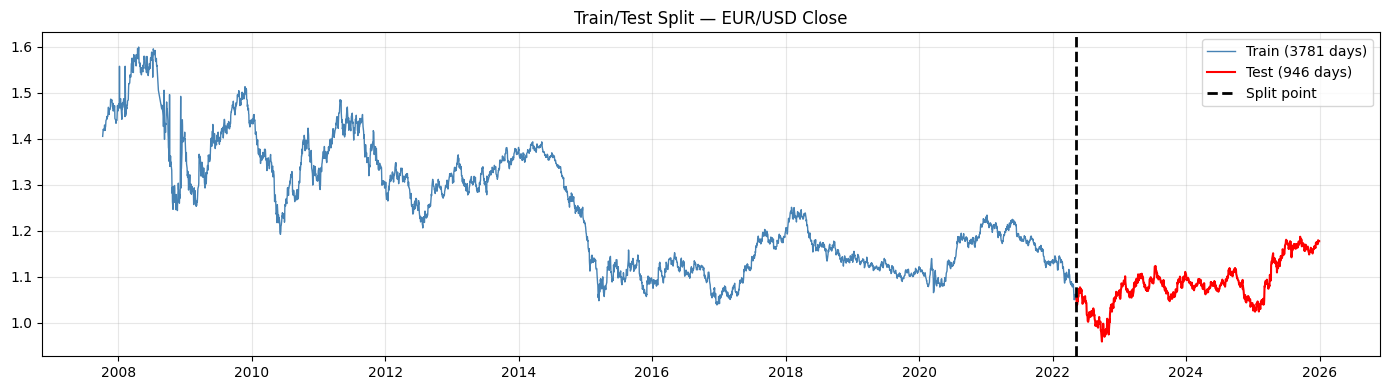

In [19]:
X = df[feature_cols]
y = df['target']

split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Train: {len(X_train)} rows  ({X_train.index[0].date()} to {X_train.index[-1].date()})")
print(f"Test:  {len(X_test)} rows  ({X_test.index[0].date()} to {X_test.index[-1].date()})")
print(f"\nTrain UP%: {y_train.mean()*100:.1f}%")
print(f"Test  UP%: {y_test.mean()*100:.1f}%")

# visualise the split
plt.figure(figsize=(14, 4))
plt.plot(df.index[:split], df['close'].iloc[:split], color='steelblue', lw=1, label=f'Train ({len(X_train)} days)')
plt.plot(df.index[split:], df['close'].iloc[split:], color='red', lw=1.5, label=f'Test ({len(X_test)} days)')
plt.axvline(df.index[split], color='black', lw=2, linestyle='--', label='Split point')
plt.title('Train/Test Split — EUR/USD Close')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()


## 5. Model Training

Three models are compared, chosen to cover the main practical families
for daily tabular financial prediction:

**Logistic Regression** — a regularised linear baseline. Fast,
interpretable, and gives well-calibrated probabilities. Needs scaled
features. Strong regularisation makes it hard to overfit when the signal
is weak.

**Random Forest** — many decision trees, each trained on a random subset
of rows and features, averaged together. Handles non-linear patterns and
needs no scaling.

**XGBoost** — gradient-boosted trees, where each tree corrects the errors
of the one before. Widely used for tabular financial data.

Deep learning models such as LSTMs and Transformers were not used. Even
with the extended dataset of 4,727 observations, this is well below the
sample sizes at which those architectures normally beat tree-based models
on tabular data (Patel et al. 2015, Fischer & Krauss 2018).

Models start with default settings for a baseline, then are tuned by grid
search in Section 5b.

In [20]:
# scale features for logistic regression only
# tree models (RF, XGBoost) don't need scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only
X_test_s  = scaler.transform(X_test)       # transform test without refitting

print("Scaling done (fit on training data only)")


Scaling done (fit on training data only)


In [21]:
# Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
lr.fit(X_train_s, y_train)
lr_pred  = lr.predict(X_test_s)
lr_proba = lr.predict_proba(X_test_s)[:, 1]

print(f"  Accuracy:         {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Balanced Acc:     {balanced_accuracy_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC:          {roc_auc_score(y_test, lr_proba):.4f}")


Training Logistic Regression...
  Accuracy:         0.4884
  Balanced Acc:     0.4891
  AUC-ROC:          0.5000


In [22]:
# Random Forest
print("Training Random Forest (100 trees)...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=10,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred  = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f"  Accuracy:         {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Balanced Acc:     {balanced_accuracy_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC:          {roc_auc_score(y_test, rf_proba):.4f}")
print(f"  OOB Score:        {rf.oob_score_:.4f}")


Training Random Forest (100 trees)...
  Accuracy:         0.5095
  Balanced Acc:     0.5087
  AUC-ROC:          0.5276
  OOB Score:        0.5046


In [23]:
# XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

print(f"  Accuracy:         {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Balanced Acc:     {balanced_accuracy_score(y_test, xgb_pred):.4f}")
print(f"  AUC-ROC:          {roc_auc_score(y_test, xgb_proba):.4f}")


Training XGBoost...
  Accuracy:         0.5063
  Balanced Acc:     0.5066
  AUC-ROC:          0.5118


In [24]:
# Bias-Variance check
# Compare training accuracy vs test accuracy
# Large gap = overfitting (high variance)
# Both low = underfitting (high bias)

print("Bias-Variance Diagnosis:")
print(f"{'Model':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 55)

from sklearn.metrics import roc_auc_score

for name, clf, xtr, xte in [
    ('Logistic Regression', lr,  X_train_s, X_test_s),
    ('Random Forest',       rf,  X_train,   X_test),
    ('XGBoost',             xgb, X_train,   X_test),
]:
    train_auc = roc_auc_score(y_train, clf.predict_proba(xtr)[:,1])
    test_auc  = roc_auc_score(y_test,  clf.predict_proba(xte)[:,1])
    gap = train_auc - test_auc
    verdict = 'HIGH VARIANCE (overfit)' if gap > 0.05 else \
              'HIGH BIAS (underfit)'    if test_auc < 0.52 else 'OK'
    print(f"{name:<25} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>8.4f}  {verdict}")

Bias-Variance Diagnosis:
Model                      Train AUC   Test AUC      Gap
-------------------------------------------------------
Logistic Regression           0.5619     0.5000   0.0619  HIGH VARIANCE (overfit)
Random Forest                 0.6571     0.5276   0.1295  HIGH VARIANCE (overfit)
XGBoost                       0.7298     0.5118   0.2181  HIGH VARIANCE (overfit)


### 4b. Hyperparameter Tuning

Grid search with time-series cross-validation, so every validation fold comes after its
training fold.

Watch the bias-variance diagnostic. Tuned XGBoost reaches a train AUC of 0.8827 against a
test AUC of 0.5265, a gap of 0.3562. It is not learning features, it is memorising rows.
That is itself evidence for the low-signal conclusion.

## 5b. Hyperparameter Tuning

Grid search with time-series cross-validation, so every validation fold
comes after its training fold.

The parameters selected here are locked and reused across Runs 3 to 6, so
that later comparisons change only one thing at a time.


In [25]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# TimeSeriesSplit = cross-validation that respects time order
# never use regular KFold on time series — it would leak future data
tscv = TimeSeriesSplit(n_splits=5)

# ── Logistic Regression ───────────────────────────────────────────
print("Tuning Logistic Regression...")
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid={
        'C':       [0.001, 0.01, 0.1, 1.0, 10],
        'penalty': ['l1', 'l2'],
        'solver':  ['saga'],   # saga supports both l1 and l2
    },
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1
)
lr_grid.fit(X_train_s, y_train)
print(f"Best LR params:  {lr_grid.best_params_}")
print(f"Best LR CV AUC:  {lr_grid.best_score_:.4f}")

# ── Random Forest ─────────────────────────────────────────────────
print("\nTuning Random Forest...")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators':     [100, 200],
        'max_depth':        [2, 3, 4, 5],
        'min_samples_leaf': [5, 10, 20],
        'max_features':     ['sqrt', 0.5],
    },
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print(f"Best RF params:  {rf_grid.best_params_}")
print(f"Best RF CV AUC:  {rf_grid.best_score_:.4f}")

# ── XGBoost ───────────────────────────────────────────────────────
print("\nTuning XGBoost...")
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, verbosity=0, n_jobs=-1),
    param_grid={
        'n_estimators':  [100, 200],
        'max_depth':     [2, 3, 4],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':     [0.7, 0.8],
        'reg_alpha':     [0, 0.5],
        'reg_lambda':    [1.0, 2.0],
    },
    cv=tscv,
    scoring='roc_auc',
    n_jobs=-1,
    return_train_score=True
)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB params: {xgb_grid.best_params_}")
print(f"Best XGB CV AUC: {xgb_grid.best_score_:.4f}")

Tuning Logistic Regression...
Best LR params:  {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Best LR CV AUC:  0.5196

Tuning Random Forest...
Best RF params:  {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
Best RF CV AUC:  0.5098

Tuning XGBoost...
Best XGB params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1.0, 'subsample': 0.7}
Best XGB CV AUC: 0.5121


In [26]:
# Cell 34 — Logistic Regression (tuned)
print("Training Logistic Regression (tuned)...")
lr_t = LogisticRegression(**lr_grid.best_params_, max_iter=2000, random_state=42)
lr_t.fit(X_train_s, y_train)
lr_t_pred  = lr_t.predict(X_test_s)
lr_t_proba = lr_t.predict_proba(X_test_s)[:, 1]

print(f"  Accuracy:     {accuracy_score(y_test, lr_t_pred):.4f}")
print(f"  Balanced Acc: {balanced_accuracy_score(y_test, lr_t_pred):.4f}")
print(f"  AUC-ROC:      {roc_auc_score(y_test, lr_t_proba):.4f}")

Training Logistic Regression (tuned)...
  Accuracy:     0.5021
  Balanced Acc: 0.5027
  AUC-ROC:      0.5071


In [27]:
# Cell 35 — Random Forest (tuned)
print("Training Random Forest (tuned)...")
rf_t = RandomForestClassifier(**rf_grid.best_params_, oob_score=True, random_state=42, n_jobs=-1)
rf_t.fit(X_train, y_train)
rf_t_pred  = rf_t.predict(X_test)
rf_t_proba = rf_t.predict_proba(X_test)[:, 1]

print(f"  Accuracy:     {accuracy_score(y_test, rf_t_pred):.4f}")
print(f"  Balanced Acc: {balanced_accuracy_score(y_test, rf_t_pred):.4f}")
print(f"  AUC-ROC:      {roc_auc_score(y_test, rf_t_proba):.4f}")
print(f"  OOB Score:    {rf_t.oob_score_:.4f}")

Training Random Forest (tuned)...
  Accuracy:     0.5148
  Balanced Acc: 0.5127
  AUC-ROC:      0.5309
  OOB Score:    0.4967


In [28]:
# Cell 36 — XGBoost (tuned)
print("Training XGBoost (tuned)...")
xgb_t = XGBClassifier(**xgb_grid.best_params_, random_state=42, verbosity=0, n_jobs=-1)
xgb_t.fit(X_train, y_train)
xgb_t_pred  = xgb_t.predict(X_test)
xgb_t_proba = xgb_t.predict_proba(X_test)[:, 1]

print(f"  Accuracy:     {accuracy_score(y_test, xgb_t_pred):.4f}")
print(f"  Balanced Acc: {balanced_accuracy_score(y_test, xgb_t_pred):.4f}")
print(f"  AUC-ROC:      {roc_auc_score(y_test, xgb_t_proba):.4f}")

Training XGBoost (tuned)...
  Accuracy:     0.5201
  Balanced Acc: 0.5203
  AUC-ROC:      0.5265


In [29]:
# Bias-Variance diagnostic
# Compares train AUC vs test AUC to identify under/overfitting per model
# - Large gap (>0.05): high variance (overfit) - model memorising training set
# - Both low (<0.52): high bias (underfit) - model not capturing signal
# - Both above ~0.55 with small gap: well calibrated

print("Bias-Variance Diagnosis (tuned models):")
print(f"{'Model':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}  Verdict")
print("-" * 70)

models = [
    ('Logistic Regression', lr_t,  X_train_s, X_test_s),
    ('Random Forest',       rf_t,  X_train,   X_test),
    ('XGBoost',             xgb_t, X_train,   X_test),
]

for name, clf, xtr, xte in models:
    train_auc = roc_auc_score(y_train, clf.predict_proba(xtr)[:, 1])
    test_auc  = roc_auc_score(y_test,  clf.predict_proba(xte)[:, 1])
    gap = train_auc - test_auc
    if gap > 0.05:
        verdict = 'HIGH VARIANCE (overfit)'
    elif test_auc < 0.52:
        verdict = 'HIGH BIAS (underfit)'
    else:
        verdict = 'OK'
    print(f"{name:<25} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>8.4f}  {verdict}")

Bias-Variance Diagnosis (tuned models):
Model                      Train AUC   Test AUC      Gap  Verdict
----------------------------------------------------------------------
Logistic Regression           0.5581     0.5071   0.0509  HIGH VARIANCE (overfit)
Random Forest                 0.5858     0.5309   0.0549  HIGH VARIANCE (overfit)
XGBoost                       0.8827     0.5265   0.3562  HIGH VARIANCE (overfit)


### 4c. Model Selection

Selection on training cross-validation only. The parameters chosen here are then **frozen**
for every experiment that follows, so later comparisons change one variable at a time.

## 6. Evaluation

Compare all three models against each other and against the random baseline.

Metrics reported:
- **Accuracy** — fraction of correct directional predictions
- **Balanced Accuracy** — treats UP and DOWN days equally; less misleading than plain accuracy when classes are nearly balanced (49/51 in this dataset, so balanced acc ≈ accuracy)
- **AUC-ROC** — quality of probability ranking, threshold-independent. Primary metric used throughout this project because it does not depend on a specific decision threshold

A more rigorous evaluation across multiple time windows is performed in Section 8 (walk-forward validation).


In [30]:
# Model comparison on single 80/20 test split (tuned models)
print("=" * 60)
print("MODEL COMPARISON (single train/test split, tuned)")
print("=" * 60)
print(f"{'Model':<25} {'Accuracy':>10} {'Bal. Acc':>10} {'AUC-ROC':>10}")
print("-" * 60)

# store both predictions AND classifier reference for downstream use (e.g. SHAP)
results = {
    'Logistic Regression': {'pred': lr_t_pred,  'proba': lr_t_proba,  'clf': lr_t},
    'Random Forest':       {'pred': rf_t_pred,  'proba': rf_t_proba,  'clf': rf_t},
    'XGBoost':             {'pred': xgb_t_pred, 'proba': xgb_t_proba, 'clf': xgb_t},
}

for name, res in results.items():
    acc  = accuracy_score(y_test, res['pred'])
    bacc = balanced_accuracy_score(y_test, res['pred'])
    auc  = roc_auc_score(y_test, res['proba'])
    results[name].update({'acc': acc, 'bacc': bacc, 'auc': auc})
    print(f"{name:<25} {acc:>10.4f} {bacc:>10.4f} {auc:>10.4f}")

MODEL COMPARISON (single train/test split, tuned)
Model                       Accuracy   Bal. Acc    AUC-ROC
------------------------------------------------------------
Logistic Regression           0.5021     0.5027     0.5071
Random Forest                 0.5148     0.5127     0.5309
XGBoost                       0.5201     0.5203     0.5265


In [31]:
# Select the primary model using training cross-validation only
# Do not select the model using final test AUC

validation_scores = {
    'Logistic Regression': lr_grid.best_score_,
    'Random Forest': rf_grid.best_score_,
    'XGBoost': xgb_grid.best_score_
}

PRIMARY_MODEL = max(
    validation_scores,
    key=validation_scores.get
)

best = PRIMARY_MODEL

print("Training cross-validation AUC:")

for model_name, score in validation_scores.items():
    print(f"{model_name:<22}: {score:.4f}")

print(
    f"\nPrimary model selected using training CV: "
    f"{PRIMARY_MODEL}"
)

print(
    f"Primary model final test AUC: "
    f"{results[best]['auc']:.4f}\n"
)

print(
    classification_report(
        y_test,
        results[best]['pred'],
        target_names=['DOWN', 'UP']
    )
)

Training cross-validation AUC:
Logistic Regression   : 0.5196
Random Forest         : 0.5098
XGBoost               : 0.5121

Primary model selected using training CV: Logistic Regression
Primary model final test AUC: 0.5071

              precision    recall  f1-score   support

        DOWN       0.51      0.47      0.49       481
          UP       0.49      0.54      0.51       465

    accuracy                           0.50       946
   macro avg       0.50      0.50      0.50       946
weighted avg       0.50      0.50      0.50       946



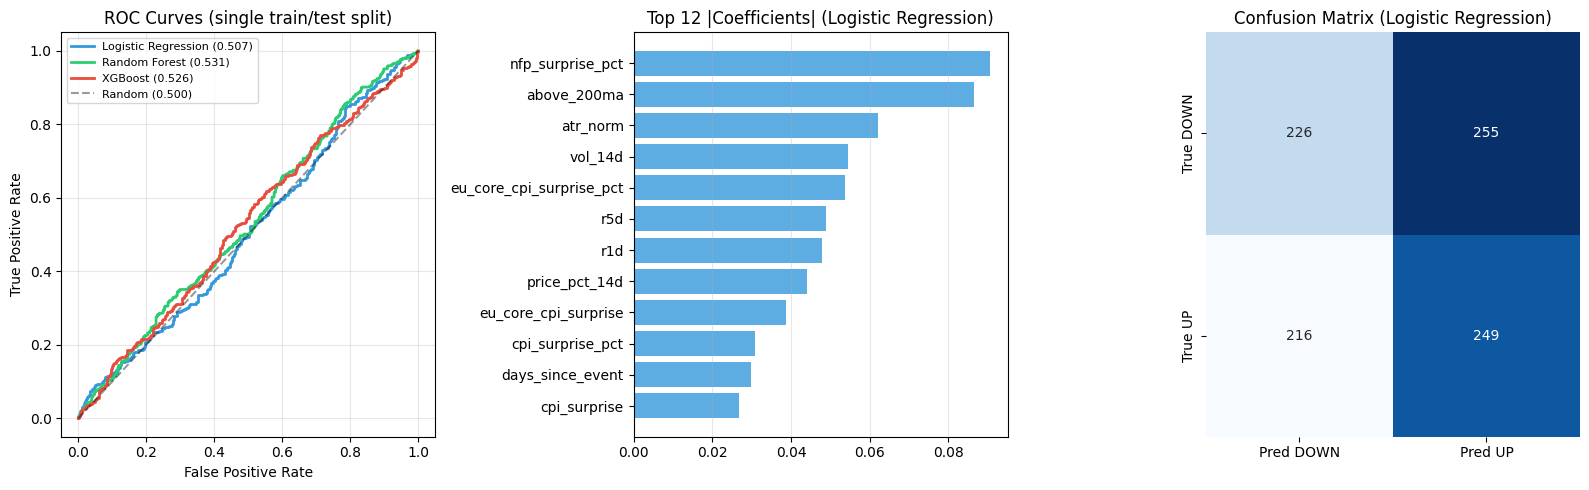

In [104]:
# diagnostic plots: ROC curves, feature importance, confusion matrix
from sklearn.metrics import roc_curve, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colours = {'Logistic Regression': '#3498db',
           'Random Forest':       '#2ecc71',
           'XGBoost':             '#e74c3c'}

# ROC curves for all three models
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, lw=2, color=colours[name],
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (single train/test split)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Feature importance for best model (only if the model supports it)
ax = axes[1]
best_clf = results[best]['clf']
if hasattr(best_clf, 'feature_importances_'):
    imp = pd.Series(best_clf.feature_importances_,
                    index=feature_cols).sort_values(ascending=True).tail(12)
    ax.barh(imp.index, imp.values, color='#2ecc71', alpha=0.8)
    ax.set_title(f'Top 12 Feature Importances ({best})')
elif hasattr(best_clf, 'coef_'):
    coefs = pd.Series(best_clf.coef_[0], index=feature_cols)
    imp = coefs.abs().sort_values(ascending=True).tail(12)
    ax.barh(imp.index, imp.values, color='#3498db', alpha=0.8)
    ax.set_title(f'Top 12 |Coefficients| ({best})')
else:
    ax.text(0.5, 0.5, 'No feature importance available',
            ha='center', va='center')
    ax.set_title(f'Feature Importance ({best})')
ax.grid(True, alpha=0.3, axis='x')

# Confusion matrix for best model
ax = axes[2]
cm = confusion_matrix(y_test, results[best]['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred DOWN', 'Pred UP'],
            yticklabels=['True DOWN', 'True UP'],
            cbar=False)
ax.set_title(f'Confusion Matrix ({best})')

plt.tight_layout()
plt.savefig('evaluation_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()

In [33]:
# Freeze the selected hyperparameters.
# Every experiment from Section 5 onward reuses these unchanged.

RUN2_LR_PARAMS = {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}

RUN2_RF_PARAMS = {
    'max_depth': 2,
    'max_features': 'sqrt',
    'min_samples_leaf': 5,
    'n_estimators': 100
}

RUN2_XGB_PARAMS = {
    'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100,
    'reg_alpha': 0, 'reg_lambda': 1.0, 'subsample': 0.7
}

print("Frozen parameters")
print("  Logistic Regression:", RUN2_LR_PARAMS)
print("  Random Forest:      ", RUN2_RF_PARAMS)
print("  XGBoost:            ", RUN2_XGB_PARAMS)

Frozen parameters
  Logistic Regression: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
  Random Forest:       {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
  XGBoost:             {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1.0, 'subsample': 0.7}


## 5. Evaluation Design

A single split measures one market period. Walk-forward evaluation retrains repeatedly and
tests on many, which is the honest test of whether a result generalises.

Three design choices are settled experimentally before the final evaluation:

- **5a. Which feature set?** Technical-only, event-only or hybrid.
- **5b. Do refined event features help?** Signed-log, directional and rate-policy encodings.
- **5c. Which training window?** Expanding, 5-year rolling or 10-year rolling.

Each holds everything else constant.

### 5a. Feature-Set Comparison

Technical-only vs event-only vs hybrid, all three models, 65 common walk-forward folds.

Note the divergence: event-only Random Forest looks strongest on the single split
(AUC 0.5523) but does not hold up across folds. This is exactly why the single split is
not used for selection.

In [34]:
# Run 3 feature groups

event_features = [
    column
    for column in feature_cols
    if column.startswith(
        (
            'cpi_',
            'nfp_',
            'fomc_',
            'ecb_rate_',
            'eu_cpi_',
            'eu_core_cpi_'
        )
    )
]

# These features depend directly on economic-event timing
event_context_features = [
    'event_day',
    'days_since_event',
    'days_until_event',
    'post_event_vol'
]

event_features = list(
    dict.fromkeys(
        event_features + event_context_features
    )
)

technical_features = [
    column
    for column in feature_cols
    if column not in event_features
]

hybrid_features = feature_cols.copy()

feature_sets = {
    'Technical Only': technical_features,
    'Event Only': event_features,
    'Hybrid': hybrid_features
}

print("Run 3 feature sets:")

for set_name, columns in feature_sets.items():
    print(f"{set_name:<20}: {len(columns)} features")

# Validation checks
assert set(technical_features).isdisjoint(
    set(event_features)
)

assert set(technical_features + event_features) == set(
    hybrid_features
)

print("\nFeature-group checks passed.")

Run 3 feature sets:
Technical Only      : 20 features
Event Only          : 28 features
Hybrid              : 48 features

Feature-group checks passed.


In [35]:
for set_name, columns in feature_sets.items():
    print(f"\n{'=' * 70}")
    print(f"{set_name} — {len(columns)} features")
    print('=' * 70)

    for column in columns:
        print(column)


Technical Only — 20 features
r1d
r5d
r7d
r10d
r14d
mom5
mom7
mom10
vol_5d
vol_14d
price_pct_14d
above_200ma
dist_200ma
ma50_slope
cos_dow
sin_dow
rsi
macd_hist
bb_pct
atr_norm

Event Only — 28 features
cpi_surprise
cpi_available
cpi_surprise_pct
cpi_day
nfp_surprise
nfp_available
nfp_surprise_pct
nfp_day
fomc_surprise
fomc_available
fomc_surprise_pct
fomc_day
ecb_rate_surprise
ecb_rate_available
ecb_rate_surprise_pct
ecb_rate_day
eu_cpi_surprise
eu_cpi_available
eu_cpi_surprise_pct
eu_cpi_day
eu_core_cpi_surprise
eu_core_cpi_available
eu_core_cpi_surprise_pct
eu_core_cpi_day
event_day
days_since_event
days_until_event
post_event_vol

Hybrid — 48 features
cpi_surprise
cpi_available
cpi_surprise_pct
cpi_day
nfp_surprise
nfp_available
nfp_surprise_pct
nfp_day
fomc_surprise
fomc_available
fomc_surprise_pct
fomc_day
ecb_rate_surprise
ecb_rate_available
ecb_rate_surprise_pct
ecb_rate_day
eu_cpi_surprise
eu_cpi_available
eu_cpi_surprise_pct
eu_cpi_day
eu_core_cpi_surprise
eu_core_cpi_availab

In [36]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score
)

run3_single_results = []


def evaluate_single_split(
    set_name,
    columns
):
    X_set = df[columns]
    y_set = df['target']

    X_train_set = X_set.iloc[:split]
    X_test_set = X_set.iloc[split:]

    y_train_set = y_set.iloc[:split]
    y_test_set = y_set.iloc[split:]

    # Logistic Regression requires scaling
    scaler_set = StandardScaler()

    X_train_scaled = scaler_set.fit_transform(
        X_train_set
    )

    X_test_scaled = scaler_set.transform(
        X_test_set
    )

    models = {
        'Logistic Regression': (
            LogisticRegression(
                **RUN2_LR_PARAMS,
                max_iter=2000,
                random_state=42
            ),
            X_train_scaled,
            X_test_scaled
        ),

        'Random Forest': (
            RandomForestClassifier(
                **RUN2_RF_PARAMS,
                random_state=42,
                n_jobs=-1
            ),
            X_train_set,
            X_test_set
        ),

        'XGBoost': (
            XGBClassifier(
                **RUN2_XGB_PARAMS,
                random_state=42,
                verbosity=0,
                n_jobs=-1
            ),
            X_train_set,
            X_test_set
        )
    }

    for model_name, (
        model,
        training_data,
        testing_data
    ) in models.items():

        model.fit(
            training_data,
            y_train_set
        )

        train_probability = model.predict_proba(
            training_data
        )[:, 1]

        test_probability = model.predict_proba(
            testing_data
        )[:, 1]

        test_prediction = model.predict(
            testing_data
        )

        train_auc = roc_auc_score(
            y_train_set,
            train_probability
        )

        test_auc = roc_auc_score(
            y_test_set,
            test_probability
        )

        run3_single_results.append({
            'Feature Set': set_name,
            'Model': model_name,
            'Features': len(columns),
            'Train AUC': train_auc,
            'Test AUC': test_auc,
            'AUC Gap': train_auc - test_auc,
            'Accuracy': accuracy_score(
                y_test_set,
                test_prediction
            ),
            'Balanced Accuracy':
                balanced_accuracy_score(
                    y_test_set,
                    test_prediction
                )
        })


for set_name, columns in feature_sets.items():
    print(f"Running: {set_name}")
    evaluate_single_split(
        set_name,
        columns
    )

run3_single_df = pd.DataFrame(
    run3_single_results
)

display(
    run3_single_df.round(4)
)

Running: Technical Only
Running: Event Only
Running: Hybrid


,Feature Set,Model,Features,Train AUC,Test AUC,AUC Gap,Accuracy,Balanced Accuracy
0,Technical Only,Logistic Regression,20,0.5410,0.4825,0.0584,0.4884,0.4888
1,Technical Only,Random Forest,20,0.5821,0.5021,0.0800,0.4947,0.4935
2,Technical Only,XGBoost,20,0.8823,0.4960,0.3863,0.4863,0.4866
3,Event Only,Logistic Regression,28,0.5313,0.5359,-0.0045,0.5159,0.5161
4,Event Only,Random Forest,28,0.5684,0.5523,0.0161,0.5159,0.5084
5,Event Only,XGBoost,28,0.6505,0.5241,0.1264,0.5159,0.5178
6,Hybrid,Logistic Regression,48,0.5581,0.5071,0.0509,0.5021,0.5027
7,Hybrid,Random Forest,48,0.5858,0.5309,0.0549,0.5148,0.5127
8,Hybrid,XGBoost,48,0.8827,0.5265,0.3562,0.5201,0.5203


In [37]:
run3_single_pivot = run3_single_df.pivot(
    index='Feature Set',
    columns='Model',
    values='Test AUC'
)

run3_single_pivot = run3_single_pivot.reindex(
    [
        'Technical Only',
        'Event Only',
        'Hybrid'
    ]
)

print("Single-split Test AUC")
display(
    run3_single_pivot.round(4)
)

Single-split Test AUC


Model,Logistic Regression,Random Forest,XGBoost
Feature Set,,,
Technical Only,0.4825,0.5021,0.4960
Event Only,0.5359,0.5523,0.5241
Hybrid,0.5071,0.5309,0.5265


In [38]:
run3_wf_results = []

INITIAL_TRAIN_SIZE_RUN3 = 800
TEST_WINDOW_RUN3 = 60
STEP_RUN3 = 60


def run_walk_forward_feature_set(
    set_name,
    columns
):
    train_end = INITIAL_TRAIN_SIZE_RUN3
    fold_number = 1

    while (
        train_end + TEST_WINDOW_RUN3
        <= len(df)
    ):
        X_train_fold = df[columns].iloc[
            :train_end
        ]

        X_test_fold = df[columns].iloc[
            train_end:
            train_end + TEST_WINDOW_RUN3
        ]

        y_train_fold = df['target'].iloc[
            :train_end
        ]

        y_test_fold = df['target'].iloc[
            train_end:
            train_end + TEST_WINDOW_RUN3
        ]

        # Scale separately inside each fold
        scaler_fold = StandardScaler()

        X_train_fold_scaled = (
            scaler_fold.fit_transform(
                X_train_fold
            )
        )

        X_test_fold_scaled = (
            scaler_fold.transform(
                X_test_fold
            )
        )

        fold_models = {
            'Logistic Regression': (
                LogisticRegression(
                    **RUN2_LR_PARAMS,
                    max_iter=2000,
                    random_state=42
                ),
                X_train_fold_scaled,
                X_test_fold_scaled
            ),

            'Random Forest': (
                RandomForestClassifier(
                    **RUN2_RF_PARAMS,
                    random_state=42,
                    n_jobs=-1
                ),
                X_train_fold,
                X_test_fold
            ),

            'XGBoost': (
                XGBClassifier(
                    **RUN2_XGB_PARAMS,
                    random_state=42,
                    verbosity=0,
                    n_jobs=-1
                ),
                X_train_fold,
                X_test_fold
            )
        }

        for model_name, (
            model,
            training_data,
            testing_data
        ) in fold_models.items():

            model.fit(
                training_data,
                y_train_fold
            )

            probability = model.predict_proba(
                testing_data
            )[:, 1]

            fold_auc = roc_auc_score(
                y_test_fold,
                probability
            )

            run3_wf_results.append({
                'Feature Set': set_name,
                'Model': model_name,
                'Fold': fold_number,
                'Test Start':
                    X_test_fold.index[0],
                'Test End':
                    X_test_fold.index[-1],
                'AUC': fold_auc
            })

        train_end += STEP_RUN3
        fold_number += 1

    print(
        f"{set_name}: "
        f"{fold_number - 1} folds completed"
    )


for set_name, columns in feature_sets.items():
    run_walk_forward_feature_set(
        set_name,
        columns
    )

run3_wf_df = pd.DataFrame(
    run3_wf_results
)

print("\nRun 3 walk-forward complete.")
print(
    f"Total stored results: "
    f"{len(run3_wf_df)}"
)

Technical Only: 65 folds completed
Event Only: 65 folds completed
Hybrid: 65 folds completed

Run 3 walk-forward complete.
Total stored results: 585


In [39]:
run3_wf_summary = (
    run3_wf_df
    .groupby(
        ['Feature Set', 'Model']
    )
    .agg(
        Mean_AUC=('AUC', 'mean'),
        Std_AUC=('AUC', 'std'),
        Min_AUC=('AUC', 'min'),
        Max_AUC=('AUC', 'max'),
        Folds=('AUC', 'count'),
        Above_050=(
            'AUC',
            lambda values:
                (values > 0.50).sum()
        ),
        Above_055=(
            'AUC',
            lambda values:
                (values > 0.55).sum()
        )
    )
    .reset_index()
)

display(
    run3_wf_summary.round(4)
)

,Feature Set,Model,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Folds,Above_050,Above_055
0,Event Only,Logistic Regression,0.5105,0.0722,0.3677,0.6680,65,37,19
1,Event Only,Random Forest,0.5064,0.0623,0.3404,0.6567,65,35,21
2,Event Only,XGBoost,0.5055,0.0696,0.3137,0.6674,65,38,13
3,Hybrid,Logistic Regression,0.5215,0.0658,0.3846,0.6465,65,39,26
4,Hybrid,Random Forest,0.5298,0.0648,0.4004,0.6811,65,41,25
5,Hybrid,XGBoost,0.5130,0.0765,0.3315,0.7341,65,34,20
6,Technical Only,Logistic Regression,0.5115,0.0716,0.3819,0.7755,65,33,17
7,Technical Only,Random Forest,0.5123,0.0574,0.3582,0.6723,65,40,16
8,Technical Only,XGBoost,0.4956,0.0693,0.3014,0.6652,65,29,12


In [40]:
run3_wf_pivot = run3_wf_summary.pivot(
    index='Feature Set',
    columns='Model',
    values='Mean_AUC'
)

run3_wf_pivot = run3_wf_pivot.reindex(
    [
        'Technical Only',
        'Event Only',
        'Hybrid'
    ]
)

print("Walk-forward Mean AUC")
display(
    run3_wf_pivot.round(4)
)

Walk-forward Mean AUC


Model,Logistic Regression,Random Forest,XGBoost
Feature Set,,,
Technical Only,0.5115,0.5123,0.4956
Event Only,0.5105,0.5064,0.5055
Hybrid,0.5215,0.5298,0.5130


In [41]:
best_run3_row = run3_wf_summary.loc[
    run3_wf_summary['Mean_AUC'].idxmax()
]

print("Best Run 3 combination:")
print(
    f"Feature set: "
    f"{best_run3_row['Feature Set']}"
)

print(
    f"Model: "
    f"{best_run3_row['Model']}"
)

print(
    f"Mean walk-forward AUC: "
    f"{best_run3_row['Mean_AUC']:.4f}"
)

print(
    f"Folds above 0.50: "
    f"{int(best_run3_row['Above_050'])}"
    f"/{int(best_run3_row['Folds'])}"
)

Best Run 3 combination:
Feature set: Hybrid
Model: Random Forest
Mean walk-forward AUC: 0.5298
Folds above 0.50: 41/65


In [42]:
# FINAL REVIEW EDIT 2 — Run 3 paired feature-set tests
from scipy import stats

rf_folds = (
    run3_wf_df[run3_wf_df['Model'] == 'Random Forest']
    .pivot(index='Fold', columns='Feature Set', values='AUC')
    .dropna()
)

print("Run 3 paired feature-set comparisons (Random Forest)")
print("-" * 55)
print(f"Folds compared: {len(rf_folds)}\n")

for other in ['Technical Only', 'Event Only']:
    diff = rf_folds['Hybrid'] - rf_folds[other]
    t, p = stats.ttest_rel(rf_folds['Hybrid'], rf_folds[other])
    print(f"Hybrid minus {other}:")
    print(f"  mean difference = {diff.mean():+.4f}")
    print(f"  t = {t:.3f}, two-sided p = {p:.4f}")
    print(f"  Hybrid higher in {int((diff > 0).sum())}/{len(diff)} folds\n")

Run 3 paired feature-set comparisons (Random Forest)
-------------------------------------------------------
Folds compared: 65

Hybrid minus Technical Only:
  mean difference = +0.0176
  t = 2.979, two-sided p = 0.0041
  Hybrid higher in 44/65 folds

Hybrid minus Event Only:
  mean difference = +0.0235
  t = 2.429, two-sided p = 0.0180
  Hybrid higher in 40/65 folds



In [43]:
run3_single_df.to_csv(
    'run3_single_split_results.csv',
    index=False
)

run3_wf_df.to_csv(
    'run3_walkforward_fold_results.csv',
    index=False
)

run3_wf_summary.to_csv(
    'run3_walkforward_summary.csv',
    index=False
)

print("Run 3 result files saved.")

Run 3 result files saved.


### 5b. Event-Feature Refinement

Signed-log transforms, directional encoding and explicit rate-policy features
(hike/cut/hold plus actual rate change) tested against the baseline event features.

A controlled **negative result**: no transformation improved on baseline (best difference
+0.0000). The baseline hybrid feature set is retained. This is the one experiment without
a significance test.

In [44]:
# Confirm that policy-rate data contains actual and previous values

rate_sources = {
    'FOMC': fomc_df,
    'ECB Rate': ecb_rate_df
}

required_rate_columns = {
    'date',
    'actual',
    'previous'
}

for source_name, source_df in rate_sources.items():

    missing_columns = (
        required_rate_columns
        - set(source_df.columns)
    )

    if missing_columns:
        raise ValueError(
            f"{source_name} is missing: "
            f"{missing_columns}"
        )

    print(
        f"{source_name}: columns confirmed — "
        f"{sorted(required_rate_columns)}"
    )

FOMC: columns confirmed — ['actual', 'date', 'previous']
ECB Rate: columns confirmed — ['actual', 'date', 'previous']


In [45]:
# Work on a separate copy so Run 1–3 remain unchanged

df_run4 = df.copy()


event_configuration = {
    'cpi': {
        'surprise': 'cpi_surprise',
        'percentile': 'cpi_surprise_pct',
        'eurusd_sign': -1
    },
    'nfp': {
        'surprise': 'nfp_surprise',
        'percentile': 'nfp_surprise_pct',
        'eurusd_sign': -1
    },
    'fomc': {
        'surprise': 'fomc_surprise',
        'percentile': 'fomc_surprise_pct',
        'eurusd_sign': -1
    },
    'ecb_rate': {
        'surprise': 'ecb_rate_surprise',
        'percentile': 'ecb_rate_surprise_pct',
        'eurusd_sign': 1
    },
    'eu_cpi': {
        'surprise': 'eu_cpi_surprise',
        'percentile': 'eu_cpi_surprise_pct',
        'eurusd_sign': 1
    },
    'eu_core_cpi': {
        'surprise': 'eu_core_cpi_surprise',
        'percentile': 'eu_core_cpi_surprise_pct',
        'eurusd_sign': 1
    }
}


raw_surprise_columns = []
percentile_columns = []

signed_log_columns = []
directional_log_columns = []
directional_percentile_columns = []


for event_prefix, settings in event_configuration.items():

    surprise_column = settings['surprise']
    percentile_column = settings['percentile']
    eurusd_sign = settings['eurusd_sign']

    log_column = (
        f'{event_prefix}_log_surprise'
    )

    directional_log_column = (
        f'{event_prefix}_eurusd_log_surprise'
    )

    directional_percentile_column = (
        f'{event_prefix}_eurusd_percentile'
    )

    surprise_values = (
        df_run4[surprise_column]
        .astype(float)
    )

    # Reduce extreme values while preserving direction
    df_run4[log_column] = (
        np.sign(surprise_values)
        * np.log1p(np.abs(surprise_values))
    )

    # Positive value always represents upward EUR/USD pressure
    df_run4[directional_log_column] = (
        eurusd_sign
        * df_run4[log_column]
    )

    # Convert percentile from [0, 1] to [-1, 1]
    # Neutral 0.5 becomes zero
    df_run4[directional_percentile_column] = (
        eurusd_sign
        * (
            2
            * df_run4[percentile_column]
            - 1
        )
    )

    raw_surprise_columns.append(
        surprise_column
    )

    percentile_columns.append(
        percentile_column
    )

    signed_log_columns.append(
        log_column
    )

    directional_log_columns.append(
        directional_log_column
    )

    directional_percentile_columns.append(
        directional_percentile_column
    )


print("Signed-log features created:")
print(signed_log_columns)

print("\nDirectional features created:")
print(directional_log_columns)
print(directional_percentile_columns)

Signed-log features created:
['cpi_log_surprise', 'nfp_log_surprise', 'fomc_log_surprise', 'ecb_rate_log_surprise', 'eu_cpi_log_surprise', 'eu_core_cpi_log_surprise']

Directional features created:
['cpi_eurusd_log_surprise', 'nfp_eurusd_log_surprise', 'fomc_eurusd_log_surprise', 'ecb_rate_eurusd_log_surprise', 'eu_cpi_eurusd_log_surprise', 'eu_core_cpi_eurusd_log_surprise']
['cpi_eurusd_percentile', 'nfp_eurusd_percentile', 'fomc_eurusd_percentile', 'ecb_rate_eurusd_percentile', 'eu_cpi_eurusd_percentile', 'eu_core_cpi_eurusd_percentile']


In [46]:
def add_rate_policy_features(
    daily_df,
    event_df,
    prefix,
    eurusd_sign
):
    """
    Add actual-minus-previous rate movement features.

    eurusd_sign:
        -1 for FOMC/USD
        +1 for ECB/EUR
    """

    required_columns = [
        'date',
        'actual',
        'previous'
    ]

    rate_df = event_df[
        required_columns
    ].copy()

    rate_df['date'] = (
        pd.to_datetime(rate_df['date'])
        .dt.normalize()
    )

    change_available_column = (
        f'{prefix}_rate_change_available'
    )

    directional_change_column = (
        f'{prefix}_eurusd_rate_change'
    )

    hike_column = f'{prefix}_hike'
    cut_column = f'{prefix}_cut'
    hold_column = f'{prefix}_hold'

    rate_df[change_available_column] = (
        rate_df['actual'].notna()
        & rate_df['previous'].notna()
    ).astype(int)

    raw_change = (
        rate_df['actual']
        - rate_df['previous']
    )

    valid_change = (
        rate_df[change_available_column]
        .eq(1)
    )

    # Positive means upward EUR/USD pressure
    rate_df[directional_change_column] = (
        eurusd_sign
        * raw_change.where(
            valid_change,
            0
        )
    )

    tolerance = 1e-12

    rate_df[hike_column] = (
        valid_change
        & raw_change.gt(tolerance)
    ).astype(int)

    rate_df[cut_column] = (
        valid_change
        & raw_change.lt(-tolerance)
    ).astype(int)

    rate_df[hold_column] = (
        valid_change
        & raw_change.abs().le(tolerance)
    ).astype(int)

    feature_columns = [
        change_available_column,
        directional_change_column,
        hike_column,
        cut_column,
        hold_column
    ]

    rate_df = (
        rate_df[
            ['date'] + feature_columns
        ]
        .sort_values('date')
        .drop_duplicates(
            subset=['date'],
            keep='last'
        )
        .set_index('date')
    )

    output_df = daily_df.join(
        rate_df,
        how='left'
    )

    output_df[feature_columns] = (
        output_df[feature_columns]
        .fillna(0)
    )

    flag_columns = [
        change_available_column,
        hike_column,
        cut_column,
        hold_column
    ]

    output_df[flag_columns] = (
        output_df[flag_columns]
        .astype(int)
    )

    return output_df, feature_columns


# FOMC: higher US rates normally support USD,
# therefore creating downward EUR/USD pressure
df_run4, fomc_rate_features = (
    add_rate_policy_features(
        df_run4,
        fomc_df,
        prefix='fomc',
        eurusd_sign=-1
    )
)


# ECB: higher euro rates normally support EUR,
# therefore creating upward EUR/USD pressure
df_run4, ecb_rate_features = (
    add_rate_policy_features(
        df_run4,
        ecb_rate_df,
        prefix='ecb',
        eurusd_sign=1
    )
)


rate_policy_columns = (
    fomc_rate_features
    + ecb_rate_features
)

print("Rate-policy features created:")

for column in rate_policy_columns:
    print(column)

Rate-policy features created:
fomc_rate_change_available
fomc_eurusd_rate_change
fomc_hike
fomc_cut
fomc_hold
ecb_rate_change_available
ecb_eurusd_rate_change
ecb_hike
ecb_cut
ecb_hold


In [47]:
availability_columns = [
    'cpi_available',
    'nfp_available',
    'fomc_available',
    'ecb_rate_available',
    'eu_cpi_available',
    'eu_core_cpi_available'
]

rate_availability_columns = [
    'fomc_rate_change_available',
    'ecb_rate_change_available'
]


# 1. Original Run 3 hybrid baseline
baseline_features = (
    feature_cols.copy()
)


# 2. Baseline without source-availability indicators
no_availability_features = [
    column
    for column in baseline_features
    if column not in availability_columns
]


# 3. Replace raw surprises with signed-log surprises
signed_log_features = [
    column
    for column in baseline_features
    if column not in raw_surprise_columns
]

signed_log_features += signed_log_columns


# 4. Replace raw surprises and original percentiles
# with directionally aligned versions
directional_features = [
    column
    for column in baseline_features
    if column not in (
        raw_surprise_columns
        + percentile_columns
    )
]

directional_features += (
    directional_log_columns
    + directional_percentile_columns
)


# 5. Add interest-rate policy movement features
rate_refined_features = (
    directional_features
    + rate_policy_columns
)


# 6. Full refined set without any availability indicators
refined_no_availability_features = [
    column
    for column in rate_refined_features
    if column not in (
        availability_columns
        + rate_availability_columns
    )
]


run4_feature_sets = {
    'Baseline Hybrid':
        baseline_features,

    'No Availability':
        no_availability_features,

    'Signed Log':
        signed_log_features,

    'Directional':
        directional_features,

    'Directional + Rate Policy':
        rate_refined_features,

    'Refined No Availability':
        refined_no_availability_features
}


print("Run 4 feature variants:\n")

for set_name, columns in run4_feature_sets.items():

    duplicate_count = (
        len(columns)
        - len(set(columns))
    )

    missing_columns = [
        column
        for column in columns
        if column not in df_run4.columns
    ]

    if duplicate_count:
        raise ValueError(
            f"{set_name} contains duplicate columns"
        )

    if missing_columns:
        raise ValueError(
            f"{set_name} is missing columns: "
            f"{missing_columns}"
        )

    print(
        f"{set_name:<30}: "
        f"{len(columns)} features"
    )

Run 4 feature variants:

Baseline Hybrid               : 48 features
No Availability               : 42 features
Signed Log                    : 48 features
Directional                   : 48 features
Directional + Rate Policy     : 58 features
Refined No Availability       : 50 features


In [48]:
print("Locked model parameters:")

print(
    "Logistic Regression:",
    RUN2_LR_PARAMS
)

print(
    "Random Forest:",
    RUN2_RF_PARAMS
)

print(
    "XGBoost:",
    RUN2_XGB_PARAMS
)

Locked model parameters:
Logistic Regression: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
Random Forest: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
XGBoost: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0, 'reg_lambda': 1.0, 'subsample': 0.7}


In [49]:
run4_single_results = []


def evaluate_run4_single_split(
    set_name,
    columns
):
    X_set = df_run4[columns]
    y_set = df_run4['target']

    X_train_set = X_set.iloc[:split]
    X_test_set = X_set.iloc[split:]

    y_train_set = y_set.iloc[:split]
    y_test_set = y_set.iloc[split:]

    scaler_set = StandardScaler()

    X_train_scaled = (
        scaler_set.fit_transform(
            X_train_set
        )
    )

    X_test_scaled = (
        scaler_set.transform(
            X_test_set
        )
    )

    models = {
        'Logistic Regression': (
            LogisticRegression(
                **RUN2_LR_PARAMS,
                max_iter=2000,
                random_state=42
            ),
            X_train_scaled,
            X_test_scaled
        ),

        'Random Forest': (
            RandomForestClassifier(
                **RUN2_RF_PARAMS,
                random_state=42,
                n_jobs=-1
            ),
            X_train_set,
            X_test_set
        ),

        'XGBoost': (
            XGBClassifier(
                **RUN2_XGB_PARAMS,
                random_state=42,
                verbosity=0,
                n_jobs=-1
            ),
            X_train_set,
            X_test_set
        )
    }

    for model_name, (
        model,
        training_data,
        testing_data
    ) in models.items():

        model.fit(
            training_data,
            y_train_set
        )

        train_probability = (
            model.predict_proba(
                training_data
            )[:, 1]
        )

        test_probability = (
            model.predict_proba(
                testing_data
            )[:, 1]
        )

        test_prediction = model.predict(
            testing_data
        )

        train_auc = roc_auc_score(
            y_train_set,
            train_probability
        )

        test_auc = roc_auc_score(
            y_test_set,
            test_probability
        )

        run4_single_results.append({
            'Feature Set': set_name,
            'Model': model_name,
            'Features': len(columns),
            'Train AUC': train_auc,
            'Test AUC': test_auc,
            'AUC Gap':
                train_auc - test_auc,
            'Accuracy':
                accuracy_score(
                    y_test_set,
                    test_prediction
                ),
            'Balanced Accuracy':
                balanced_accuracy_score(
                    y_test_set,
                    test_prediction
                )
        })


for set_name, columns in run4_feature_sets.items():

    print(f"Running: {set_name}")

    evaluate_run4_single_split(
        set_name,
        columns
    )


run4_single_df = pd.DataFrame(
    run4_single_results
)

display(
    run4_single_df.round(4)
)

Running: Baseline Hybrid
Running: No Availability
Running: Signed Log
Running: Directional
Running: Directional + Rate Policy
Running: Refined No Availability


,Feature Set,Model,Features,Train AUC,Test AUC,AUC Gap,Accuracy,Balanced Accuracy
0,Baseline Hybrid,Logistic Regression,48,0.5581,0.5071,0.0509,0.5021,0.5027
1,Baseline Hybrid,Random Forest,48,0.5858,0.5309,0.0549,0.5148,0.5127
2,Baseline Hybrid,XGBoost,48,0.8827,0.5265,0.3562,0.5201,0.5203
3,No Availability,Logistic Regression,42,0.5580,0.5070,0.0509,0.5000,0.5006
4,No Availability,Random Forest,42,0.5872,0.5184,0.0687,0.5042,0.5023
5,No Availability,XGBoost,42,0.8827,0.5265,0.3562,0.5201,0.5203
6,Signed Log,Logistic Regression,48,0.5579,0.5072,0.0507,0.5011,0.5016
7,Signed Log,Random Forest,48,0.5829,0.5300,0.0530,0.5211,0.5198
8,Signed Log,XGBoost,48,0.8827,0.5267,0.3560,0.5201,0.5203
9,Directional,Logistic Regression,48,0.5579,0.5072,0.0507,0.5011,0.5016


In [50]:
run4_single_pivot = (
    run4_single_df
    .pivot(
        index='Feature Set',
        columns='Model',
        values='Test AUC'
    )
    .reindex(
        list(run4_feature_sets.keys())
    )
)

print("Run 4 Single-Split Test AUC")

display(
    run4_single_pivot.round(4)
)

Run 4 Single-Split Test AUC


Model,Logistic Regression,Random Forest,XGBoost
Feature Set,,,
Baseline Hybrid,0.5071,0.5309,0.5265
No Availability,0.5070,0.5184,0.5265
Signed Log,0.5072,0.5300,0.5267
Directional,0.5072,0.5273,0.5221
Directional + Rate Policy,0.5108,0.5364,0.5221
Refined No Availability,0.5110,0.5284,0.5225


In [51]:
run4_wf_results = []

INITIAL_TRAIN_SIZE_RUN4 = 800
TEST_WINDOW_RUN4 = 60
STEP_RUN4 = 60


def run4_walk_forward(
    set_name,
    columns
):
    train_end = INITIAL_TRAIN_SIZE_RUN4
    fold_number = 1

    while (
        train_end + TEST_WINDOW_RUN4
        <= len(df_run4)
    ):
        X_train_fold = (
            df_run4[columns]
            .iloc[:train_end]
        )

        X_test_fold = (
            df_run4[columns]
            .iloc[
                train_end:
                train_end + TEST_WINDOW_RUN4
            ]
        )

        y_train_fold = (
            df_run4['target']
            .iloc[:train_end]
        )

        y_test_fold = (
            df_run4['target']
            .iloc[
                train_end:
                train_end + TEST_WINDOW_RUN4
            ]
        )

        scaler_fold = StandardScaler()

        X_train_scaled = (
            scaler_fold.fit_transform(
                X_train_fold
            )
        )

        X_test_scaled = (
            scaler_fold.transform(
                X_test_fold
            )
        )

        fold_models = {
            'Logistic Regression': (
                LogisticRegression(
                    **RUN2_LR_PARAMS,
                    max_iter=2000,
                    random_state=42
                ),
                X_train_scaled,
                X_test_scaled
            ),

            'Random Forest': (
                RandomForestClassifier(
                    **RUN2_RF_PARAMS,
                    random_state=42,
                    n_jobs=-1
                ),
                X_train_fold,
                X_test_fold
            ),

            'XGBoost': (
                XGBClassifier(
                    **RUN2_XGB_PARAMS,
                    random_state=42,
                    verbosity=0,
                    n_jobs=-1
                ),
                X_train_fold,
                X_test_fold
            )
        }

        for model_name, (
            model,
            training_data,
            testing_data
        ) in fold_models.items():

            model.fit(
                training_data,
                y_train_fold
            )

            probability = (
                model.predict_proba(
                    testing_data
                )[:, 1]
            )

            fold_auc = roc_auc_score(
                y_test_fold,
                probability
            )

            run4_wf_results.append({
                'Feature Set': set_name,
                'Model': model_name,
                'Fold': fold_number,
                'Test Start':
                    X_test_fold.index[0],
                'Test End':
                    X_test_fold.index[-1],
                'AUC': fold_auc
            })

        train_end += STEP_RUN4
        fold_number += 1

    print(
        f"{set_name}: "
        f"{fold_number - 1} folds completed"
    )


for set_name, columns in run4_feature_sets.items():

    run4_walk_forward(
        set_name,
        columns
    )


run4_wf_df = pd.DataFrame(
    run4_wf_results
)

print("\nRun 4 walk-forward complete.")

print(
    "Total stored results:",
    len(run4_wf_df)
)

Baseline Hybrid: 65 folds completed
No Availability: 65 folds completed
Signed Log: 65 folds completed
Directional: 65 folds completed
Directional + Rate Policy: 65 folds completed
Refined No Availability: 65 folds completed

Run 4 walk-forward complete.
Total stored results: 1170


In [52]:
run4_wf_summary = (
    run4_wf_df
    .groupby(
        [
            'Feature Set',
            'Model'
        ]
    )
    .agg(
        Mean_AUC=('AUC', 'mean'),
        Std_AUC=('AUC', 'std'),
        Min_AUC=('AUC', 'min'),
        Max_AUC=('AUC', 'max'),
        Folds=('AUC', 'count'),
        Above_050=(
            'AUC',
            lambda values:
                (values > 0.50).sum()
        ),
        Above_055=(
            'AUC',
            lambda values:
                (values > 0.55).sum()
        )
    )
    .reset_index()
)

display(
    run4_wf_summary.round(4)
)

,Feature Set,Model,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Folds,Above_050,Above_055
0,Baseline Hybrid,Logistic Regression,0.5215,0.0658,0.3846,0.6465,65,39,26
1,Baseline Hybrid,Random Forest,0.5298,0.0648,0.4004,0.6811,65,41,25
2,Baseline Hybrid,XGBoost,0.5130,0.0765,0.3315,0.7341,65,34,20
3,Directional,Logistic Regression,0.5230,0.0649,0.3733,0.6532,65,41,25
4,Directional,Random Forest,0.5266,0.0725,0.3682,0.6891,65,39,23
5,Directional,XGBoost,0.5131,0.0802,0.3259,0.6885,65,33,21
6,Directional + Rate Policy,Logistic Regression,0.5204,0.0647,0.3699,0.6667,65,40,23
7,Directional + Rate Policy,Random Forest,0.5265,0.0659,0.3631,0.6752,65,42,23
8,Directional + Rate Policy,XGBoost,0.5146,0.0749,0.3326,0.6841,65,34,22
9,No Availability,Logistic Regression,0.5218,0.0664,0.3869,0.6487,65,39,24


In [53]:
run4_wf_pivot = (
    run4_wf_summary
    .pivot(
        index='Feature Set',
        columns='Model',
        values='Mean_AUC'
    )
    .reindex(
        list(run4_feature_sets.keys())
    )
)

print("Run 4 Walk-Forward Mean AUC")

display(
    run4_wf_pivot.round(4)
)

Run 4 Walk-Forward Mean AUC


Model,Logistic Regression,Random Forest,XGBoost
Feature Set,,,
Baseline Hybrid,0.5215,0.5298,0.5130
No Availability,0.5218,0.5247,0.5153
Signed Log,0.5230,0.5266,0.5161
Directional,0.5230,0.5266,0.5131
Directional + Rate Policy,0.5204,0.5265,0.5146
Refined No Availability,0.5203,0.5255,0.5163


In [54]:
best_run4_row = run4_wf_summary.loc[
    run4_wf_summary['Mean_AUC'].idxmax()
]


baseline_rf_row = run4_wf_summary[
    (
        run4_wf_summary['Feature Set']
        == 'Baseline Hybrid'
    )
    & (
        run4_wf_summary['Model']
        == 'Random Forest'
    )
].iloc[0]


improvement = (
    best_run4_row['Mean_AUC']
    - baseline_rf_row['Mean_AUC']
)


print("Best Run 4 combination:")

print(
    "Feature set:",
    best_run4_row['Feature Set']
)

print(
    "Model:",
    best_run4_row['Model']
)

print(
    "Mean walk-forward AUC:",
    f"{best_run4_row['Mean_AUC']:.4f}"
)

print(
    "Folds above 0.50:",
    f"{int(best_run4_row['Above_050'])}"
    f"/{int(best_run4_row['Folds'])}"
)

print(
    "\nRun 3 Hybrid Random Forest baseline:",
    f"{baseline_rf_row['Mean_AUC']:.4f}"
)

print(
    "Difference from baseline:",
    f"{improvement:+.4f}"
)

Best Run 4 combination:
Feature set: Baseline Hybrid
Model: Random Forest
Mean walk-forward AUC: 0.5298
Folds above 0.50: 41/65

Run 3 Hybrid Random Forest baseline: 0.5298
Difference from baseline: +0.0000


In [55]:
run4_single_df.to_csv(
    'run4_single_split_results.csv',
    index=False
)

run4_wf_df.to_csv(
    'run4_walkforward_fold_results.csv',
    index=False
)

run4_wf_summary.to_csv(
    'run4_walkforward_summary.csv',
    index=False
)

print("Run 4 result files saved.")

Run 4 result files saved.


### 5c. Training-Window Comparison

Expanding vs 5-year vs 10-year rolling.

The 10-year window scores highest (0.5387), but the paired test against an expanding window
is **not significant** (t = 1.433, p = 0.1609, higher in 20 of 36 folds). It is therefore a
nominal selection, not a demonstrated improvement, and is reported as such.

In [56]:
# Use a clean copy of the corrected baseline dataset

df_run5 = df.copy()

run5_features = feature_cols.copy()

print("Run 5 setup")
print(f"Dataset rows: {len(df_run5)}")
print(f"Features: {len(run5_features)}")

missing_run5_features = [
    column
    for column in run5_features
    if column not in df_run5.columns
]

if missing_run5_features:
    raise ValueError(
        f"Missing Run 5 features: "
        f"{missing_run5_features}"
    )

assert len(run5_features) == 48

print("Run 5 feature validation passed.")

Run 5 setup
Dataset rows: 4727
Features: 48
Run 5 feature validation passed.


In [57]:
# Approximate trading days per year

TRADING_DAYS_PER_YEAR = 252

FIVE_YEAR_WINDOW = (
    5 * TRADING_DAYS_PER_YEAR
)

TEN_YEAR_WINDOW = (
    10 * TRADING_DAYS_PER_YEAR
)

RUN5_INITIAL_TRAIN_END = TEN_YEAR_WINDOW

RUN5_TEST_WINDOW = 60
RUN5_STEP = 60


run5_window_settings = {
    'Expanding': None,
    '5-Year Rolling': FIVE_YEAR_WINDOW,
    '10-Year Rolling': TEN_YEAR_WINDOW
}


expected_run5_folds = (
    (
        len(df_run5)
        - RUN5_INITIAL_TRAIN_END
        - RUN5_TEST_WINDOW
    )
    // RUN5_STEP
    + 1
)


print(
    "Five-year training rows:",
    FIVE_YEAR_WINDOW
)

print(
    "Ten-year training rows:",
    TEN_YEAR_WINDOW
)

print(
    "Common test start:",
    df_run5.index[
        RUN5_INITIAL_TRAIN_END
    ].date()
)

print(
    "Expected folds per method:",
    expected_run5_folds
)

print(
    "Expected stored results:",
    expected_run5_folds
    * len(run5_window_settings)
)

Five-year training rows: 1260
Ten-year training rows: 2520
Common test start: 2017-07-06
Expected folds per method: 36
Expected stored results: 108


In [58]:
print("Run 5 Random Forest parameters:")

for parameter, value in RUN2_RF_PARAMS.items():
    print(
        f"{parameter}: {value}"
    )

Run 5 Random Forest parameters:
max_depth: 2
max_features: sqrt
min_samples_leaf: 5
n_estimators: 100


In [59]:
run5_fold_results = []


def run5_window_evaluation(
    window_name,
    training_window
):
    train_end = RUN5_INITIAL_TRAIN_END
    fold_number = 1

    while (
        train_end + RUN5_TEST_WINDOW
        <= len(df_run5)
    ):

        # Expanding uses every earlier observation.
        # Rolling uses only the most recent window.
        if training_window is None:
            train_start = 0
        else:
            train_start = max(
                0,
                train_end - training_window
            )

        test_start = train_end
        test_end = (
            train_end
            + RUN5_TEST_WINDOW
        )

        X_train_fold = (
            df_run5[run5_features]
            .iloc[
                train_start:
                train_end
            ]
        )

        y_train_fold = (
            df_run5['target']
            .iloc[
                train_start:
                train_end
            ]
        )

        X_test_fold = (
            df_run5[run5_features]
            .iloc[
                test_start:
                test_end
            ]
        )

        y_test_fold = (
            df_run5['target']
            .iloc[
                test_start:
                test_end
            ]
        )

        model = RandomForestClassifier(
            **RUN2_RF_PARAMS,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train_fold,
            y_train_fold
        )

        probability = (
            model.predict_proba(
                X_test_fold
            )[:, 1]
        )

        prediction = model.predict(
            X_test_fold
        )

        if y_test_fold.nunique() < 2:
            fold_auc = np.nan
        else:
            fold_auc = roc_auc_score(
                y_test_fold,
                probability
            )

        fold_accuracy = accuracy_score(
            y_test_fold,
            prediction
        )

        fold_balanced_accuracy = (
            balanced_accuracy_score(
                y_test_fold,
                prediction
            )
        )

        run5_fold_results.append({
            'Window': window_name,
            'Fold': fold_number,
            'Training Rows':
                len(X_train_fold),
            'Train Start':
                X_train_fold.index[0],
            'Train End':
                X_train_fold.index[-1],
            'Test Start':
                X_test_fold.index[0],
            'Test End':
                X_test_fold.index[-1],
            'AUC': fold_auc,
            'Accuracy':
                fold_accuracy,
            'Balanced Accuracy':
                fold_balanced_accuracy
        })

        train_end += RUN5_STEP
        fold_number += 1

    print(
        f"{window_name}: "
        f"{fold_number - 1} folds completed"
    )


for (
    window_name,
    training_window
) in run5_window_settings.items():

    run5_window_evaluation(
        window_name,
        training_window
    )


run5_fold_df = pd.DataFrame(
    run5_fold_results
)


print("\nRun 5 evaluation complete.")

print(
    "Total stored results:",
    len(run5_fold_df)
)

Expanding: 36 folds completed
5-Year Rolling: 36 folds completed
10-Year Rolling: 36 folds completed

Run 5 evaluation complete.
Total stored results: 108


In [60]:
run5_fold_counts = (
    run5_fold_df
    .groupby('Window')
    .agg(
        Folds=('Fold', 'count'),
        First_Test=('Test Start', 'min'),
        Last_Test=('Test End', 'max'),
        Min_Training_Rows=(
            'Training Rows',
            'min'
        ),
        Max_Training_Rows=(
            'Training Rows',
            'max'
        )
    )
)

display(run5_fold_counts)

,Folds,First_Test,Last_Test,Min_Training_Rows,Max_Training_Rows
Window,,,,,
10-Year Rolling,36,2017-07-06,2025-10-23,2520,2520
5-Year Rolling,36,2017-07-06,2025-10-23,1260,1260
Expanding,36,2017-07-06,2025-10-23,2520,4620


In [61]:
run5_summary = (
    run5_fold_df
    .groupby('Window')
    .agg(
        Mean_AUC=('AUC', 'mean'),
        Median_AUC=('AUC', 'median'),
        Std_AUC=('AUC', 'std'),
        Min_AUC=('AUC', 'min'),
        Max_AUC=('AUC', 'max'),
        Mean_Accuracy=(
            'Accuracy',
            'mean'
        ),
        Mean_Balanced_Accuracy=(
            'Balanced Accuracy',
            'mean'
        ),
        Folds=('AUC', 'count'),
        Above_050=(
            'AUC',
            lambda values:
                (values > 0.50).sum()
        ),
        Above_055=(
            'AUC',
            lambda values:
                (values > 0.55).sum()
        )
    )
    .reset_index()
)


window_order = [
    'Expanding',
    '5-Year Rolling',
    '10-Year Rolling'
]


run5_summary['Window'] = pd.Categorical(
    run5_summary['Window'],
    categories=window_order,
    ordered=True
)

run5_summary = (
    run5_summary
    .sort_values('Window')
    .reset_index(drop=True)
)


display(
    run5_summary.round(4)
)

,Window,Mean_AUC,Median_AUC,Std_AUC,Min_AUC,Max_AUC,Mean_Accuracy,Mean_Balanced_Accuracy,Folds,Above_050,Above_055
0,Expanding,0.5299,0.5283,0.0578,0.4174,0.6774,0.5069,0.5181,36,24,12
1,5-Year Rolling,0.5325,0.5315,0.0921,0.3801,0.7898,0.4977,0.5111,36,23,13
2,10-Year Rolling,0.5387,0.5254,0.0631,0.4118,0.7197,0.5065,0.5162,36,26,14


In [62]:
run5_main_table = (
    run5_summary[
        [
            'Window',
            'Mean_AUC',
            'Std_AUC',
            'Mean_Balanced_Accuracy',
            'Above_050',
            'Above_055',
            'Folds'
        ]
    ]
    .copy()
)

display(
    run5_main_table.round(4)
)

,Window,Mean_AUC,Std_AUC,Mean_Balanced_Accuracy,Above_050,Above_055,Folds
0,Expanding,0.5299,0.0578,0.5181,24,12,36
1,5-Year Rolling,0.5325,0.0921,0.5111,23,13,36
2,10-Year Rolling,0.5387,0.0631,0.5162,26,14,36


In [63]:
run5_paired_auc = (
    run5_fold_df
    .pivot(
        index='Fold',
        columns='Window',
        values='AUC'
    )
    .reindex(
        columns=window_order
    )
)


run5_paired_auc[
    '5Y Minus Expanding'
] = (
    run5_paired_auc[
        '5-Year Rolling'
    ]
    - run5_paired_auc[
        'Expanding'
    ]
)


run5_paired_auc[
    '10Y Minus Expanding'
] = (
    run5_paired_auc[
        '10-Year Rolling'
    ]
    - run5_paired_auc[
        'Expanding'
    ]
)


print("Mean paired AUC differences:")

print(
    "5-Year Rolling minus Expanding:",
    f"{run5_paired_auc['5Y Minus Expanding'].mean():+.4f}"
)

print(
    "10-Year Rolling minus Expanding:",
    f"{run5_paired_auc['10Y Minus Expanding'].mean():+.4f}"
)


display(
    run5_paired_auc.round(4)
)

Mean paired AUC differences:
5-Year Rolling minus Expanding: +0.0026
10-Year Rolling minus Expanding: +0.0088


Window,Expanding,5-Year Rolling,10-Year Rolling,5Y Minus Expanding,10Y Minus Expanding
Fold,,,,,
1,0.6011,0.5554,0.6011,-0.0457,0.0000
2,0.5190,0.5301,0.5625,0.0112,0.0435
3,0.4595,0.4271,0.4282,-0.0324,-0.0313
4,0.4695,0.5305,0.4943,0.0611,0.0249
5,0.4572,0.4205,0.4561,-0.0367,-0.0011
6,0.5844,0.6244,0.6344,0.0400,0.0500
7,0.5706,0.6062,0.6352,0.0356,0.0645
8,0.5474,0.5625,0.4877,0.0151,-0.0597
9,0.5477,0.5421,0.5269,-0.0056,-0.0208


In [64]:
# FINAL REVIEW EDIT 1 — Run 5 paired training-window tests

from scipy import stats
import numpy as np


# Keep only the three training-window AUC columns
run5_pairs = run5_paired_auc[
    [
        'Expanding',
        '5-Year Rolling',
        '10-Year Rolling'
    ]
].dropna().copy()


# Calculate paired fold-by-fold differences
difference_10y = (
    run5_pairs['10-Year Rolling']
    - run5_pairs['Expanding']
)

difference_5y = (
    run5_pairs['5-Year Rolling']
    - run5_pairs['Expanding']
)


# Paired t-tests
t_10y, p_10y = stats.ttest_rel(
    run5_pairs['10-Year Rolling'],
    run5_pairs['Expanding']
)

t_5y, p_5y = stats.ttest_rel(
    run5_pairs['5-Year Rolling'],
    run5_pairs['Expanding']
)


# Count higher, lower and tied folds
ten_year_higher = int(
    (difference_10y > 0).sum()
)

five_year_higher = int(
    (difference_5y > 0).sum()
)

ten_year_ties = int(
    np.isclose(
        difference_10y,
        0
    ).sum()
)


print("Run 5 paired training-window comparisons")
print("-" * 55)

print(
    "10Y minus expanding mean:",
    f"{difference_10y.mean():+.6f}"
)

print(
    "10Y vs expanding:",
    f"t={t_10y:.3f}, "
    f"two-sided p={p_10y:.4f}"
)

print(
    "10Y higher:",
    f"{ten_year_higher}/{len(difference_10y)} folds"
)

print(
    "10Y exact ties:",
    ten_year_ties
)


print()


print(
    "5Y minus expanding mean:",
    f"{difference_5y.mean():+.6f}"
)

print(
    "5Y vs expanding:",
    f"t={t_5y:.3f}, "
    f"two-sided p={p_5y:.4f}"
)

print(
    "5Y higher:",
    f"{five_year_higher}/{len(difference_5y)} folds"
)


print()


# Verify why fold 1 is identical
first_fold = run5_pairs.index[0]

print(
    f"Fold {first_fold} expanding AUC:",
    f"{run5_pairs.loc[first_fold, 'Expanding']:.6f}"
)

print(
    f"Fold {first_fold} ten-year AUC:",
    f"{run5_pairs.loc[first_fold, '10-Year Rolling']:.6f}"
)

Run 5 paired training-window comparisons
-------------------------------------------------------
10Y minus expanding mean: +0.008779
10Y vs expanding: t=1.433, two-sided p=0.1609
10Y higher: 20/36 folds
10Y exact ties: 1

5Y minus expanding mean: +0.002599
5Y vs expanding: t=0.243, two-sided p=0.8096
5Y higher: 19/36 folds

Fold 1 expanding AUC: 0.601143
Fold 1 ten-year AUC: 0.601143


In [65]:
best_run5_row = run5_summary.loc[
    run5_summary['Mean_AUC'].idxmax()
]


print("Best Run 5 training window:")

print(
    "Window:",
    best_run5_row['Window']
)

print(
    "Mean walk-forward AUC:",
    f"{best_run5_row['Mean_AUC']:.4f}"
)

print(
    "AUC standard deviation:",
    f"{best_run5_row['Std_AUC']:.4f}"
)

print(
    "Folds above 0.50:",
    f"{int(best_run5_row['Above_050'])}"
    f"/{int(best_run5_row['Folds'])}"
)

print(
    "Folds above 0.55:",
    f"{int(best_run5_row['Above_055'])}"
    f"/{int(best_run5_row['Folds'])}"
)

Best Run 5 training window:
Window: 10-Year Rolling
Mean walk-forward AUC: 0.5387
AUC standard deviation: 0.0631
Folds above 0.50: 26/36
Folds above 0.55: 14/36


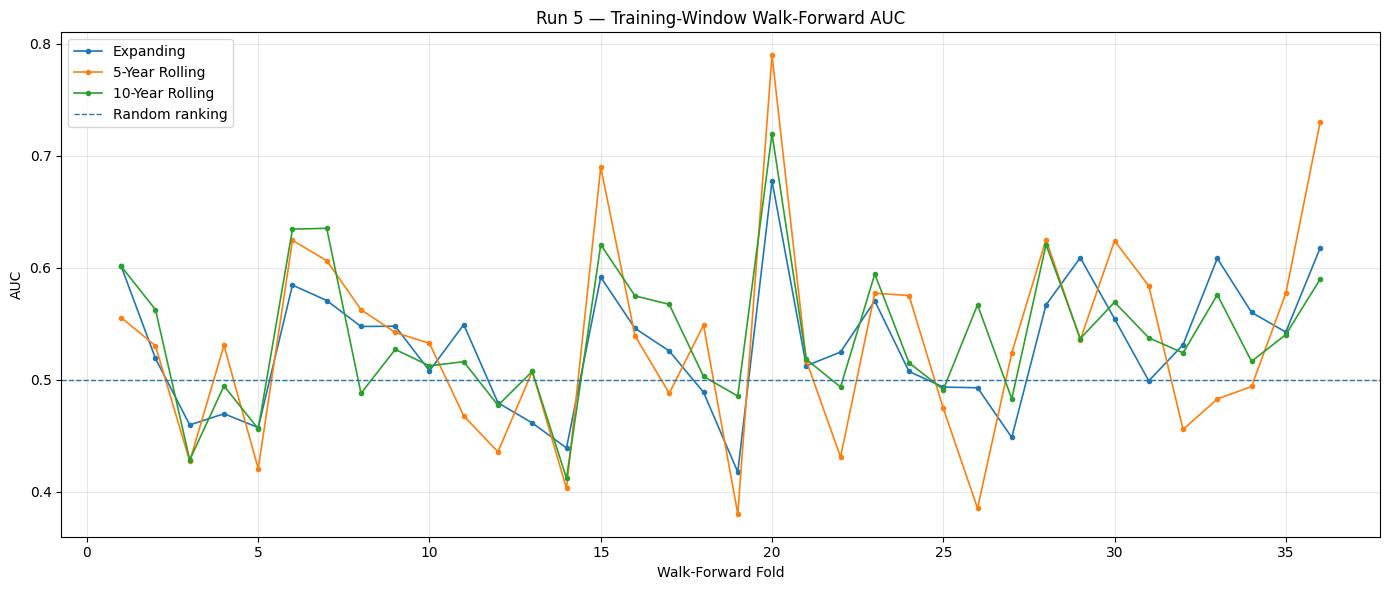

In [66]:
plt.figure(figsize=(14, 6))

for window_name in window_order:

    window_data = run5_fold_df[
        run5_fold_df['Window']
        == window_name
    ]

    plt.plot(
        window_data['Fold'],
        window_data['AUC'],
        marker='o',
        markersize=3,
        linewidth=1.2,
        label=window_name
    )


plt.axhline(
    0.50,
    linestyle='--',
    linewidth=1,
    label='Random ranking'
)

plt.xlabel('Walk-Forward Fold')
plt.ylabel('AUC')
plt.title(
    'Run 5 — Training-Window '
    'Walk-Forward AUC'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'run5_training_window_auc.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [67]:
run5_fold_df.to_csv(
    'run5_window_fold_results.csv',
    index=False
)

run5_summary.to_csv(
    'run5_window_summary.csv',
    index=False
)

run5_paired_auc.to_csv(
    'run5_window_paired_comparison.csv'
)

print("Run 5 result files saved.")

Run 5 result files saved.


## 6. Walk-Forward Evaluation

The final leakage-safe evaluation. Configuration settled in Sections 4 and 5:

| Choice | Value | Why |
|---|---|---|
| Model | Random Forest | Section 4c, training CV; confirmed in 5a on walk-forward |
| Features | 48 hybrid | Section 5a, paired significance against both isolated sets |
| Training window | 10-year rolling (2,520 rows) | Section 5c, nominal selection |
| Test folds | 36 non-overlapping, 60 days each | No test day scored twice |
| Purge gap | 1 row | The target at *t* depends on the close at *t+1* |
| Validation window | 252 days | Threshold selection only, never the test fold |
| Transaction cost | 1 basis point per unit turnover | Applied in Section 7 |

Nothing from a test fold influences training, hyperparameters or threshold selection.

In [68]:
# Run 6 configuration

df_run6 = df.copy()
run6_features = feature_cols.copy()

assert len(run6_features) == 48

# Return from today's close to the next trading day's close
df_run6['forward_log_return'] = (
    df_run6['log_return']
    .shift(-1)
)

df_run6['forward_return'] = np.expm1(
    df_run6['forward_log_return']
)

TRADING_DAYS_PER_YEAR = 252

RUN6_TRAIN_WINDOW = (
    10 * TRADING_DAYS_PER_YEAR
)

RUN6_VALIDATION_WINDOW = 252
RUN6_TEST_WINDOW = 60
RUN6_STEP = 60

# Purge one row because target[t] depends on close[t+1]
RUN6_PURGE_GAP = 1

RUN6_INITIAL_TEST_START = (
    RUN6_TRAIN_WINDOW
    + RUN6_PURGE_GAP
)

# Main cost assumption:
# 1 basis point per unit of position turnover
RUN6_COST_BPS = 1
RUN6_COST_RATE = (
    RUN6_COST_BPS / 10000
)

RUN6_THRESHOLD_GRID = np.array([
    0.50,
    0.52,
    0.54,
    0.56,
    0.58,
    0.60
])

expected_run6_folds = (
    (
        len(df_run6)
        - RUN6_INITIAL_TEST_START
        - RUN6_TEST_WINDOW
    )
    // RUN6_STEP
    + 1
)

print("Run 6 setup")
print(f"Dataset rows: {len(df_run6)}")
print(f"Features: {len(run6_features)}")
print(f"Training window: {RUN6_TRAIN_WINDOW}")
print(f"Validation window: {RUN6_VALIDATION_WINDOW}")
print(f"Purge gap: {RUN6_PURGE_GAP}")
print(f"Expected folds: {expected_run6_folds}")
print(
    "Expected daily predictions:",
    expected_run6_folds * RUN6_TEST_WINDOW
)
print(
    "Main transaction cost:",
    f"{RUN6_COST_BPS} basis point"
)

Run 6 setup
Dataset rows: 4727
Features: 48
Training window: 2520
Validation window: 252
Purge gap: 1
Expected folds: 36
Expected daily predictions: 2160
Main transaction cost: 1 basis point


In [69]:
def positions_from_probability(
    probabilities,
    upper_threshold,
    strategy
):
    """
    Convert P(UP) into trading positions.

    Positions:
        1  = long EUR/USD
        0  = cash
       -1  = short EUR/USD
    """

    probabilities = np.asarray(
        probabilities,
        dtype=float
    )

    upper_threshold = np.asarray(
        upper_threshold,
        dtype=float
    )

    lower_threshold = (
        1 - upper_threshold
    )

    if strategy == 'long_short':

        positions = np.where(
            probabilities >= upper_threshold,
            1,
            np.where(
                probabilities <= lower_threshold,
                -1,
                0
            )
        )

    elif strategy == 'long_only':

        positions = np.where(
            probabilities >= upper_threshold,
            1,
            0
        )

    elif strategy == 'overlay':

        # Remain invested unless there is
        # a confident DOWN prediction
        positions = np.where(
            probabilities <= lower_threshold,
            0,
            1
        )

    else:
        raise ValueError(
            f"Unknown strategy: {strategy}"
        )

    return positions.astype(float)


def apply_positions(
    positions,
    market_returns,
    cost_rate
):
    """
    Apply positions to next-day market returns.

    Transaction costs are charged only when
    the position changes.
    """

    market_returns = pd.Series(
        market_returns,
        copy=True
    ).astype(float)

    positions = pd.Series(
        np.asarray(
            positions,
            dtype=float
        ),
        index=market_returns.index
    )

    previous_position = (
        positions
        .shift(1)
        .fillna(0.0)
)

    turnover = (
        positions
        - previous_position
    ).abs()

    gross_return = (
        positions
        * market_returns
    )

    transaction_cost = (
        turnover
        * cost_rate
    )

    net_return = (
        gross_return
        - transaction_cost
    )

    wealth = (
        1 + net_return
    ).cumprod()

    running_peak = wealth.cummax()

    drawdown = (
        wealth / running_peak
        - 1
    )

    return pd.DataFrame({
        'Position': positions,
        'Turnover': turnover,
        'Gross Return': gross_return,
        'Transaction Cost':
            transaction_cost,
        'Net Return': net_return,
        'Wealth': wealth,
        'Drawdown': drawdown
    })


def annualised_sharpe(returns):
    """
    Annualised Sharpe ratio using zero risk-free rate.
    """

    returns = pd.Series(
        returns
    ).dropna()

    return_std = returns.std(
        ddof=1
    )

    if (
        len(returns) < 2
        or return_std <= 1e-12
    ):
        return 0.0

    return (
        returns.mean()
        / return_std
        * np.sqrt(
            TRADING_DAYS_PER_YEAR
        )
    )


def calculate_performance(
    strategy_frame
):
    net_returns = (
        strategy_frame['Net Return']
        .dropna()
    )

    gross_returns = (
        strategy_frame['Gross Return']
        .dropna()
    )

    wealth = (
        1 + net_returns
    ).cumprod()

    total_return = (
        wealth.iloc[-1] - 1
    )

    gross_total_return = (
        (1 + gross_returns)
        .prod()
        - 1
    )

    years = (
        len(net_returns)
        / TRADING_DAYS_PER_YEAR
    )

    if (
        years > 0
        and wealth.iloc[-1] > 0
    ):
        annualised_return = (
            wealth.iloc[-1]
            ** (1 / years)
            - 1
        )
    else:
        annualised_return = np.nan

    trades = int(
        (
            strategy_frame['Turnover']
            > 0
        ).sum()
    )

    return {
        'Gross Return':
            gross_total_return,

        'Net Return':
            total_return,

        'Annualised Return':
            annualised_return,

        'Annualised Volatility':
            net_returns.std(ddof=1)
            * np.sqrt(
                TRADING_DAYS_PER_YEAR
            ),

        'Sharpe':
            annualised_sharpe(
                net_returns
            ),

        'Max Drawdown':
            strategy_frame[
                'Drawdown'
            ].min(),

        'Trades':
            trades,

        'Turnover Units':
            strategy_frame[
                'Turnover'
            ].sum(),

        'Long Exposure':
            (
                strategy_frame[
                    'Position'
                ] > 0
            ).mean(),

        'Short Exposure':
            (
                strategy_frame[
                    'Position'
                ] < 0
            ).mean(),

        'Cash Exposure':
            (
                strategy_frame[
                    'Position'
                ] == 0
            ).mean()
    }

In [70]:
def select_overlay_threshold(
    probabilities,
    market_returns,
    cost_rate
):
    """
    Select the threshold using only validation data.

    The validation objective is the net Sharpe ratio
    of the Buy-and-Hold plus ML overlay.
    """

    threshold_records = []

    market_returns = pd.Series(
        market_returns
    )

    for threshold in RUN6_THRESHOLD_GRID:

        positions = (
            positions_from_probability(
                probabilities,
                threshold,
                strategy='overlay'
            )
        )

        strategy_frame = (
            apply_positions(
                positions,
                market_returns,
                cost_rate
            )
        )

        performance = (
            calculate_performance(
                strategy_frame
            )
        )

        threshold_records.append({
            'Threshold':
                threshold,

            'Validation Net Return':
                performance[
                    'Net Return'
                ],

            'Validation Sharpe':
                performance[
                    'Sharpe'
                ],

            'Validation Max Drawdown':
                performance[
                    'Max Drawdown'
                ],

            'Validation Trades':
                performance[
                    'Trades'
                ],

            'Validation Cash Exposure':
                performance[
                    'Cash Exposure'
                ]
        })

    threshold_table = pd.DataFrame(
        threshold_records
    )

    threshold_table[
        'Ranking Sharpe'
    ] = (
        threshold_table[
            'Validation Sharpe'
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(-np.inf)
    )

    ranked_table = (
        threshold_table
        .sort_values(
            [
                'Ranking Sharpe',
                'Validation Net Return',
                'Threshold'
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
    )

    selected_threshold = float(
        ranked_table.iloc[0][
            'Threshold'
        ]
    )

    threshold_table = (
        threshold_table
        .drop(
            columns=['Ranking Sharpe']
        )
    )

    return (
        selected_threshold,
        threshold_table
    )

In [71]:
run6_daily_parts = []
run6_fold_records = []
run6_threshold_records = []

test_start = RUN6_INITIAL_TEST_START
fold_number = 1


while (
    test_start + RUN6_TEST_WINDOW
    <= len(df_run6)
):

    test_end = (
        test_start
        + RUN6_TEST_WINDOW
    )

    # End training before the one-row purge
    outer_train_end = (
        test_start
        - RUN6_PURGE_GAP
    )

    outer_train_start = (
        outer_train_end
        - RUN6_TRAIN_WINDOW
    )

    # Final year of the training window
    # is used for threshold validation
    validation_end = outer_train_end

    validation_start = (
        validation_end
        - RUN6_VALIDATION_WINDOW
    )

    # Separate inner training and validation
    # with another one-row purge
    inner_train_end = (
        validation_start
        - RUN6_PURGE_GAP
    )

    if outer_train_start < 0:
        raise ValueError(
            "Insufficient outer training data"
        )

    if inner_train_end <= outer_train_start:
        raise ValueError(
            "Insufficient inner training data"
        )

    # Inner model used only for threshold selection
    X_inner_train = (
        df_run6[run6_features]
        .iloc[
            outer_train_start:
            inner_train_end
        ]
    )

    y_inner_train = (
        df_run6['target']
        .iloc[
            outer_train_start:
            inner_train_end
        ]
    )

    X_validation = (
        df_run6[run6_features]
        .iloc[
            validation_start:
            validation_end
        ]
    )

    validation_returns = (
        df_run6['forward_return']
        .iloc[
            validation_start:
            validation_end
        ]
    )

    if validation_returns.isna().any():
        raise ValueError(
            f"Missing validation returns "
            f"in fold {fold_number}"
        )

    validation_model = (
        RandomForestClassifier(
            **RUN2_RF_PARAMS,
            random_state=42,
            n_jobs=-1
        )
    )

    validation_model.fit(
        X_inner_train,
        y_inner_train
    )

    validation_probability = (
        validation_model
        .predict_proba(
            X_validation
        )[:, 1]
    )

    (
        selected_threshold,
        threshold_table
    ) = select_overlay_threshold(
        validation_probability,
        validation_returns,
        RUN6_COST_RATE
    )

    threshold_table.insert(
        0,
        'Fold',
        fold_number
    )

    threshold_table[
        'Outer Test Start'
    ] = df_run6.index[
        test_start
    ]

    run6_threshold_records.append(
        threshold_table
    )

    selected_validation_row = (
        threshold_table.loc[
            np.isclose(
                threshold_table[
                    'Threshold'
                ],
                selected_threshold
            )
        ]
        .iloc[0]
    )

    # Final model receives the complete
    # purged ten-year training window
    X_outer_train = (
        df_run6[run6_features]
        .iloc[
            outer_train_start:
            outer_train_end
        ]
    )

    y_outer_train = (
        df_run6['target']
        .iloc[
            outer_train_start:
            outer_train_end
        ]
    )

    X_test_fold = (
        df_run6[run6_features]
        .iloc[
            test_start:
            test_end
        ]
    )

    y_test_fold = (
        df_run6['target']
        .iloc[
            test_start:
            test_end
        ]
    )

    test_returns = (
        df_run6['forward_return']
        .iloc[
            test_start:
            test_end
        ]
    )

    if test_returns.isna().any():
        raise ValueError(
            f"Missing test returns "
            f"in fold {fold_number}"
        )

    final_model = (
        RandomForestClassifier(
            **RUN2_RF_PARAMS,
            random_state=42,
            n_jobs=-1
        )
    )

    final_model.fit(
        X_outer_train,
        y_outer_train
    )

    test_probability = (
        final_model
        .predict_proba(
            X_test_fold
        )[:, 1]
    )

    test_prediction = (
        test_probability >= 0.50
    ).astype(int)

    test_auc = roc_auc_score(
        y_test_fold,
        test_probability
    )

    fold_daily = pd.DataFrame(
        {
            'Fold':
                fold_number,

            'Probability UP':
                test_probability,

            'Predicted Class':
                test_prediction,

            'Actual Target':
                y_test_fold.values,

            'Forward Return':
                test_returns.values,

            'Selected Threshold':
                selected_threshold
        },
        index=X_test_fold.index
    )

    fold_daily.index.name = 'Date'

    run6_daily_parts.append(
        fold_daily
    )

    run6_fold_records.append({
        'Fold':
            fold_number,

        'Outer Train Start':
            X_outer_train.index[0],

        'Outer Train End':
            X_outer_train.index[-1],

        'Outer Training Rows':
            len(X_outer_train),

        'Outer Purge Date':
            df_run6.index[
                test_start - 1
            ],

        'Validation Start':
            X_validation.index[0],

        'Validation End':
            X_validation.index[-1],

        'Inner Training Rows':
            len(X_inner_train),

        'Validation Rows':
            len(X_validation),

        'Test Start':
            X_test_fold.index[0],

        'Test End':
            X_test_fold.index[-1],

        'Selected Threshold':
            selected_threshold,

        'Validation Overlay Sharpe':
            selected_validation_row[
                'Validation Sharpe'
            ],

        'Validation Overlay Return':
            selected_validation_row[
                'Validation Net Return'
            ],

        'Test AUC':
            test_auc
    })

    print(
        f"Fold {fold_number:02d}: "
        f"threshold={selected_threshold:.2f}, "
        f"AUC={test_auc:.4f}"
    )

    test_start += RUN6_STEP
    fold_number += 1


run6_daily_df = pd.concat(
    run6_daily_parts
).sort_index()

run6_fold_df = pd.DataFrame(
    run6_fold_records
)

run6_threshold_df = pd.concat(
    run6_threshold_records,
    ignore_index=True
)


assert (
    len(run6_fold_df)
    == expected_run6_folds
)

assert (
    len(run6_daily_df)
    == expected_run6_folds
    * RUN6_TEST_WINDOW
)

assert not (
    run6_daily_df.index
    .duplicated()
    .any()
)

assert (
    run6_daily_df[
        'Forward Return'
    ]
    .notna()
    .all()
)


print("\nRun 6 predictions complete.")
print(
    "Folds:",
    len(run6_fold_df)
)
print(
    "Daily predictions:",
    len(run6_daily_df)
)

Fold 01: threshold=0.52, AUC=0.6011
Fold 02: threshold=0.52, AUC=0.5513
Fold 03: threshold=0.54, AUC=0.4421
Fold 04: threshold=0.54, AUC=0.4926
Fold 05: threshold=0.52, AUC=0.4475
Fold 06: threshold=0.52, AUC=0.6207
Fold 07: threshold=0.52, AUC=0.6518
Fold 08: threshold=0.50, AUC=0.4939
Fold 09: threshold=0.50, AUC=0.5303
Fold 10: threshold=0.52, AUC=0.4917
Fold 11: threshold=0.50, AUC=0.5130
Fold 12: threshold=0.50, AUC=0.4710
Fold 13: threshold=0.52, AUC=0.5145
Fold 14: threshold=0.60, AUC=0.4149
Fold 15: threshold=0.58, AUC=0.6185
Fold 16: threshold=0.58, AUC=0.5558
Fold 17: threshold=0.52, AUC=0.5772
Fold 18: threshold=0.60, AUC=0.5112
Fold 19: threshold=0.50, AUC=0.4785
Fold 20: threshold=0.50, AUC=0.7119
Fold 21: threshold=0.50, AUC=0.5311
Fold 22: threshold=0.50, AUC=0.5100
Fold 23: threshold=0.52, AUC=0.5752
Fold 24: threshold=0.50, AUC=0.5256
Fold 25: threshold=0.60, AUC=0.4804
Fold 26: threshold=0.52, AUC=0.5498
Fold 27: threshold=0.52, AUC=0.4772
Fold 28: threshold=0.56, AUC

In [72]:
run6_combined_auc = roc_auc_score(
    run6_daily_df['Actual Target'],
    run6_daily_df['Probability UP']
)

run6_mean_fold_auc = (
    run6_fold_df['Test AUC']
    .mean()
)

run6_std_fold_auc = (
    run6_fold_df['Test AUC']
    .std()
)

run6_folds_above_050 = (
    run6_fold_df['Test AUC']
    .gt(0.50)
    .sum()
)

run6_folds_above_055 = (
    run6_fold_df['Test AUC']
    .gt(0.55)
    .sum()
)


print("Run 6 predictive performance")
print(
    "Combined out-of-sample AUC:",
    f"{run6_combined_auc:.4f}"
)
print(
    "Mean fold AUC:",
    f"{run6_mean_fold_auc:.4f}"
)
print(
    "Fold AUC standard deviation:",
    f"{run6_std_fold_auc:.4f}"
)
print(
    "Folds above 0.50:",
    f"{run6_folds_above_050}"
    f"/{len(run6_fold_df)}"
)
print(
    "Folds above 0.55:",
    f"{run6_folds_above_055}"
    f"/{len(run6_fold_df)}"
)

Run 6 predictive performance
Combined out-of-sample AUC: 0.5145
Mean fold AUC: 0.5389
Fold AUC standard deviation: 0.0621
Folds above 0.50: 26/36
Folds above 0.55: 14/36


In [73]:
# FINAL REVIEW EDIT 3 — Run 6 exploratory fold-level significance

from scipy import stats


# Obtain the 36 out-of-sample fold AUC values
run6_fold_auc_values = (
    run6_fold_df['Test AUC']
    .dropna()
    .to_numpy()
)


# Test whether the mean fold AUC is above random performance of 0.50
t_statistic, p_two_sided = stats.ttest_1samp(
    run6_fold_auc_values,
    popmean=0.50
)


# Convert to a one-sided p-value for:
# H1: mean fold AUC > 0.50
if t_statistic > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - (p_two_sided / 2)


# Conservative adjustment for the 30 reported configurations
# examined across Runs 3, 4 and 5
number_of_reported_configurations = 30

p_bonferroni = min(
    p_one_sided
    * number_of_reported_configurations,
    1.0
)


print("Run 6 exploratory fold-level significance test")
print("-" * 55)

print(
    "Number of folds:",
    len(run6_fold_auc_values)
)

print(
    "Mean fold AUC:",
    f"{run6_fold_auc_values.mean():.6f}"
)

print(
    "t-statistic:",
    f"{t_statistic:.3f}"
)

print(
    "Two-sided p-value:",
    f"{p_two_sided:.6f}"
)

print(
    "One-sided p-value:",
    f"{p_one_sided:.6f}"
)

print(
    "Bonferroni-adjusted p-value:",
    f"{p_bonferroni:.6f}"
)

Run 6 exploratory fold-level significance test
-------------------------------------------------------
Number of folds: 36
Mean fold AUC: 0.538853
t-statistic: 3.754
Two-sided p-value: 0.000632
One-sided p-value: 0.000316
Bonferroni-adjusted p-value: 0.009484


## Run 6 Predictive Interpretation

Mean fold AUC was **0.5389** across 36 non-overlapping test periods.
Fold-level AUC is used as the main descriptive result because each fold
measures ranking ability within a period using a model trained only on
preceding observations.

The pooled out-of-sample AUC was **0.5145**. It is reported as a secondary
result because the 36 separately trained models may produce differently
calibrated probability scales. Probabilities from different folds are
therefore not necessarily directly comparable.

### Exploratory statistical analysis

A one-sample test against random ranking performance of AUC 0.50 produced:

- t-statistic = **3.754**
- one-sided p-value = **0.000316**
- Bonferroni-adjusted p-value for 30 reported configurations =
  approximately **0.0095**

The result suggests that average fold-level ranking performance was above
0.50. However, this inference is treated as exploratory because training
windows overlap, adjacent market periods may not be completely independent,
and the same historical dataset contributed to model and feature
selection.

The Bonferroni calculation covers the 30 reported configurations across
Runs 3 to 5. It is not an exhaustive correction for every hyperparameter,
threshold and modelling decision made during the project.

### 6b. Tuning-Contamination Check

The grid search in Section 4b trained on data ending 2022-05-10. Folds 1 to 21 fall inside
that window; folds 22 to 36 do not.

If hyperparameter tuning were inflating the result, the clean folds would score *lower*.

In [74]:
from scipy import stats as _stats
import numpy as _np
import pandas as _pd

TUNING_CUTOFF_FOLD = 21


def _fold_stats(values, label, period):
    values = _np.asarray(values, dtype=float)
    t_stat, p_two = _stats.ttest_1samp(values, popmean=0.50)
    p_one = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)
    return {
        'Folds': label,
        'Period': period,
        'n': len(values),
        'Mean AUC': round(float(values.mean()), 4),
        'Above 0.50': f"{int((values > 0.50).sum())}/{len(values)}",
        'One-sided p': round(float(p_one), 4),
    }


_fold_auc = run6_fold_df['Test AUC'].to_numpy(dtype=float)

clean_fold_table = _pd.DataFrame([
    _fold_stats(_fold_auc[:TUNING_CUTOFF_FOLD],
                f"1-{TUNING_CUTOFF_FOLD} (inside tuning window)", "2017-07 to 2022-05"),
    _fold_stats(_fold_auc[TUNING_CUTOFF_FOLD:],
                f"{TUNING_CUTOFF_FOLD+1}-{len(_fold_auc)} (clean)", "2022-06 to 2025-10"),
    _fold_stats(_fold_auc, "All", "2017-07 to 2025-10"),
])

clean_fold_table.to_csv('run6_clean_fold_table.csv', index=False)

print("Tuning-contamination check")
print(clean_fold_table.to_string(index=False))
print()
print("Clean folds score higher, so tuning is not driving the result.")
print("Caveat: n=15, single market regime.")

Tuning-contamination check
                      Folds             Period  n  Mean AUC Above 0.50  One-sided p
1-21 (inside tuning window) 2017-07 to 2022-05 21    0.5343      13/21       0.0238
              22-36 (clean) 2022-06 to 2025-10 15    0.5452      13/15       0.0004
                        All 2017-07 to 2025-10 36    0.5389      26/36       0.0003

Clean folds score higher, so tuning is not driving the result.
Caveat: n=15, single market regime.


## 7. Trade Signal Generation and Backtest

Probabilities become positions. Four strategies are compared, all at a one-basis-point
transaction cost charged on every unit of position turnover.

The threshold is selected on the validation year inside each training window, never on the
test fold. Watch the position-change column: the overlay changes position 333 times, which
is what turns +4.94% gross into +1.51% net.

In [75]:
probabilities = (
    run6_daily_df[
        'Probability UP'
    ].values
)

thresholds = (
    run6_daily_df[
        'Selected Threshold'
    ].values
)

market_returns = (
    run6_daily_df[
        'Forward Return'
    ]
)


run6_positions = {
    'Buy and Hold':
        np.ones(
            len(run6_daily_df)
        ),

    'ML Long-Short':
        positions_from_probability(
            probabilities,
            thresholds,
            strategy='long_short'
        ),

    'ML Long-Only':
        positions_from_probability(
            probabilities,
            thresholds,
            strategy='long_only'
        ),

    'B&H + ML Overlay':
        positions_from_probability(
            probabilities,
            thresholds,
            strategy='overlay'
        )
}


run6_strategy_frames = {}
run6_strategy_records = []


column_prefixes = {
    'Buy and Hold':
        'buy_hold',

    'ML Long-Short':
        'ml_long_short',

    'ML Long-Only':
        'ml_long_only',

    'B&H + ML Overlay':
        'buy_hold_ml_overlay'
}


for (
    strategy_name,
    positions
) in run6_positions.items():

    strategy_frame = apply_positions(
        positions,
        market_returns,
        RUN6_COST_RATE
    )

    run6_strategy_frames[
        strategy_name
    ] = strategy_frame

    performance = calculate_performance(
        strategy_frame
    )

    performance[
        'Strategy'
    ] = strategy_name

    run6_strategy_records.append(
        performance
    )

    prefix = column_prefixes[
        strategy_name
    ]

    run6_daily_df[
        f'{prefix}_position'
    ] = strategy_frame[
        'Position'
    ]

    run6_daily_df[
        f'{prefix}_turnover'
    ] = strategy_frame[
        'Turnover'
    ]

    run6_daily_df[
        f'{prefix}_net_return'
    ] = strategy_frame[
        'Net Return'
    ]

    run6_daily_df[
        f'{prefix}_wealth'
    ] = strategy_frame[
        'Wealth'
    ]

    run6_daily_df[
        f'{prefix}_drawdown'
    ] = strategy_frame[
        'Drawdown'
    ]


run6_strategy_summary = pd.DataFrame(
    run6_strategy_records
)


strategy_order = [
    'Buy and Hold',
    'ML Long-Short',
    'ML Long-Only',
    'B&H + ML Overlay'
]


run6_strategy_summary[
    'Strategy'
] = pd.Categorical(
    run6_strategy_summary[
        'Strategy'
    ],
    categories=strategy_order,
    ordered=True
)

run6_strategy_summary = (
    run6_strategy_summary
    .sort_values('Strategy')
    .reset_index(drop=True)
)


summary_columns = [
    'Strategy',
    'Gross Return',
    'Net Return',
    'Annualised Return',
    'Sharpe',
    'Max Drawdown',
    'Trades',
    'Turnover Units',
    'Long Exposure',
    'Short Exposure',
    'Cash Exposure'
]


display(
    run6_strategy_summary[
        summary_columns
    ].round(4)
)

,Strategy,Gross Return,Net Return,Annualised Return,Sharpe,Max Drawdown,Trades,Turnover Units,Long Exposure,Short Exposure,Cash Exposure
0,Buy and Hold,0.0181,0.0180,0.0021,0.0649,-0.2329,1,1.0,1.0000,0.0000,0.0000
1,ML Long-Short,-0.0307,-0.0810,-0.0098,-0.1744,-0.1965,357,533.0,0.1611,0.2574,0.5815
2,ML Long-Only,-0.0473,-0.0663,-0.0080,-0.2471,-0.1520,201,201.0,0.1611,0.0000,0.8389
3,B&H + ML Overlay,0.0494,0.0151,0.0017,0.0591,-0.1881,333,333.0,0.7426,0.0000,0.2574


In [76]:
run6_display_summary = (
    run6_strategy_summary[
        summary_columns
    ]
    .copy()
)


percentage_columns = [
    'Gross Return',
    'Net Return',
    'Annualised Return',
    'Max Drawdown',
    'Long Exposure',
    'Short Exposure',
    'Cash Exposure'
]


for column in percentage_columns:

    run6_display_summary[
        column
    ] = (
        run6_display_summary[
            column
        ]
        * 100
    )


display(
    run6_display_summary.round(2)
)

,Strategy,Gross Return,Net Return,Annualised Return,Sharpe,Max Drawdown,Trades,Turnover Units,Long Exposure,Short Exposure,Cash Exposure
0,Buy and Hold,1.81,1.80,0.21,0.06,-23.29,1,1.0,100.00,0.00,0.00
1,ML Long-Short,-3.07,-8.10,-0.98,-0.17,-19.65,357,533.0,16.11,25.74,58.15
2,ML Long-Only,-4.73,-6.63,-0.80,-0.25,-15.20,201,201.0,16.11,0.00,83.89
3,B&H + ML Overlay,4.94,1.51,0.17,0.06,-18.81,333,333.0,74.26,0.00,25.74


In [77]:
run6_cost_sensitivity_records = []

cost_levels_bps = [
    0,
    1,
    2,
    5
]


for cost_bps in cost_levels_bps:

    cost_rate = (
        cost_bps / 10000
    )

    for (
        strategy_name,
        positions
    ) in run6_positions.items():

        strategy_frame = apply_positions(
            positions,
            market_returns,
            cost_rate
        )

        performance = calculate_performance(
            strategy_frame
        )

        run6_cost_sensitivity_records.append({
            'Cost BPS':
                cost_bps,

            'Strategy':
                strategy_name,

            'Net Return':
                performance[
                    'Net Return'
                ],

            'Sharpe':
                performance[
                    'Sharpe'
                ],

            'Max Drawdown':
                performance[
                    'Max Drawdown'
                ],

            'Trades':
                performance[
                    'Trades'
                ]
        })


run6_cost_sensitivity_df = pd.DataFrame(
    run6_cost_sensitivity_records
)


run6_cost_return_pivot = (
    run6_cost_sensitivity_df
    .pivot(
        index='Strategy',
        columns='Cost BPS',
        values='Net Return'
    )
    .reindex(strategy_order)
)


print(
    "Net return by transaction cost "
    "(displayed as percentages)"
)

display(
    (
        run6_cost_return_pivot
        * 100
    ).round(2)
)

Net return by transaction cost (displayed as percentages)


Cost BPS,0,1,2,5
Strategy,,,,
Buy and Hold,1.81,1.80,1.79,1.76
ML Long-Short,-3.07,-8.10,-12.87,-25.76
ML Long-Only,-4.73,-6.63,-8.49,-13.84
B&H + ML Overlay,4.94,1.51,-1.82,-11.16


In [78]:
run6_threshold_summary = (
    run6_fold_df[
        'Selected Threshold'
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        'Threshold'
    )
    .reset_index(
        name='Folds'
    )
)


print("Selected validation thresholds")

display(
    run6_threshold_summary
)

Selected validation thresholds


,Threshold,Folds
0,0.50,12
1,0.52,15
2,0.54,3
3,0.56,1
4,0.58,2
5,0.60,3


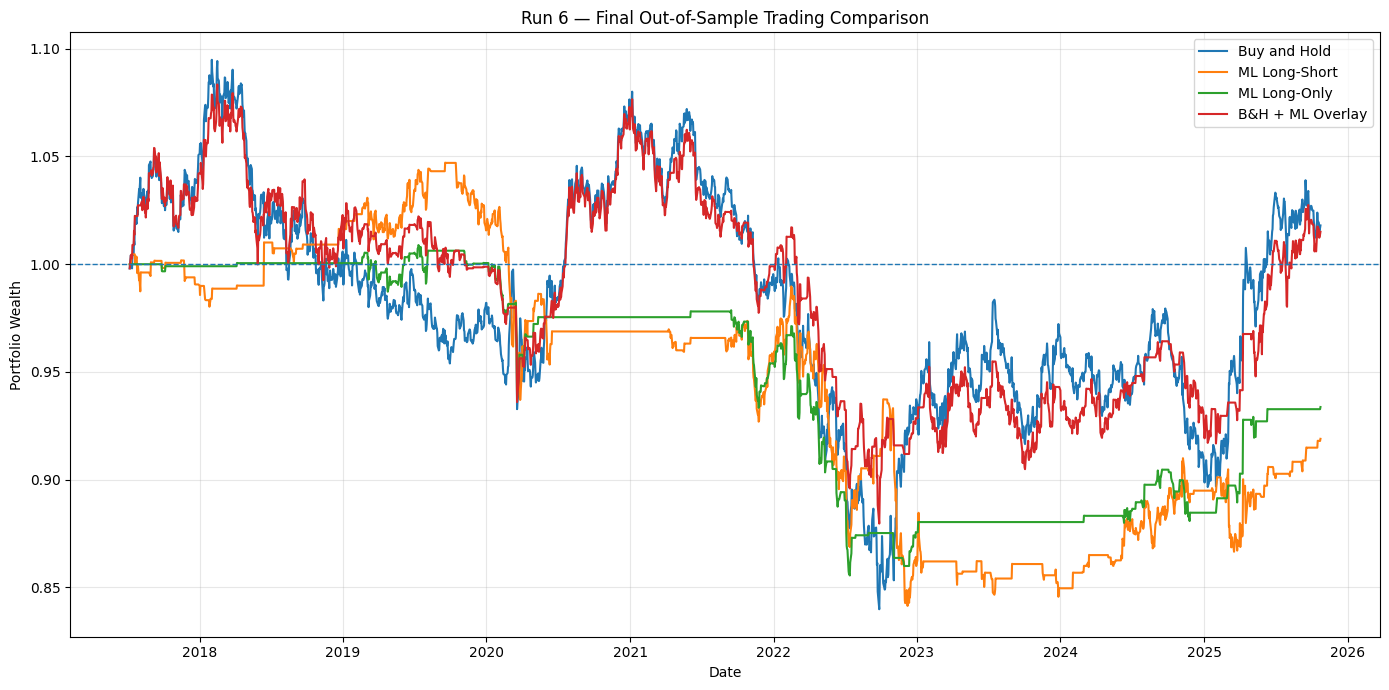

In [79]:
plt.figure(
    figsize=(14, 7)
)


for strategy_name in strategy_order:

    strategy_frame = (
        run6_strategy_frames[
            strategy_name
        ]
    )

    plt.plot(
        run6_daily_df.index,
        strategy_frame['Wealth'],
        linewidth=1.5,
        label=strategy_name
    )


plt.axhline(
    1.0,
    linestyle='--',
    linewidth=1
)

plt.xlabel('Date')
plt.ylabel('Portfolio Wealth')
plt.title(
    'Run 6 — Final Out-of-Sample '
    'Trading Comparison'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'run6_equity_curves.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

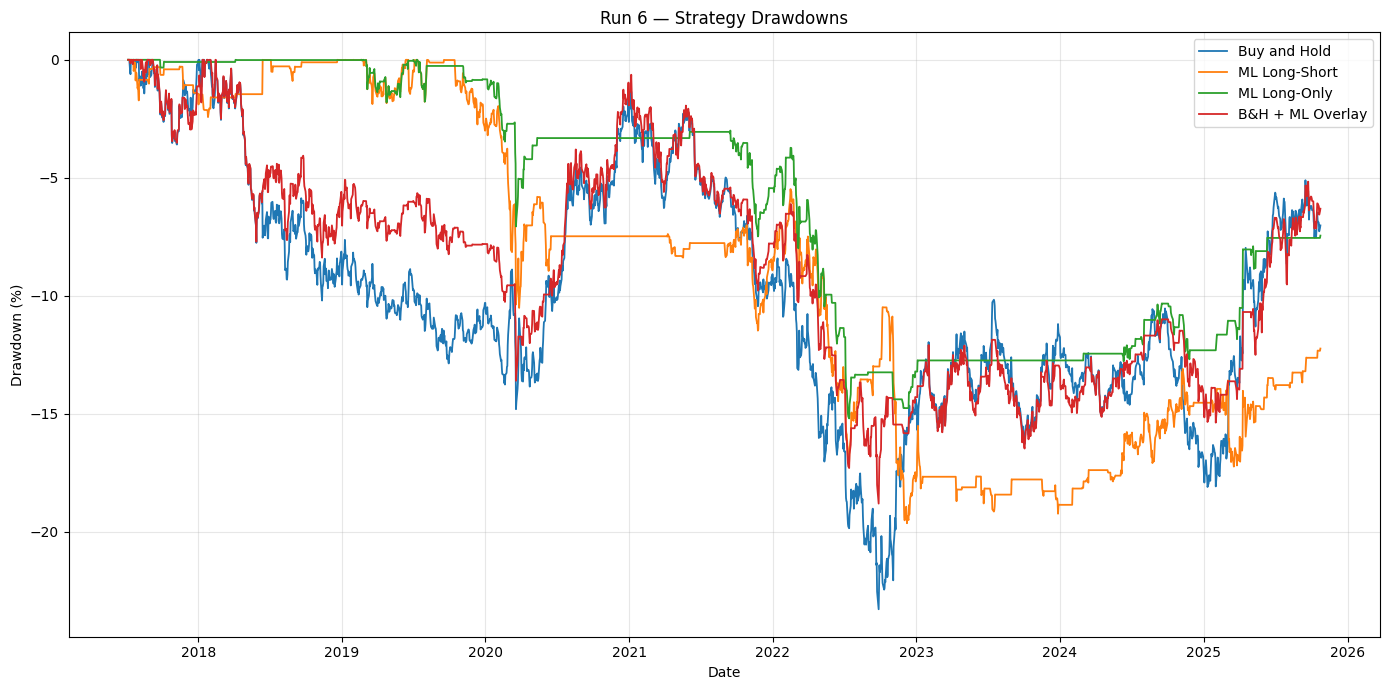

In [80]:
plt.figure(
    figsize=(14, 7)
)

for strategy_name in strategy_order:

    strategy_frame = (
        run6_strategy_frames[
            strategy_name
        ]
    )

    plt.plot(
        run6_daily_df.index,
        strategy_frame[
            'Drawdown'
        ] * 100,
        linewidth=1.3,
        label=strategy_name
    )

plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.title(
    'Run 6 — Strategy Drawdowns'
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'run6_drawdowns.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

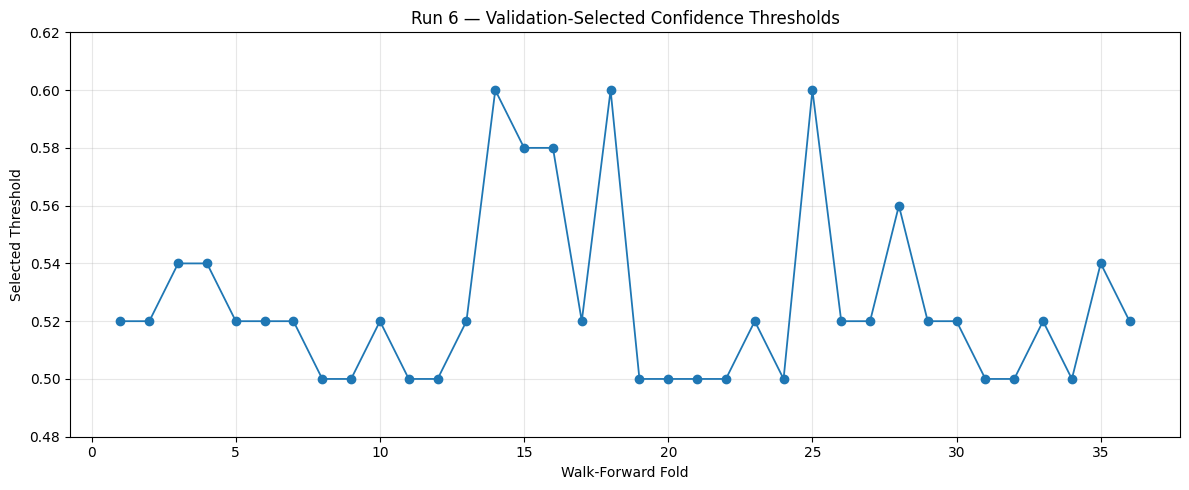

In [81]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    run6_fold_df['Fold'],
    run6_fold_df[
        'Selected Threshold'
    ],
    marker='o',
    linewidth=1.3
)

plt.xlabel('Walk-Forward Fold')
plt.ylabel('Selected Threshold')
plt.title(
    'Run 6 — Validation-Selected '
    'Confidence Thresholds'
)
plt.ylim(
    0.48,
    0.62
)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'run6_selected_thresholds.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [82]:
run6_daily_df.to_csv(
    'run6_daily_predictions_and_returns.csv'
)

run6_fold_df.to_csv(
    'run6_fold_results.csv',
    index=False
)

run6_threshold_df.to_csv(
    'run6_threshold_validation_results.csv',
    index=False
)

run6_strategy_summary.to_csv(
    'run6_strategy_summary.csv',
    index=False
)

run6_cost_sensitivity_df.to_csv(
    'run6_cost_sensitivity.csv',
    index=False
)

run6_threshold_summary.to_csv(
    'run6_selected_threshold_summary.csv',
    index=False
)

print("Run 6 result files saved.")

Run 6 result files saved.


# Final Run 6 Interpretation

## Risk-management finding

- Buy and Hold maximum drawdown: **-23.29%**
- Buy-and-Hold plus ML overlay maximum drawdown: **-18.81%**
- Observed difference: approximately **4.48 percentage points**

This is one observed outcome over a single historical market path and
does not have a confidence interval. It is therefore suggestive of a
possible risk-management benefit rather than evidence of a demonstrated
risk-reduction effect.

## Buy-and-Hold context

Buy and Hold over the same 2,160-day out-of-sample window returned
**+1.80% net**, with:

- Maximum drawdown: **-23.29%**
- Sharpe ratio: **0.0649**
- Long exposure: **100%**

Unlike equity buy-and-hold, a long EUR/USD position does not represent
ownership of a productive asset. Its return depends on the exchange-rate
path and, in live trading, financing and carry.

Buy and Hold is therefore used in this project as a simple directional
baseline rather than a benchmark that is theoretically expected to
generate a positive long-term return.

## Final conclusion

- The final Random Forest model achieved a mean fold AUC of **0.5389**.
- Its average fold-level performance was distinguishable from 0.50 under
  an exploratory statistical test.
- The standalone ML Long-Short and ML Long-Only strategies did not
  outperform Buy and Hold after transaction costs.
- The Buy-and-Hold plus ML overlay produced an observed reduction in
  maximum drawdown from 23.29% to 18.81%.
- This drawdown difference is suggestive and should not be described as a
  confirmed risk-management effect.
- The overlay produced a gross return of **+4.94%**, but frequent position
  changes reduced its net return to **+1.51%** at a one-basis-point cost.
- Buy and Hold returned **+1.80% net** over the same period.
- The final system is therefore better presented as a decision-support
  tool and possible risk filter than as a standalone autonomous trading
  strategy.

## Model-selection journey

Logistic Regression was selected in Run 2 using training cross-validation,
with CV AUC 0.5196 compared with 0.5121 for XGBoost and 0.5098 for Random
Forest.

Run 3 then evaluated all three models across technical-only, event-only
and hybrid feature sets. Hybrid Random Forest achieved the strongest mean
walk-forward result and was selected from Run 3 onward.

Run 4 found that the additional event-feature transformations did not
reliably outperform the original Hybrid feature set.

Run 5 found no statistically significant difference between the
expanding, five-year rolling and ten-year rolling training windows.
Ten-year rolling was retained as the nominal highest-mean configuration,
not as a demonstrated improvement.

Run 6 applied the final Random Forest configuration using a one-row purge
gap, validation-only threshold selection, transaction costs and fully
out-of-sample trading evaluation.

## Run 6 — Final Walk-Forward Trading Evaluation Results

### Purpose

Perform the final leakage-safe predictive and trading evaluation using:

- Baseline Hybrid features
- Random Forest
- Ten-year rolling training window
- Locked hyperparameters
- One-row purge gap
- Validation-only confidence-threshold selection
- Transaction costs

The test period contained 36 non-overlapping 60-trading-day folds,
producing 2,160 fully out-of-sample daily predictions.

### Final predictive performance

| Metric | Result |
|---|---:|
| Mean fold AUC | 0.5389 |
| Fold AUC standard deviation | 0.0621 |
| Folds above 0.50 | 26/36 |
| Folds above 0.55 | 14/36 |
| Combined out-of-sample AUC | 0.5145 |

The mean fold AUC is used as the main predictive result because each
fold was generated by a separately retrained model. Probabilities from
different folds may not be calibrated on exactly the same numerical
scale, making the pooled AUC a secondary result.

The small difference between the Run 5 AUC of 0.5387 and the final
Run 6 AUC of 0.5389 is caused by the one-row purge gap introduced in
Run 6.

### Trading results with one-basis-point transaction cost

| Strategy | Gross return | Net return | Sharpe | Maximum drawdown | Position changes |
|---|---:|---:|---:|---:|---:|
| Buy and Hold | +1.81% | +1.80% | 0.0649 | -23.29% | 1 |
| ML Long-Short | -3.07% | -8.10% | -0.1744 | -19.65% | 357 |
| ML Long-Only | -4.73% | -6.63% | -0.2471 | -15.20% | 201 |
| Buy-and-Hold + ML Overlay | +4.94% | +1.51% | 0.0591 | -18.81% | 333 |

The column labelled position changes counts every change in portfolio
position. It does not represent completed round-trip trades.

### Risk-management interpretation

The Buy-and-Hold plus ML overlay reduced maximum drawdown from
-23.29% to -18.81%, an improvement of approximately 4.48 percentage
points.

However, its net return of 1.51% remained slightly below the 1.80%
Buy-and-Hold return after applying one-basis-point transaction costs.

The standalone ML Long-Short and ML Long-Only strategies both produced
negative returns. Therefore, the model did not demonstrate sufficient
predictive strength to operate successfully as a standalone trading
strategy.

### Transaction-cost sensitivity

| Transaction cost | Overlay net return |
|---|---:|
| 0 basis points | +4.94% |
| 1 basis point | +1.51% |
| 2 basis points | -1.82% |
| 5 basis points | -11.16% |

The overlay generated a higher gross return than Buy and Hold before
costs. However, its 333 position changes caused the advantage to
disappear after realistic transaction costs.

### Confidence-threshold findings

The threshold was selected independently within each fold using only
the preceding validation period.

The two lowest thresholds were selected most frequently:

| Threshold | Folds selected |
|---|---:|
| 0.50 | 12 |
| 0.52 | 15 |
| 0.54 | 3 |
| 0.56 | 1 |
| 0.58 | 2 |
| 0.60 | 3 |

Thresholds of 0.50 and 0.52 were selected in 27 of 36 folds. These low
thresholds resulted in frequent position changes and increased the
strategy's sensitivity to transaction costs.

### Final conclusion

The final Random Forest model demonstrated modest predictive ability,
with a mean walk-forward AUC of 0.5389.

The model did not outperform Buy and Hold after transaction costs.
Nevertheless, the Buy-and-Hold plus ML overlay reduced maximum
drawdown, indicating that the model may provide value as a
risk-management filter.

The final results support presenting the system as a trading decision
assistant rather than an autonomous profit-generating trading system.

In [83]:
# =============================================================================
# RUN 7 - MODEL x HORIZON x BUY-AND-HOLD OVERLAY GRID
#
# Paste each block below as a separate notebook cell, AFTER cell 88
# (the Run 6 significance test) and BEFORE Section 8 interpretability.
#
# Requires these objects to already exist from earlier cells:
#   df, feature_cols, RUN2_LR_PARAMS, RUN2_RF_PARAMS, RUN2_XGB_PARAMS,
#   positions_from_probability, apply_positions, calculate_performance,
#   TRADING_DAYS_PER_YEAR
# =============================================================================


# -----------------------------------------------------------------------------
# CELL A - configuration and horizon targets
# -----------------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

RUN7_HORIZONS = [1, 3, 5]

RUN7_MODELS = {
    'Logistic Regression': ('lr', RUN2_LR_PARAMS),
    'Random Forest':       ('rf', RUN2_RF_PARAMS),
    'XGBoost':             ('xgb', RUN2_XGB_PARAMS)
}

# Fold geometry copied from Run 6 so the grid is directly comparable.
# The one deliberate change: the purge gap is fixed at the LARGEST horizon
# for every configuration, not at h. A larger gap than strictly required
# can never cause leakage, and it guarantees that all nine configurations
# share identical fold boundaries and identical test days.
RUN7_TRAIN_WINDOW      = 10 * TRADING_DAYS_PER_YEAR
RUN7_VALIDATION_WINDOW = 252
RUN7_TEST_WINDOW       = 60
RUN7_STEP              = 60
RUN7_PURGE_GAP         = max(RUN7_HORIZONS)
RUN7_COST_BPS          = 1
RUN7_COST_RATE         = RUN7_COST_BPS / 10000
RUN7_THRESHOLD_GRID    = np.array([0.50, 0.52, 0.54, 0.56, 0.58, 0.60])

# Build the shared dataset.
# Drop the final max(h) rows so every horizon has a valid target on
# exactly the same rows.
df_run7 = df.copy()
close_run7 = df_run7['close']

for h in RUN7_HORIZONS:
    forward_h = np.log(close_run7.shift(-h) / close_run7)
    df_run7[f'target_{h}d'] = (forward_h > 0).astype(float)
    df_run7.loc[forward_h.isna(), f'target_{h}d'] = np.nan

# One-day forward simple return, used for daily profit and loss
# regardless of the prediction horizon
df_run7['forward_return'] = close_run7.pct_change().shift(-1)

df_run7 = df_run7.iloc[:-max(RUN7_HORIZONS)].copy()

for h in RUN7_HORIZONS:
    assert df_run7[f'target_{h}d'].notna().all()
    df_run7[f'target_{h}d'] = df_run7[f'target_{h}d'].astype(int)

assert df_run7['forward_return'].notna().all()

run7_features = feature_cols.copy()
assert len(run7_features) == 48

RUN7_INITIAL_TEST_START = RUN7_TRAIN_WINDOW + RUN7_PURGE_GAP

run7_expected_folds = (
    (len(df_run7) - RUN7_INITIAL_TEST_START - RUN7_TEST_WINDOW)
    // RUN7_STEP
    + 1
)

print("Run 7 setup")
print(f"  Rows:              {len(df_run7)}")
print(f"  Features:          {len(run7_features)}")
print(f"  Horizons:          {RUN7_HORIZONS}")
print(f"  Models:            {list(RUN7_MODELS)}")
print(f"  Purge gap:         {RUN7_PURGE_GAP} (fixed at max horizon)")
print(f"  Expected folds:    {run7_expected_folds}")
print(f"  Configurations:    {len(RUN7_MODELS) * len(RUN7_HORIZONS)}")
for h in RUN7_HORIZONS:
    print(f"  UP rate at {h}d:     {df_run7[f'target_{h}d'].mean()*100:.1f}%")




Run 7 setup
  Rows:              4722
  Features:          48
  Horizons:          [1, 3, 5]
  Models:            ['Logistic Regression', 'Random Forest', 'XGBoost']
  Purge gap:         5 (fixed at max horizon)
  Expected folds:    36
  Configurations:    9
  UP rate at 1d:     49.6%
  UP rate at 3d:     49.7%
  UP rate at 5d:     49.5%


In [84]:
# -----------------------------------------------------------------------------
# CELL B - helpers: model factory, holding rule, threshold selection
# -----------------------------------------------------------------------------

def build_model(model_key):
    """Return an unfitted classifier using the frozen Section 4c parameters."""
    if model_key == 'lr':
        return LogisticRegression(
            **RUN2_LR_PARAMS,
            max_iter=5000,
            random_state=42
        )
    if model_key == 'rf':
        return RandomForestClassifier(
            **RUN2_RF_PARAMS,
            random_state=42,
            n_jobs=-1
        )
    if model_key == 'xgb':
        return XGBClassifier(
            **RUN2_XGB_PARAMS,
            random_state=42,
            verbosity=0,
            n_jobs=-1
        )
    raise ValueError(f"Unknown model key: {model_key}")


def fit_predict_proba(model_key, X_train, y_train, X_predict):
    """
    Fit and return P(UP).

    Logistic Regression is scaled; the scaler is fitted on the training
    fold only. Tree models are left unscaled, matching Section 5.
    """
    if model_key == 'lr':
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_predict_scaled = scaler.transform(X_predict)
        model = build_model(model_key)
        model.fit(X_train_scaled, y_train)
        return model.predict_proba(X_predict_scaled)[:, 1]

    model = build_model(model_key)
    model.fit(X_train, y_train)
    return model.predict_proba(X_predict)[:, 1]


def positions_with_holding(probabilities, threshold, strategy, horizon):
    """
    Convert P(UP) into a daily position series where the signal is
    refreshed every `horizon` days and held in between.

    At horizon 1 this is identical to the Run 6 behaviour.
    """
    raw_positions = positions_from_probability(
        probabilities,
        threshold,
        strategy
    )

    held = np.empty(len(raw_positions), dtype=float)

    for block_start in range(0, len(raw_positions), horizon):
        block_end = min(block_start + horizon, len(raw_positions))
        held[block_start:block_end] = raw_positions[block_start]

    return held


def select_threshold_with_holding(
    probabilities,
    market_returns,
    cost_rate,
    horizon,
    strategy='overlay'
):
    """
    Pick the overlay threshold on validation data only, using the same
    holding rule that will be applied out of sample.
    Objective: net Sharpe of the Buy-and-Hold plus overlay strategy.
    """
    records = []

    for threshold in RUN7_THRESHOLD_GRID:
        positions = positions_with_holding(
            probabilities,
            threshold,
            strategy,
            horizon
        )
        frame = apply_positions(positions, market_returns, cost_rate)
        performance = calculate_performance(frame)

        records.append({
            'Threshold':        threshold,
            'Validation Sharpe': performance['Sharpe'],
            'Validation Net Return': performance['Net Return'],
            'Validation Max Drawdown': performance['Max Drawdown'],
            'Validation Trades': performance['Trades']
        })

    table = pd.DataFrame(records)

    ranking = (
        table['Validation Sharpe']
        .replace([np.inf, -np.inf], np.nan)
        .fillna(-np.inf)
    )
    table['_rank'] = ranking

    ordered = table.sort_values(
        ['_rank', 'Validation Net Return', 'Threshold'],
        ascending=[False, False, True]
    )

    selected = float(ordered.iloc[0]['Threshold'])

    return selected, table.drop(columns=['_rank'])

In [85]:
# SMOKE TEST - RF at 1-day only, should approximately reproduce Run 6
_smoke = []
_ts = RUN7_INITIAL_TEST_START
while _ts + RUN7_TEST_WINDOW <= len(df_run7):
    _te = _ts + RUN7_TEST_WINDOW
    _otrE = _ts - RUN7_PURGE_GAP
    _otrS = _otrE - RUN7_TRAIN_WINDOW
    _p = fit_predict_proba(
        'rf',
        df_run7[run7_features].iloc[_otrS:_otrE],
        df_run7['target_1d'].iloc[_otrS:_otrE],
        df_run7[run7_features].iloc[_ts:_te]
    )
    _smoke.append(roc_auc_score(df_run7['target_1d'].iloc[_ts:_te], _p))
    _ts += RUN7_STEP

_smoke = np.array(_smoke)
print(f"Folds:          {len(_smoke)}")
print(f"Mean fold AUC:  {_smoke.mean():.4f}   (Run 6 was 0.5389)")
print(f"SD:             {_smoke.std(ddof=1):.4f}   (Run 6 was 0.0621)")
print(f"Above 0.50:     {(_smoke > 0.50).sum()}/{len(_smoke)}   (Run 6 was 26/36)")

Folds:          36
Mean fold AUC:  0.5386   (Run 6 was 0.5389)
SD:             0.0641   (Run 6 was 0.0621)
Above 0.50:     26/36   (Run 6 was 26/36)


In [86]:
# -----------------------------------------------------------------------------
# CELL C - the main grid: 3 models x 3 horizons x 36 folds
# Expect a few minutes of runtime.
# -----------------------------------------------------------------------------

run7_daily_parts = []
run7_fold_records = []

for horizon in RUN7_HORIZONS:

    target_column = f'target_{horizon}d'

    for model_name, (model_key, _) in RUN7_MODELS.items():

        print(f"Running {model_name} at {horizon}-day horizon ...", end=' ')

        test_start = RUN7_INITIAL_TEST_START
        fold_number = 1

        while test_start + RUN7_TEST_WINDOW <= len(df_run7):

            test_end = test_start + RUN7_TEST_WINDOW

            outer_train_end = test_start - RUN7_PURGE_GAP
            outer_train_start = outer_train_end - RUN7_TRAIN_WINDOW

            validation_end = outer_train_end
            validation_start = validation_end - RUN7_VALIDATION_WINDOW
            inner_train_end = validation_start - RUN7_PURGE_GAP

            if outer_train_start < 0:
                raise ValueError("Insufficient outer training data")
            if inner_train_end <= outer_train_start:
                raise ValueError("Insufficient inner training data")

            # --- inner model, used only to choose the threshold -------------
            X_inner = df_run7[run7_features].iloc[
                outer_train_start:inner_train_end
            ]
            y_inner = df_run7[target_column].iloc[
                outer_train_start:inner_train_end
            ]
            X_validation = df_run7[run7_features].iloc[
                validation_start:validation_end
            ]
            validation_returns = df_run7['forward_return'].iloc[
                validation_start:validation_end
            ]

            validation_probability = fit_predict_proba(
                model_key, X_inner, y_inner, X_validation
            )

            selected_threshold, _ = select_threshold_with_holding(
                validation_probability,
                validation_returns,
                RUN7_COST_RATE,
                horizon
            )

            # --- outer model, full purged training window --------------------
            X_outer = df_run7[run7_features].iloc[
                outer_train_start:outer_train_end
            ]
            y_outer = df_run7[target_column].iloc[
                outer_train_start:outer_train_end
            ]
            X_test_fold = df_run7[run7_features].iloc[test_start:test_end]
            y_test_fold = df_run7[target_column].iloc[test_start:test_end]
            test_returns = df_run7['forward_return'].iloc[test_start:test_end]

            test_probability = fit_predict_proba(
                model_key, X_outer, y_outer, X_test_fold
            )

            # A fold can be single-class at long horizons; guard the AUC
            if y_test_fold.nunique() > 1:
                fold_auc = roc_auc_score(y_test_fold, test_probability)
            else:
                fold_auc = np.nan

            run7_daily_parts.append(pd.DataFrame(
                {
                    'Model':              model_name,
                    'Horizon':            horizon,
                    'Fold':               fold_number,
                    'Probability UP':     test_probability,
                    'Actual Target':      y_test_fold.values,
                    'Forward Return':     test_returns.values,
                    'Selected Threshold': selected_threshold
                },
                index=X_test_fold.index
            ))

            run7_fold_records.append({
                'Model':      model_name,
                'Horizon':    horizon,
                'Fold':       fold_number,
                'Test Start': X_test_fold.index[0],
                'Test End':   X_test_fold.index[-1],
                'AUC':        fold_auc,
                'Threshold':  selected_threshold
            })

            test_start += RUN7_STEP
            fold_number += 1

        print(f"{fold_number - 1} folds done")

run7_daily_df = pd.concat(run7_daily_parts)
run7_daily_df.index.name = 'Date'
run7_fold_df = pd.DataFrame(run7_fold_records)

print(f"\nTotal folds across grid: {len(run7_fold_df)}")
print(f"Total daily predictions: {len(run7_daily_df)}")




Running Logistic Regression at 1-day horizon ... 36 folds done
Running Random Forest at 1-day horizon ... 36 folds done
Running XGBoost at 1-day horizon ... 36 folds done
Running Logistic Regression at 3-day horizon ... 36 folds done
Running Random Forest at 3-day horizon ... 36 folds done
Running XGBoost at 3-day horizon ... 36 folds done
Running Logistic Regression at 5-day horizon ... 36 folds done
Running Random Forest at 5-day horizon ... 36 folds done
Running XGBoost at 5-day horizon ... 36 folds done

Total folds across grid: 324
Total daily predictions: 19440


In [87]:
# -----------------------------------------------------------------------------
# CELL D - predictive summary (AUC by model and horizon)
# -----------------------------------------------------------------------------

run7_auc_summary = (
    run7_fold_df
    .groupby(['Horizon', 'Model'])
    .agg(
        Folds=('AUC', 'count'),
        Mean_Fold_AUC=('AUC', 'mean'),
        SD=('AUC', 'std'),
        Above_050=('AUC', lambda s: int((s > 0.50).sum()))
    )
    .reset_index()
)

# Pooled out-of-sample AUC, computed on all daily predictions at once
pooled_records = []
for (horizon, model_name), group in run7_daily_df.groupby(['Horizon', 'Model']):
    pooled_records.append({
        'Horizon': horizon,
        'Model': model_name,
        'Pooled AUC': roc_auc_score(
            group['Actual Target'],
            group['Probability UP']
        ),
        'Observations': len(group)
    })

run7_pooled = pd.DataFrame(pooled_records)

run7_predictive = run7_auc_summary.merge(
    run7_pooled,
    on=['Horizon', 'Model']
).round(4)

print("Run 7 predictive performance")
print(run7_predictive.to_string(index=False))

print("\nMean fold AUC pivot")
print(
    run7_predictive
    .pivot(index='Model', columns='Horizon', values='Mean_Fold_AUC')
    .round(4)
    .to_string()
)


Run 7 predictive performance
 Horizon               Model  Folds  Mean_Fold_AUC     SD  Above_050  Pooled AUC  Observations
       1 Logistic Regression     36         0.5399 0.0600         25      0.5281          2160
       1       Random Forest     36         0.5386 0.0641         26      0.5136          2160
       1             XGBoost     36         0.5075 0.0754         20      0.5036          2160
       3 Logistic Regression     36         0.5393 0.1021         24      0.5077          2160
       3       Random Forest     36         0.5395 0.1075         22      0.5034          2160
       3             XGBoost     36         0.4876 0.0926         16      0.4860          2160
       5 Logistic Regression     36         0.5139 0.1214         20      0.5158          2160
       5       Random Forest     36         0.5056 0.1204         21      0.4824          2160
       5             XGBoost     36         0.4443 0.1011          7      0.4537          2160

Mean fold AUC pivot


In [88]:
# -----------------------------------------------------------------------------
# CELL E - trading evaluation: Buy and Hold vs each overlay
# -----------------------------------------------------------------------------

run7_trading_records = []

# Buy and Hold benchmark, computed once on the horizon-1 return path.
# All configurations share identical test days, so this is the same
# benchmark for every cell of the grid.
benchmark_slice = run7_daily_df[
    (run7_daily_df['Horizon'] == RUN7_HORIZONS[0])
    & (run7_daily_df['Model'] == list(RUN7_MODELS)[0])
]

benchmark_frame = apply_positions(
    np.ones(len(benchmark_slice)),
    benchmark_slice['Forward Return'],
    RUN7_COST_RATE
)
benchmark_performance = calculate_performance(benchmark_frame)
benchmark_performance.update({
    'Model': 'Buy and Hold',
    'Horizon': 'n/a',
    'Strategy': 'Buy and Hold'
})
run7_trading_records.append(benchmark_performance)

for (horizon, model_name), group in run7_daily_df.groupby(['Horizon', 'Model']):

    group = group.sort_index()

    positions = positions_with_holding(
        group['Probability UP'].values,
        group['Selected Threshold'].values,
        'overlay',
        horizon
    )

    frame = apply_positions(
        positions,
        group['Forward Return'],
        RUN7_COST_RATE
    )

    performance = calculate_performance(frame)
    performance.update({
        'Model': model_name,
        'Horizon': horizon,
        'Strategy': f'B&H + {model_name} ({horizon}d)'
    })
    run7_trading_records.append(performance)

run7_trading = pd.DataFrame(run7_trading_records)

display_columns = [
    'Strategy',
    'Net Return',
    'Annualised Return',
    'Sharpe',
    'Max Drawdown',
    'Trades',
    'Cash Exposure'
]

run7_trading_display = run7_trading[display_columns].copy()

for column in ['Net Return', 'Annualised Return',
               'Max Drawdown', 'Cash Exposure']:
    run7_trading_display[column] = (
        run7_trading_display[column] * 100
    ).round(2)

run7_trading_display['Sharpe'] = run7_trading_display['Sharpe'].round(3)

print("Run 7 trading performance (1 basis point cost, percentages)")
print(run7_trading_display.to_string(index=False))




Run 7 trading performance (1 basis point cost, percentages)
                      Strategy  Net Return  Annualised Return  Sharpe  Max Drawdown  Trades  Cash Exposure
                  Buy and Hold        1.47               0.17   0.060        -23.29       1           0.00
B&H + Logistic Regression (1d)       18.81               2.03   0.379         -9.09     379          33.75
      B&H + Random Forest (1d)       -3.07              -0.36  -0.030        -22.24     351          26.67
            B&H + XGBoost (1d)       -6.07              -0.73  -0.103        -24.61     789          38.80
B&H + Logistic Regression (3d)        0.22               0.03   0.033        -17.78     138          30.97
      B&H + Random Forest (3d)       -3.14              -0.37  -0.050        -17.01     119          51.39
            B&H + XGBoost (3d)        0.97               0.11   0.048        -19.88     281          38.75
B&H + Logistic Regression (5d)       -3.08              -0.36  -0.043        -17.98 

In [89]:
# -----------------------------------------------------------------------------
# CELL F - cost sensitivity across the grid
# This is the cell that answers "does a longer horizon survive higher costs".
# -----------------------------------------------------------------------------

run7_cost_records = []

for cost_bps in [0, 1, 2, 5]:

    cost_rate = cost_bps / 10000

    bh_frame = apply_positions(
        np.ones(len(benchmark_slice)),
        benchmark_slice['Forward Return'],
        cost_rate
    )
    run7_cost_records.append({
        'Strategy': 'Buy and Hold',
        'Cost BPS': cost_bps,
        'Net Return': calculate_performance(bh_frame)['Net Return'] * 100
    })

    for (horizon, model_name), group in run7_daily_df.groupby(
        ['Horizon', 'Model']
    ):
        group = group.sort_index()

        positions = positions_with_holding(
            group['Probability UP'].values,
            group['Selected Threshold'].values,
            'overlay',
            horizon
        )
        frame = apply_positions(positions, group['Forward Return'], cost_rate)

        run7_cost_records.append({
            'Strategy': f'B&H + {model_name} ({horizon}d)',
            'Cost BPS': cost_bps,
            'Net Return': calculate_performance(frame)['Net Return'] * 100
        })

run7_cost_table = (
    pd.DataFrame(run7_cost_records)
    .pivot(index='Strategy', columns='Cost BPS', values='Net Return')
    .round(2)
)

print("Net return by transaction cost (percentages)")
print(run7_cost_table.to_string())

Net return by transaction cost (percentages)
Cost BPS                            0      1      2      5
Strategy                                                  
B&H + Logistic Regression (1d)  23.40  18.81  14.39   2.09
B&H + Logistic Regression (3d)   1.62   0.22  -1.15  -5.16
B&H + Logistic Regression (5d)  -2.33  -3.08  -3.82  -6.02
B&H + Random Forest (1d)         0.40  -3.07  -6.41 -15.77
B&H + Random Forest (3d)        -1.99  -3.14  -4.29  -7.65
B&H + Random Forest (5d)       -12.55 -13.17 -13.79 -15.60
B&H + XGBoost (1d)               1.65  -6.07 -13.19 -31.50
B&H + XGBoost (3d)               3.84   0.97  -1.83  -9.77
B&H + XGBoost (5d)             -18.42 -19.85 -21.26 -25.33
Buy and Hold                     1.48   1.47   1.46   1.43


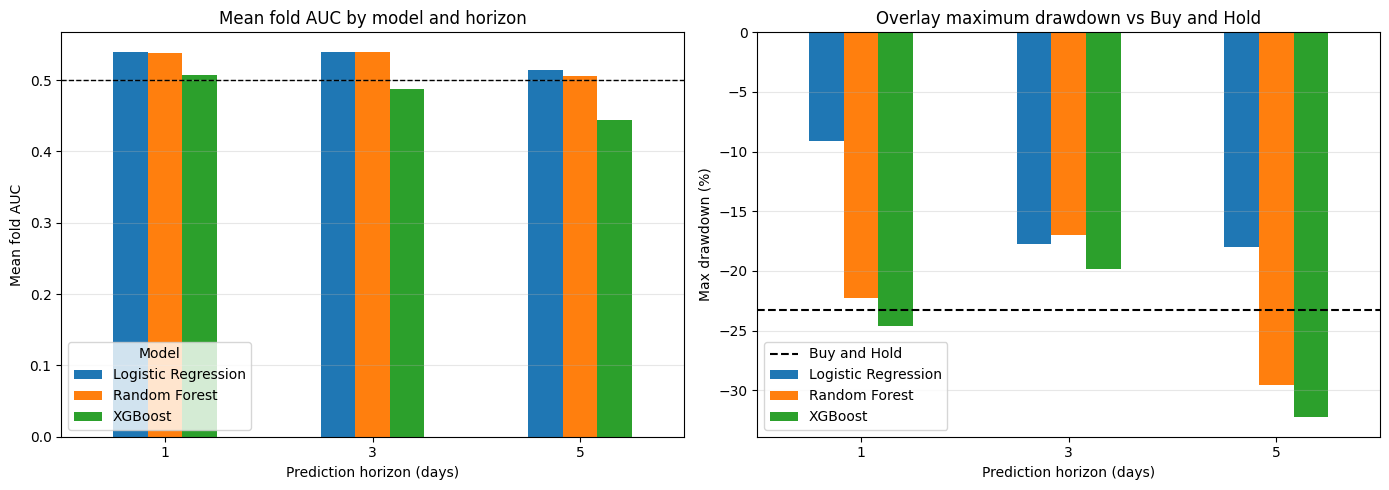

In [90]:
# -----------------------------------------------------------------------------
# CELL G - one chart for the slide
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_auc = run7_predictive.pivot(
    index='Horizon', columns='Model', values='Mean_Fold_AUC'
)
pivot_auc.plot(kind='bar', ax=axes[0], rot=0)
axes[0].axhline(0.50, color='black', linestyle='--', lw=1)
axes[0].set_title('Mean fold AUC by model and horizon')
axes[0].set_ylabel('Mean fold AUC')
axes[0].set_xlabel('Prediction horizon (days)')
axes[0].grid(True, alpha=0.3, axis='y')

overlay_only = run7_trading[run7_trading['Horizon'] != 'n/a'].copy()
pivot_dd = overlay_only.pivot(
    index='Horizon', columns='Model', values='Max Drawdown'
) * 100
pivot_dd.plot(kind='bar', ax=axes[1], rot=0)
axes[1].axhline(
    benchmark_performance['Max Drawdown'] * 100,
    color='black', linestyle='--', lw=1.5,
    label='Buy and Hold'
)
axes[1].set_title('Overlay maximum drawdown vs Buy and Hold')
axes[1].set_ylabel('Max drawdown (%)')
axes[1].set_xlabel('Prediction horizon (days)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [91]:
# -----------------------------------------------------------------------------
# CELL H - export for the report and the dashboard
# -----------------------------------------------------------------------------

run7_predictive.to_csv('run7_predictive_summary.csv', index=False)
run7_trading_display.to_csv('run7_trading_summary.csv', index=False)
run7_cost_table.to_csv('run7_cost_sensitivity.csv')
run7_fold_df.to_csv('run7_fold_results.csv', index=False)

print("Saved:")
print("  run7_predictive_summary.csv")
print("  run7_trading_summary.csv")
print("  run7_cost_sensitivity.csv")
print("  run7_fold_results.csv")

Saved:
  run7_predictive_summary.csv
  run7_trading_summary.csv
  run7_cost_sensitivity.csv
  run7_fold_results.csv


In [92]:
_lr1d = run7_daily_df[
    (run7_daily_df['Model'] == 'Logistic Regression')
    & (run7_daily_df['Horizon'] == 1)
].sort_index()

_pos = positions_with_holding(
    _lr1d['Probability UP'].values,
    _lr1d['Selected Threshold'].values,
    'overlay', 1
)
_ov = apply_positions(_pos, _lr1d['Forward Return'], RUN7_COST_RATE)
_bh = apply_positions(np.ones(len(_lr1d)), _lr1d['Forward Return'], RUN7_COST_RATE)

_fold = pd.DataFrame({
    'Fold': _lr1d['Fold'].values,
    'Overlay': _ov['Net Return'].values,
    'BH': _bh['Net Return'].values
}).groupby('Fold').sum()

_fold['Diff'] = _fold['Overlay'] - _fold['BH']
print(f"Folds where overlay beat B&H: {(_fold['Diff'] > 0).sum()}/36")
print(f"Top 3 folds contribute: {_fold['Diff'].nlargest(3).sum()*100:.2f}% "
      f"of total {_fold['Diff'].sum()*100:.2f}%")
print(_fold['Diff'].nlargest(5).round(4).to_string())

Folds where overlay beat B&H: 20/36
Top 3 folds contribute: 13.96% of total 14.96%
Fold
21    0.0597
23    0.0489
19    0.0310
6     0.0236
7     0.0214


In [93]:
print(
    run7_fold_df[
        (run7_fold_df['Model'] == 'Logistic Regression')
        & (run7_fold_df['Horizon'] == 1)
        & (run7_fold_df['Fold'].isin([19, 21, 23]))
    ][['Fold', 'Test Start', 'Test End', 'AUC']].to_string(index=False)
)

 Fold Test Start   Test End      AUC
   19 2021-09-07 2021-11-29 0.485294
   21 2022-02-22 2022-05-16 0.602820
   23 2022-08-09 2022-10-31 0.521493


In [94]:
# =============================================================================
# NESTED MODEL SELECTION — selection moved inside the walk-forward
# One-day horizon. Reuses the Section 5.9 harness.
# =============================================================================

nested_records = []
nested_daily = []

test_start = RUN7_INITIAL_TEST_START
fold_number = 1

while test_start + RUN7_TEST_WINDOW <= len(df_run7):

    test_end = test_start + RUN7_TEST_WINDOW
    outer_train_end = test_start - RUN7_PURGE_GAP
    outer_train_start = outer_train_end - RUN7_TRAIN_WINDOW
    validation_end = outer_train_end
    validation_start = validation_end - RUN7_VALIDATION_WINDOW
    inner_train_end = validation_start - RUN7_PURGE_GAP

    X_inner = df_run7[run7_features].iloc[outer_train_start:inner_train_end]
    y_inner = df_run7['target_1d'].iloc[outer_train_start:inner_train_end]
    X_val = df_run7[run7_features].iloc[validation_start:validation_end]
    y_val = df_run7['target_1d'].iloc[validation_start:validation_end]
    val_returns = df_run7['forward_return'].iloc[validation_start:validation_end]

    # --- choose the model on validation data only ---------------------------
    val_scores = {}
    val_probs = {}
    for model_name, (model_key, _) in RUN7_MODELS.items():
        p = fit_predict_proba(model_key, X_inner, y_inner, X_val)
        val_probs[model_name] = p
        val_scores[model_name] = roc_auc_score(y_val, p)

    winner = max(val_scores, key=val_scores.get)
    winner_key = RUN7_MODELS[winner][0]

    # threshold selected with the winning model, still validation only
    selected_threshold, _ = select_threshold_with_holding(
        val_probs[winner], val_returns, RUN7_COST_RATE, 1
    )

    # --- refit the winner on the full outer window, predict the test fold ---
    X_outer = df_run7[run7_features].iloc[outer_train_start:outer_train_end]
    y_outer = df_run7['target_1d'].iloc[outer_train_start:outer_train_end]
    X_test_fold = df_run7[run7_features].iloc[test_start:test_end]
    y_test_fold = df_run7['target_1d'].iloc[test_start:test_end]
    test_returns = df_run7['forward_return'].iloc[test_start:test_end]

    test_prob = fit_predict_proba(winner_key, X_outer, y_outer, X_test_fold)

    nested_daily.append(pd.DataFrame({
        'Fold': fold_number,
        'Selected Model': winner,
        'Probability UP': test_prob,
        'Actual Target': y_test_fold.values,
        'Forward Return': test_returns.values,
        'Selected Threshold': selected_threshold,
    }, index=X_test_fold.index))

    nested_records.append({
        'Fold': fold_number,
        'Test Start': X_test_fold.index[0],
        'Test End': X_test_fold.index[-1],
        'Selected Model': winner,
        'Val AUC': val_scores[winner],
        'Test AUC': roc_auc_score(y_test_fold, test_prob),
        'Threshold': selected_threshold,
    })

    test_start += RUN7_STEP
    fold_number += 1

nested_df = pd.DataFrame(nested_records)
nested_daily_df = pd.concat(nested_daily).sort_index()

# --- results -----------------------------------------------------------------
auc = nested_df['Test AUC'].to_numpy(float)
t_stat, p_two = stats.ttest_1samp(auc, 0.50)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

print("Nested selection procedure, 36 folds, one-day horizon")
print(f"  Mean fold AUC:   {auc.mean():.4f}")
print(f"  SD:              {auc.std(ddof=1):.4f}")
print(f"  Above 0.50:      {(auc > 0.50).sum()} / {len(auc)}")
print(f"  Pooled AUC:      "
      f"{roc_auc_score(nested_daily_df['Actual Target'], nested_daily_df['Probability UP']):.4f}")
print(f"  t = {t_stat:.3f}, one-sided p = {p_one:.6f}")

print("\nHow often each model was selected")
counts = nested_df['Selected Model'].value_counts()
for m in RUN7_MODELS:
    print(f"  {m:<22} {counts.get(m, 0):>2} / {len(nested_df)}")

switches = (nested_df['Selected Model'] != nested_df['Selected Model'].shift()).sum() - 1
print(f"\n  Selection changed between consecutive folds: {switches} times")

# --- trading -----------------------------------------------------------------
pos = positions_with_holding(
    nested_daily_df['Probability UP'].values,
    nested_daily_df['Selected Threshold'].values,
    'overlay', 1
)
perf = calculate_performance(
    apply_positions(pos, nested_daily_df['Forward Return'], RUN7_COST_RATE)
)
print(f"\nOverlay with nested selection: {perf['Net Return']*100:+.2f}% net, "
      f"Sharpe {perf['Sharpe']:.3f}, max DD {perf['Max Drawdown']*100:.2f}%")

Nested selection procedure, 36 folds, one-day horizon
  Mean fold AUC:   0.5324
  SD:              0.0557
  Above 0.50:      26 / 36
  Pooled AUC:      0.5201
  t = 3.485, one-sided p = 0.000672

How often each model was selected
  Logistic Regression    19 / 36
  Random Forest          11 / 36
  XGBoost                 6 / 36

  Selection changed between consecutive folds: 16 times

Overlay with nested selection: +15.20% net, Sharpe 0.327, max DD -14.05%


In [95]:
deploy_val_end = len(df_run7)
deploy_val_start = deploy_val_end - RUN7_VALIDATION_WINDOW
deploy_inner_end = deploy_val_start - RUN7_PURGE_GAP
deploy_inner_start = deploy_inner_end - RUN7_TRAIN_WINDOW

Xi = df_run7[run7_features].iloc[deploy_inner_start:deploy_inner_end]
yi = df_run7['target_1d'].iloc[deploy_inner_start:deploy_inner_end]
Xv = df_run7[run7_features].iloc[deploy_val_start:deploy_val_end]
yv = df_run7['target_1d'].iloc[deploy_val_start:deploy_val_end]

for name, (key, _) in RUN7_MODELS.items():
    print(f"{name:<22} {roc_auc_score(yv, fit_predict_proba(key, Xi, yi, Xv)):.4f}")

Logistic Regression    0.5677
Random Forest          0.5709
XGBoost                0.5140


In [96]:
# =============================================================================
# NESTED SELECTION — FORMATTED RESULTS
# =============================================================================

auc = nested_df['Test AUC'].to_numpy(float)
t_stat, p_two = stats.ttest_1samp(auc, 0.50)
p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

pooled = roc_auc_score(
    nested_daily_df['Actual Target'], nested_daily_df['Probability UP']
)

print("=" * 78)
print("TABLE 18 — NESTED SELECTION vs FIXED MODEL CHOICES")
print("36 folds, one-day horizon, 2,160 out-of-sample days")
print("=" * 78)

comparison = pd.DataFrame([
    {'Configuration': 'Fixed Logistic Regression', 'Mean AUC': 0.5399,
     'SD': 0.0600, 'Above 0.50': '25 / 36', 'Pooled AUC': 0.5281},
    {'Configuration': 'Fixed Random Forest',       'Mean AUC': 0.5386,
     'SD': 0.0641, 'Above 0.50': '26 / 36', 'Pooled AUC': 0.5136},
    {'Configuration': 'Fixed XGBoost',             'Mean AUC': 0.5075,
     'SD': 0.0754, 'Above 0.50': '20 / 36', 'Pooled AUC': 0.5036},
    {'Configuration': 'NESTED SELECTION',          'Mean AUC': round(auc.mean(), 4),
     'SD': round(auc.std(ddof=1), 4),
     'Above 0.50': f"{(auc > 0.50).sum()} / {len(auc)}",
     'Pooled AUC': round(pooled, 4)},
])
print(comparison.to_string(index=False))

print(f"\n  Significance:  t = {t_stat:.3f}, one-sided p = {p_one:.6f}")
print( "                 No Bonferroni adjustment needed: no configuration was")
print( "                 examined before this number was produced.")
print(f"\n  Cost of removing hindsight:  {0.5399 - auc.mean():.4f} AUC")
print(f"  Fold-to-fold SD vs best fixed: {auc.std(ddof=1):.4f} vs 0.0600 "
      f"({'LOWER — more stable' if auc.std(ddof=1) < 0.0600 else 'higher'})")

# ---------------------------------------------------------------------------
print("\n" + "=" * 78)
print("TABLE 19 — WHICH MODEL THE PROCEDURE SELECTED")
print("=" * 78)

fixed_means = {'Logistic Regression': 0.5399,
               'Random Forest': 0.5386,
               'XGBoost': 0.5075}

counts = nested_df['Selected Model'].value_counts()
sel = pd.DataFrame([
    {'Model family': m,
     'Folds selected': f"{counts.get(m, 0)} / {len(nested_df)}",
     'Share': f"{counts.get(m, 0) / len(nested_df) * 100:.1f}%",
     'Fixed mean AUC': fixed_means[m],
     'Mean AUC when selected': round(
         nested_df.loc[nested_df['Selected Model'] == m, 'Test AUC'].mean(), 4
     ) if counts.get(m, 0) else float('nan')}
    for m in RUN7_MODELS
])
print(sel.to_string(index=False))

switches = (nested_df['Selected Model'] != nested_df['Selected Model'].shift()).sum() - 1
print(f"\n  Selection changed on {switches} of {len(nested_df) - 1} transitions "
      f"({switches / (len(nested_df) - 1) * 100:.0f}%)")
print( "  No family holds the selection for a sustained run, which measures the")
print( "  indistinguishability of the three families rather than asserting it.")

# ---------------------------------------------------------------------------
print("\n" + "=" * 78)
print("FOLD-BY-FOLD SELECTION")
print("=" * 78)

trail = nested_df[['Fold', 'Test Start', 'Test End',
                   'Selected Model', 'Test AUC', 'Threshold']].copy()
trail['Test Start'] = trail['Test Start'].dt.strftime('%Y-%m-%d')
trail['Test End']   = trail['Test End'].dt.strftime('%Y-%m-%d')
trail['Test AUC']   = trail['Test AUC'].round(4)
trail['Beat 0.50']  = np.where(trail['Test AUC'] > 0.50, 'yes', '')
print(trail.to_string(index=False))

# ---------------------------------------------------------------------------
print("\n" + "=" * 78)
print("TRADING WITH NESTED SELECTION (1bp cost)")
print("=" * 78)

pos = positions_with_holding(
    nested_daily_df['Probability UP'].values,
    nested_daily_df['Selected Threshold'].values,
    'overlay', 1
)
perf = calculate_performance(
    apply_positions(pos, nested_daily_df['Forward Return'], RUN7_COST_RATE)
)
bh = calculate_performance(
    apply_positions(np.ones(len(nested_daily_df)),
                    nested_daily_df['Forward Return'], RUN7_COST_RATE)
)

trade = pd.DataFrame([
    {'Strategy': 'Buy and Hold',
     'Net Return': f"{bh['Net Return']*100:+.2f}%",
     'Sharpe': round(bh['Sharpe'], 3),
     'Max Drawdown': f"{bh['Max Drawdown']*100:.2f}%",
     'Trades': bh['Trades'],
     'Cash': f"{bh['Cash Exposure']*100:.2f}%"},
    {'Strategy': 'B&H + nested selection overlay',
     'Net Return': f"{perf['Net Return']*100:+.2f}%",
     'Sharpe': round(perf['Sharpe'], 3),
     'Max Drawdown': f"{perf['Max Drawdown']*100:.2f}%",
     'Trades': perf['Trades'],
     'Cash': f"{perf['Cash Exposure']*100:.2f}%"},
])
print(trade.to_string(index=False))
print("\n  The concentration caveat from the fixed-model analysis still applies:")
print("  an overlay profits during a sustained decline for structural reasons,")
print("  regardless of which family generated the probabilities.")

TABLE 18 — NESTED SELECTION vs FIXED MODEL CHOICES
36 folds, one-day horizon, 2,160 out-of-sample days
            Configuration  Mean AUC     SD Above 0.50  Pooled AUC
Fixed Logistic Regression    0.5399 0.0600    25 / 36      0.5281
      Fixed Random Forest    0.5386 0.0641    26 / 36      0.5136
            Fixed XGBoost    0.5075 0.0754    20 / 36      0.5036
         NESTED SELECTION    0.5324 0.0557    26 / 36      0.5201

  Significance:  t = 3.485, one-sided p = 0.000672
                 No Bonferroni adjustment needed: no configuration was
                 examined before this number was produced.

  Cost of removing hindsight:  0.0075 AUC
  Fold-to-fold SD vs best fixed: 0.0557 vs 0.0600 (LOWER — more stable)

TABLE 19 — WHICH MODEL THE PROCEDURE SELECTED
       Model family Folds selected Share  Fixed mean AUC  Mean AUC when selected
Logistic Regression        19 / 36 52.8%          0.5399                  0.5302
      Random Forest        11 / 36 30.6%          0.5386     

In [97]:
# =============================================================================
# DEPLOYMENT — apply the same selection rule to the most recent window
# =============================================================================

deploy_val_end    = len(df_run7)
deploy_val_start  = deploy_val_end - RUN7_VALIDATION_WINDOW
deploy_inner_end  = deploy_val_start - RUN7_PURGE_GAP
deploy_inner_start = deploy_inner_end - RUN7_TRAIN_WINDOW

Xi = df_run7[run7_features].iloc[deploy_inner_start:deploy_inner_end]
yi = df_run7['target_1d'].iloc[deploy_inner_start:deploy_inner_end]
Xv = df_run7[run7_features].iloc[deploy_val_start:deploy_val_end]
yv = df_run7['target_1d'].iloc[deploy_val_start:deploy_val_end]

print("=" * 78)
print("DEPLOYMENT MODEL SELECTION")
print("=" * 78)
print(f"  Inner training:  {df_run7.index[deploy_inner_start].date()} to "
      f"{df_run7.index[deploy_inner_end - 1].date()}  ({len(Xi)} rows)")
print(f"  Validation:      {df_run7.index[deploy_val_start].date()} to "
      f"{df_run7.index[deploy_val_end - 1].date()}  ({len(Xv)} rows)")
print()

scores = {name: roc_auc_score(yv, fit_predict_proba(key, Xi, yi, Xv))
          for name, (key, _) in RUN7_MODELS.items()}

ranked = pd.DataFrame(
    [{'Model': m, 'Validation AUC': round(s, 4)} for m, s in scores.items()]
).sort_values('Validation AUC', ascending=False).reset_index(drop=True)
ranked.insert(0, 'Rank', ranked.index + 1)
print(ranked.to_string(index=False))

winner = ranked.iloc[0]['Model']
margin = ranked.iloc[0]['Validation AUC'] - ranked.iloc[1]['Validation AUC']

print(f"\n  SELECTED FOR DEPLOYMENT:  {winner}")
print(f"  Margin over second place: {margin:.4f}")
print( "\n  These are validation AUCs and are optimistically biased by construction,")
print( "  since selection happens on them. The out-of-sample figure for the")
print(f"  procedure is {auc.mean():.4f} from Table 18. Do not quote the validation")
print( "  numbers as performance.")

DEPLOYMENT MODEL SELECTION
  Inner training:  2015-04-23 to 2024-12-23  (2520 rows)
  Validation:      2024-12-31 to 2025-12-22  (252 rows)

 Rank               Model  Validation AUC
    1       Random Forest          0.5709
    2 Logistic Regression          0.5677
    3             XGBoost          0.5140

  SELECTED FOR DEPLOYMENT:  Random Forest
  Margin over second place: 0.0032

  These are validation AUCs and are optimistically biased by construction,
  since selection happens on them. The out-of-sample figure for the
  procedure is 0.5324 from Table 18. Do not quote the validation
  numbers as performance.


## 8. Feature Importance and Interpretability

Permutation importance shuffles one feature at a time and measures the AUC drop. SHAP
decomposes individual predictions into per-feature contributions.

Both describe what the model *uses*, not what *causes* EUR/USD to move. Given the weak
signal, only the top few features are meaningful; ordering further down is noise.

**On the feature-family question:** the top six features here are technical, led by
`price_pct_14d`, with `days_since_event` the strongest event feature. The defensible claim
is not that either family dominates, but the Section 5a result: neither is sufficient alone,
and the hybrid beats both with paired significance.

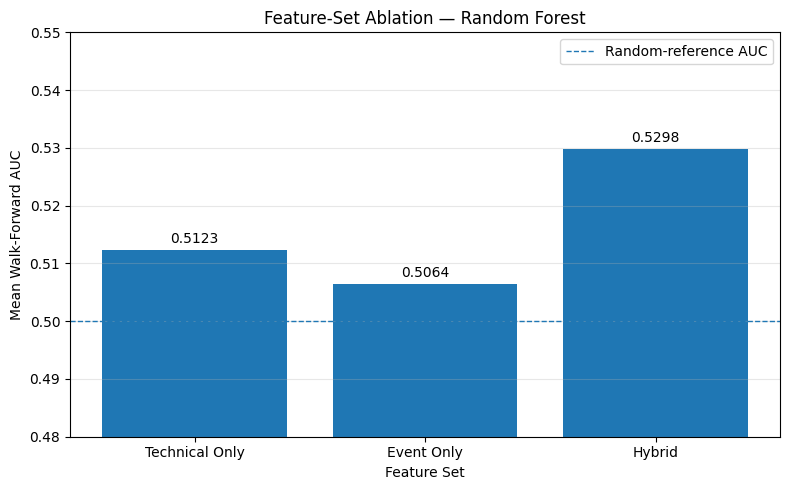

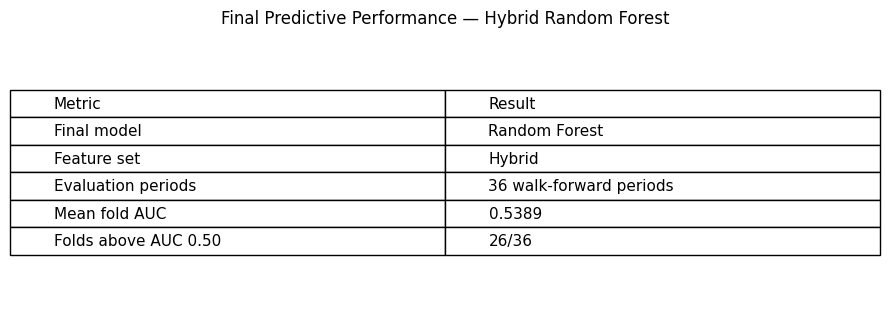

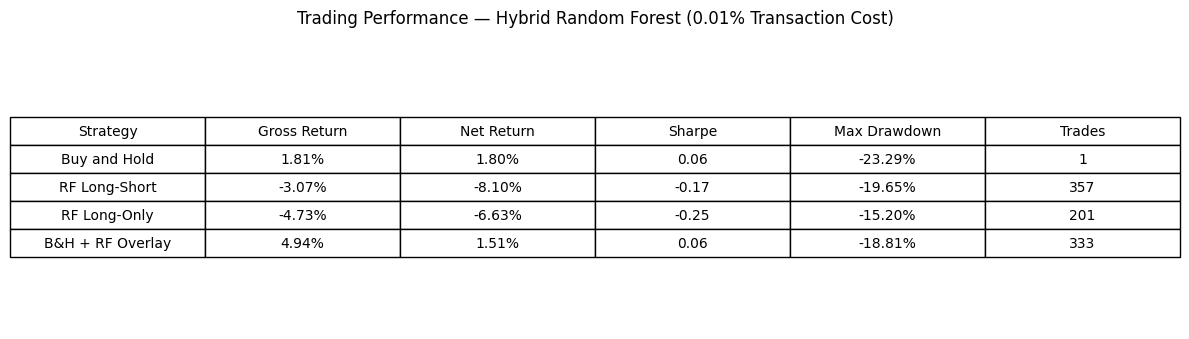

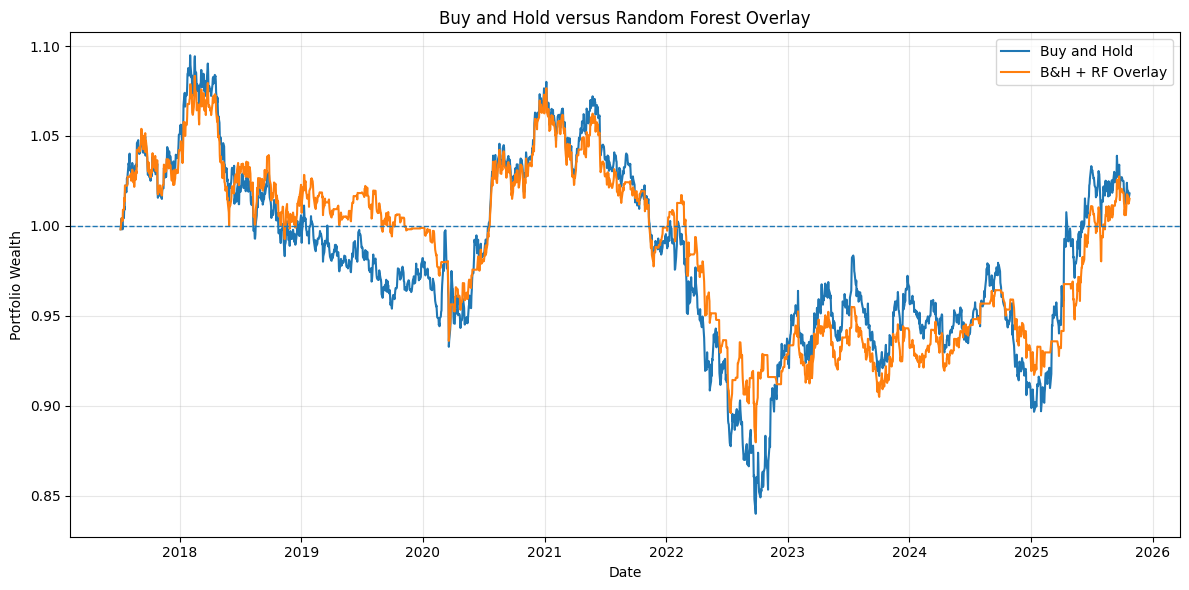

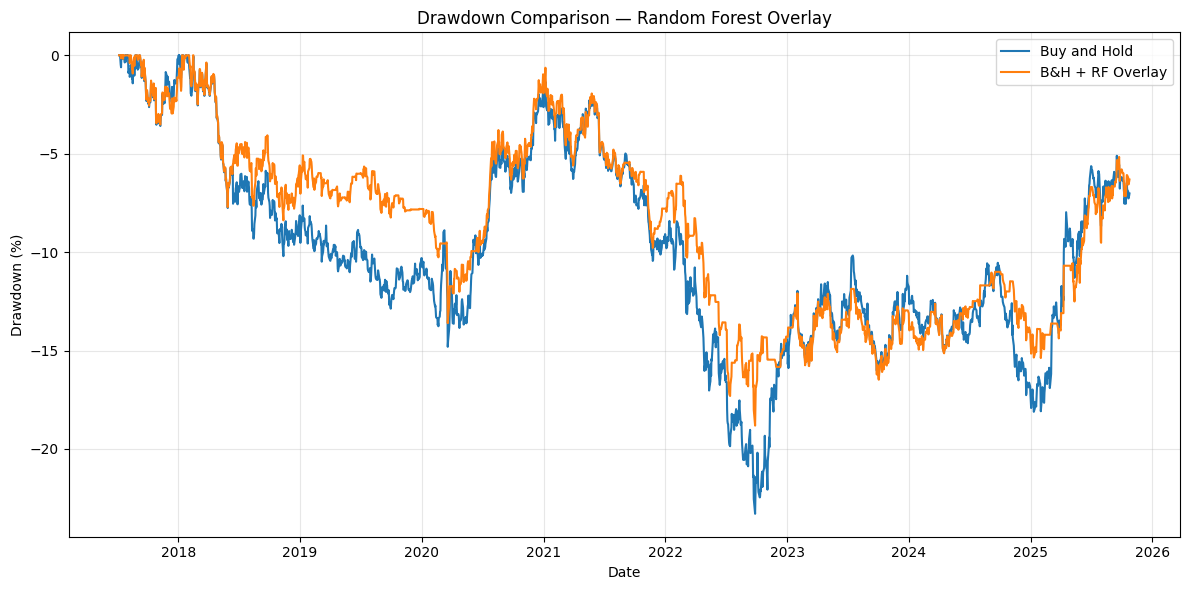


Dashboard images created:
 - dashboard_assets\drawdown_rf_overlay.png
 - dashboard_assets\equity_curve_rf_overlay.png
 - dashboard_assets\feature_set_ablation_rf.png
 - dashboard_assets\final_predictive_summary.png
 - dashboard_assets\trading_results_rf.png


In [98]:
# ================================================================
# FINAL DASHBOARD IMAGE EXPORTS
# Creates clean images using the final Hybrid Random Forest results
# ================================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dashboard_folder = Path("dashboard_assets")
dashboard_folder.mkdir(exist_ok=True)

strategy_names = {
    "Buy and Hold": "Buy and Hold",
    "ML Long-Short": "RF Long-Short",
    "ML Long-Only": "RF Long-Only",
    "B&H + ML Overlay": "B&H + RF Overlay"
}


# ------------------------------------------------
# 1. Feature-set ablation: Random Forest only
# ------------------------------------------------

rf_ablation = (
    run3_wf_pivot["Random Forest"]
    .reindex([
        "Technical Only",
        "Event Only",
        "Hybrid"
    ])
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    rf_ablation.index,
    rf_ablation.values
)

ax.axhline(
    0.50,
    linestyle="--",
    linewidth=1,
    label="Random-reference AUC"
)

ax.bar_label(
    bars,
    fmt="%.4f",
    padding=3
)

ax.set_title(
    "Feature-Set Ablation — Random Forest"
)

ax.set_xlabel("Feature Set")
ax.set_ylabel("Mean Walk-Forward AUC")
ax.set_ylim(0.48, 0.55)
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(
    dashboard_folder / "feature_set_ablation_rf.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------
# 2. Final predictive-performance summary
# ------------------------------------------------

mean_fold_auc = run6_fold_df["Test AUC"].mean()

folds_above_050 = int(
    (run6_fold_df["Test AUC"] > 0.50).sum()
)

predictive_summary = pd.DataFrame({
    "Metric": [
        "Final model",
        "Feature set",
        "Evaluation periods",
        "Mean fold AUC",
        "Folds above AUC 0.50"
    ],
    "Result": [
        "Random Forest",
        "Hybrid",
        f"{len(run6_fold_df)} walk-forward periods",
        f"{mean_fold_auc:.4f}",
        f"{folds_above_050}/{len(run6_fold_df)}"
    ]
})

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")

table = ax.table(
    cellText=predictive_summary.values,
    colLabels=predictive_summary.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)

ax.set_title(
    "Final Predictive Performance — Hybrid Random Forest",
    pad=16
)

fig.tight_layout()
fig.savefig(
    dashboard_folder / "final_predictive_summary.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------
# 3. Final trading-results table
# ------------------------------------------------

trading_summary = run6_strategy_summary[
    [
        "Strategy",
        "Gross Return",
        "Net Return",
        "Sharpe",
        "Max Drawdown",
        "Trades"
    ]
].copy()

trading_summary["Strategy"] = (
    trading_summary["Strategy"]
    .replace(strategy_names)
)

for column in [
    "Gross Return",
    "Net Return",
    "Max Drawdown"
]:
    trading_summary[column] = (
        trading_summary[column] * 100
    ).map(lambda value: f"{value:.2f}%")

trading_summary["Sharpe"] = (
    trading_summary["Sharpe"]
    .map(lambda value: f"{value:.2f}")
)

trading_summary["Trades"] = (
    trading_summary["Trades"]
    .astype(int)
)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

table = ax.table(
    cellText=trading_summary.values,
    colLabels=trading_summary.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

ax.set_title(
    "Trading Performance — Hybrid Random Forest "
    "(0.01% Transaction Cost)",
    pad=16
)

fig.tight_layout()
fig.savefig(
    dashboard_folder / "trading_results_rf.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------
# 4. Buy and Hold versus RF overlay equity curve
# ------------------------------------------------

comparison_strategies = [
    "Buy and Hold",
    "B&H + ML Overlay"
]

fig, ax = plt.subplots(figsize=(12, 6))

for strategy in comparison_strategies:

    strategy_frame = run6_strategy_frames[strategy]

    ax.plot(
        strategy_frame.index,
        strategy_frame["Wealth"],
        linewidth=1.5,
        label=strategy_names[strategy]
    )

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Buy and Hold versus Random Forest Overlay"
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Wealth")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    dashboard_folder / "equity_curve_rf_overlay.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------
# 5. Buy and Hold versus RF overlay drawdown
# ------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

for strategy in comparison_strategies:

    strategy_frame = run6_strategy_frames[strategy]

    ax.plot(
        strategy_frame.index,
        strategy_frame["Drawdown"] * 100,
        linewidth=1.5,
        label=strategy_names[strategy]
    )

ax.set_title(
    "Drawdown Comparison — Random Forest Overlay"
)

ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    dashboard_folder / "drawdown_rf_overlay.png",
    dpi=250,
    bbox_inches="tight"
)
plt.show()


print("\nDashboard images created:")

for image_file in sorted(dashboard_folder.glob("*.png")):
    print(f" - {image_file}")

Top 15 features by permutation importance (Random Forest):
         feature  importance_mean  importance_std
             r5d           0.0394          0.0209
             r7d           0.0390          0.0227
   price_pct_14d           0.0281          0.0249
            mom5           0.0132          0.0096
             r1d           0.0113          0.0310
         sin_dow           0.0095          0.0102
         vol_14d           0.0095          0.0048
          bb_pct           0.0091          0.0117
         cpi_day           0.0087          0.0080
            mom7           0.0084          0.0083
          vol_5d           0.0081          0.0086
days_since_event           0.0071          0.0059
  post_event_vol           0.0056          0.0092
       macd_hist           0.0051          0.0086
            r14d           0.0044          0.0020


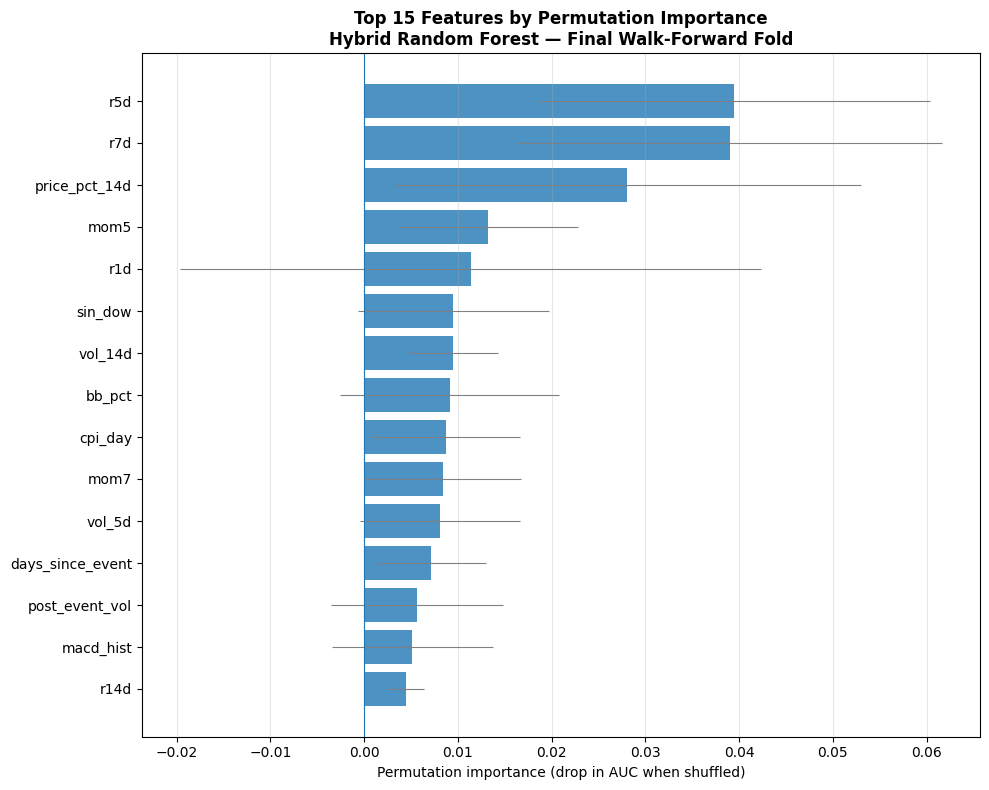

In [99]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# final_model, X_test_fold and y_test_fold remain from
# the final Run 6 walk-forward fold
perm_rf = permutation_importance(
    final_model,
    X_test_fold,
    y_test_fold,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_rf_df = pd.DataFrame({
    "feature": run6_features,
    "importance_mean": perm_rf.importances_mean,
    "importance_std": perm_rf.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

print("Top 15 features by permutation importance (Random Forest):")
print(
    perm_rf_df.head(15)
    .round(4)
    .to_string(index=False)
)

top_rf = perm_rf_df.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_rf["feature"],
    top_rf["importance_mean"],
    xerr=top_rf["importance_std"],
    alpha=0.8,
    error_kw={
        "ecolor": "gray",
        "lw": 0.8
    }
)

ax.axvline(
    0,
    linewidth=0.8
)

ax.set_xlabel(
    "Permutation importance "
    "(drop in AUC when shuffled)"
)

ax.set_title(
    "Top 15 Features by Permutation Importance\n"
    "Hybrid Random Forest — Final Walk-Forward Fold",
    fontweight="bold"
)

ax.grid(
    True,
    alpha=0.3,
    axis="x"
)

plt.tight_layout()

plt.savefig(
    "permutation_importance_rf.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [100]:
import numpy as np
import shap

# TreeExplainer is suitable for Random Forest
rf_explainer = shap.TreeExplainer(final_model)

raw_shap_values_rf = rf_explainer.shap_values(
    X_test_fold
)

# Handle different SHAP library output formats
if isinstance(raw_shap_values_rf, list):
    # Older SHAP versions:
    # index 1 represents the positive class, EUR/USD UP
    shap_values_rf = raw_shap_values_rf[1]

elif (
    isinstance(raw_shap_values_rf, np.ndarray)
    and raw_shap_values_rf.ndim == 3
):
    if raw_shap_values_rf.shape[-1] == 2:
        # Shape: samples, features, classes
        shap_values_rf = raw_shap_values_rf[:, :, 1]

    elif raw_shap_values_rf.shape[0] == 2:
        # Shape: classes, samples, features
        shap_values_rf = raw_shap_values_rf[1]

    else:
        raise ValueError(
            "Unexpected three-dimensional SHAP output: "
            f"{raw_shap_values_rf.shape}"
        )

else:
    shap_values_rf = raw_shap_values_rf

print("SHAP values shape:", shap_values_rf.shape)
print("Test data shape:", X_test_fold.shape)

SHAP values shape: (60, 48)
Test data shape: (60, 48)


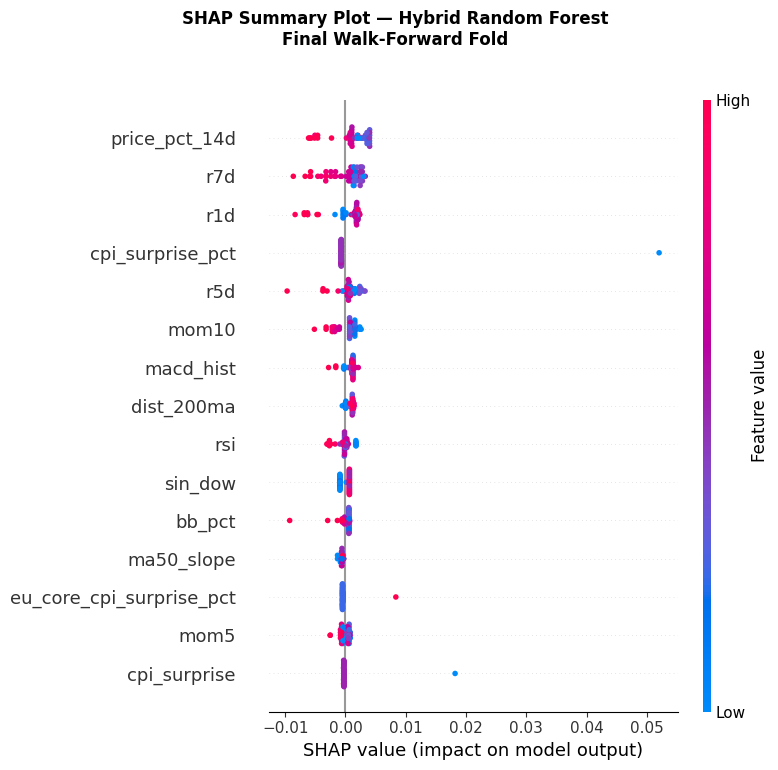

In [101]:
import matplotlib.pyplot as plt
import shap

shap.summary_plot(
    shap_values_rf,
    X_test_fold,
    feature_names=run6_features,
    show=False,
    max_display=15
)

fig = plt.gcf()

fig.suptitle(
    "SHAP Summary Plot — Hybrid Random Forest\n"
    "Final Walk-Forward Fold",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "shap_summary_rf.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

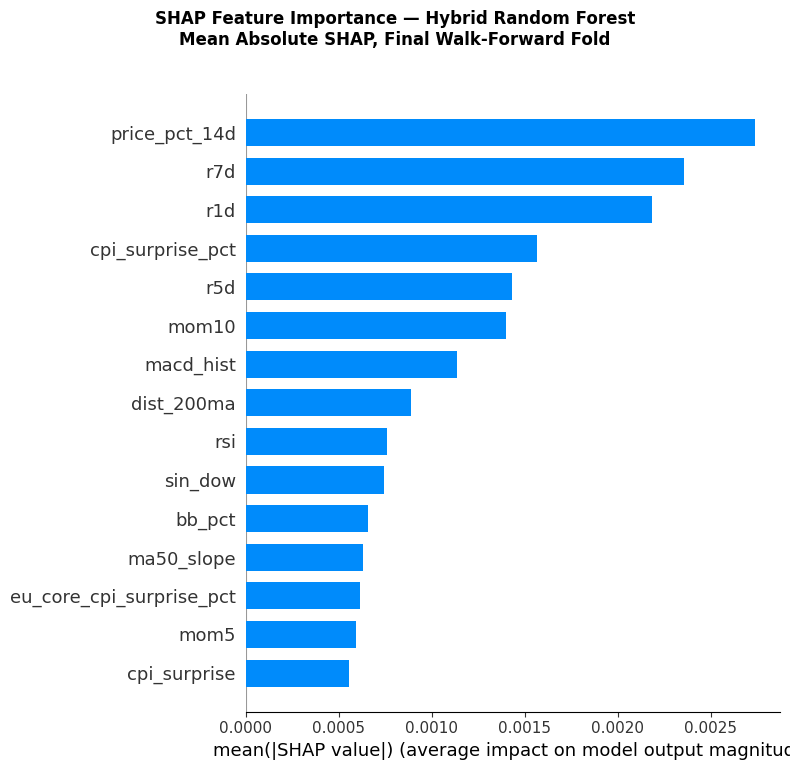

In [102]:
import matplotlib.pyplot as plt
import shap

shap.summary_plot(
    shap_values_rf,
    X_test_fold,
    feature_names=run6_features,
    plot_type="bar",
    show=False,
    max_display=15
)

fig = plt.gcf()

fig.suptitle(
    "SHAP Feature Importance — Hybrid Random Forest\n"
    "Mean Absolute SHAP, Final Walk-Forward Fold",
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "shap_bar_rf.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

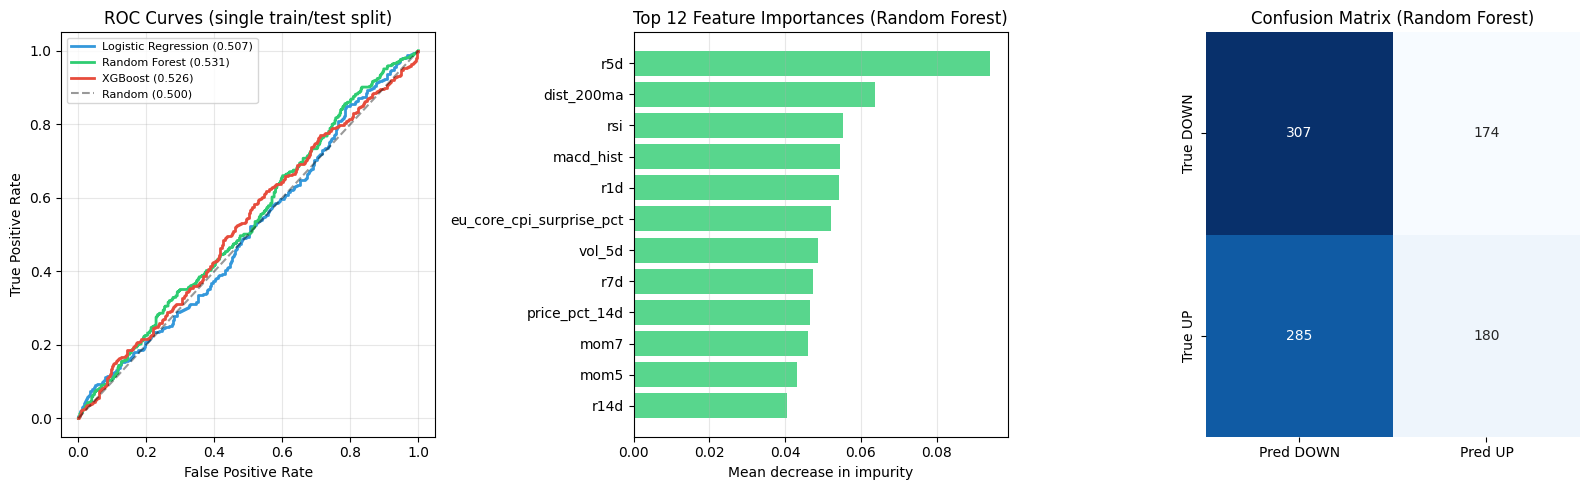

Saved evaluation_diagnostics.png for Random Forest


In [105]:
# =============================================================================
# Regenerate evaluation_diagnostics.png for the deployed model (Random Forest)
# Standalone: uses only local names, changes no existing state.
# =============================================================================
from sklearn.metrics import roc_curve, confusion_matrix

_plot_model = 'Random Forest'
_clf = results[_plot_model]['clf']

_fig, _axes = plt.subplots(1, 3, figsize=(16, 5))
_colours = {'Logistic Regression': '#3498db',
            'Random Forest': '#2ecc71',
            'XGBoost': '#e74c3c'}

# ROC curves, all three models
_ax = _axes[0]
for _name, _res in results.items():
    _fpr, _tpr, _ = roc_curve(y_test, _res['proba'])
    _ax.plot(_fpr, _tpr, lw=2, color=_colours[_name],
             label=f"{_name} ({_res['auc']:.3f})")
_ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (0.500)')
_ax.set_xlabel('False Positive Rate'); _ax.set_ylabel('True Positive Rate')
_ax.set_title('ROC Curves (single train/test split)')
_ax.legend(fontsize=8); _ax.grid(True, alpha=0.3)

# Feature importances for the deployed model
_ax = _axes[1]
_imp = pd.Series(_clf.feature_importances_,
                 index=feature_cols).sort_values(ascending=True).tail(12)
_ax.barh(_imp.index, _imp.values, color='#2ecc71', alpha=0.8)
_ax.set_title(f'Top 12 Feature Importances ({_plot_model})')
_ax.set_xlabel('Mean decrease in impurity')
_ax.grid(True, alpha=0.3, axis='x')

# Confusion matrix for the deployed model
_ax = _axes[2]
_cm = confusion_matrix(y_test, results[_plot_model]['pred'])
sns.heatmap(_cm, annot=True, fmt='d', cmap='Blues', ax=_ax,
            xticklabels=['Pred DOWN', 'Pred UP'],
            yticklabels=['True DOWN', 'True UP'], cbar=False)
_ax.set_title(f'Confusion Matrix ({_plot_model})')

plt.tight_layout()
plt.savefig('evaluation_diagnostics.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved evaluation_diagnostics.png for {_plot_model}")

## 9. Deployment Export

Trains the deployment model on the most recent 10-year window, using the same
hyperparameters and window length as the Run 6 folds, and writes the dashboard artefacts.

This is **not** the Section 4 single-split model.

In [106]:
# ============================================================================
# Run 6 export — paste as ONE new cell at the very END of the run6 notebook
# (after cell 130). Run it after a clean restart-and-run-all.
#
# Produces:
#   fyp_model.pkl        the Run 6 Random Forest, 48 features, scaler=None
#   results_summary.json Run 6 numbers for the dashboard
#   run6_clean_fold_table.csv  the tuning-contamination robustness table
#
# IMPORTANT: delete cell 62, or change its filename to
# 'results_summary_run2.json'. If both cells write the same file, cell 62
# runs last in a fresh run-all and silently restores the Run 2 numbers.
# ============================================================================

import json
import pickle
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier

# --- 1. Train the deployment model on the FINAL 10-year window --------------
# This mirrors Run 6's last fold: same hyperparameters, same window length.
# It is NOT rf_t (that was tuned on the 80/20 split over a different period).

deploy_end = len(df_run6) - 1                      # last row with a valid target
deploy_start = deploy_end - RUN6_TRAIN_WINDOW

assert deploy_start >= 0, "Not enough history for a 10-year deployment window"

X_deploy = df_run6[run6_features].iloc[deploy_start:deploy_end]
y_deploy = df_run6['target'].iloc[deploy_start:deploy_end]

assert not X_deploy.isna().any().any(), "NaNs in deployment features"
assert len(run6_features) == 48, f"Expected 48 features, got {len(run6_features)}"

deploy_model = RandomForestClassifier(
    **RUN2_RF_PARAMS,
    random_state=42,
    n_jobs=-1
)
deploy_model.fit(X_deploy, y_deploy)

with open('fyp_model.pkl', 'wb') as f:
    pickle.dump({
        'model': deploy_model,
        'scaler': None,                 # RF needs no scaling
        'feature_cols': run6_features,
        'model_name': 'Random Forest'
    }, f)

print("Deployment model")
print(f"  Trained on rows {deploy_start} to {deploy_end} "
      f"({df_run6.index[deploy_start].date()} to {df_run6.index[deploy_end - 1].date()})")
print(f"  Rows: {len(X_deploy)}   Features: {len(run6_features)}")
print(f"  Params: {RUN2_RF_PARAMS}")

# Sanity: probabilities must actually vary, or the dashboard shows HOLD forever
probe = deploy_model.predict_proba(X_deploy.tail(250))[:, 1]
print(f"  Probability range over last 250 days: "
      f"{probe.min():.4f} to {probe.max():.4f} (mean {probe.mean():.4f})")

# --- 2. Clean-fold robustness table ----------------------------------------
# Run 2's grid search trained on rows 0 to 3781 (to 2022-05-10).
# Folds 1-21 fall inside that window; folds 22-36 do not.

TUNING_CUTOFF_FOLD = 21


def _fold_stats(values, label, period):
    values = np.asarray(values, dtype=float)
    t_stat, p_two = stats.ttest_1samp(values, popmean=0.50)
    p_one = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)
    return {
        'Folds': label,
        'Period': period,
        'n': len(values),
        'Mean AUC': round(float(values.mean()), 4),
        'Above 0.50': f"{int((values > 0.50).sum())}/{len(values)}",
        'One-sided p': round(float(p_one), 4),
    }


fold_auc = run6_fold_df['Test AUC'].to_numpy(dtype=float)

clean_fold_table = pd.DataFrame([
    _fold_stats(fold_auc[:TUNING_CUTOFF_FOLD],
                f"1-{TUNING_CUTOFF_FOLD} (inside tuning window)",
                "2017-07 to 2022-05"),
    _fold_stats(fold_auc[TUNING_CUTOFF_FOLD:],
                f"{TUNING_CUTOFF_FOLD + 1}-{len(fold_auc)} (clean)",
                "2022-06 to 2025-10"),
    _fold_stats(fold_auc, "All", "2017-07 to 2025-10"),
])

clean_fold_table.to_csv('run6_clean_fold_table.csv', index=False)

print("\nTuning-contamination check")
print(clean_fold_table.to_string(index=False))

# --- 3. results_summary.json ------------------------------------------------


def _strategy_value(name, column):
    row = run6_display_summary.loc[
        run6_display_summary['Strategy'] == name
    ].iloc[0]
    return float(row[column])


strategy_records = []
for _, row in run6_display_summary.iterrows():
    strategy_records.append({
        'Strategy': row['Strategy'],
        'Gross Return': round(float(row['Gross Return']), 2),
        'Net Return': round(float(row['Net Return']), 2),
        'Sharpe': round(float(row['Sharpe']), 4),
        'Max Drawdown': round(float(row['Max Drawdown']), 2),
        'Position Changes': int(row['Trades']),
    })

cost_table = (run6_cost_return_pivot * 100).round(2)
cost_sensitivity = {
    f"{int(bps)}bp": {
        strategy: float(cost_table.loc[strategy, bps])
        for strategy in cost_table.index
    }
    for bps in cost_table.columns
}

results_summary = {
    'run6': {
        'model': 'Random Forest',
        'params': ', '.join(f"{k}={v}" for k, v in RUN2_RF_PARAMS.items()),
        'n_features': len(run6_features),
        'train_window': int(RUN6_TRAIN_WINDOW),
        'n_folds': int(len(run6_fold_df)),
        'test_window': int(RUN6_TEST_WINDOW),
        'purge_gap': int(RUN6_PURGE_GAP),
        'cost_bps': int(RUN6_COST_BPS),
        'oos_days': int(len(run6_daily_df)),
        'mean_fold_auc': round(float(run6_mean_fold_auc), 4),
        'std_fold_auc': round(float(run6_std_fold_auc), 4),
        'folds_above_050': int(run6_folds_above_050),
        'folds_above_055': int(run6_folds_above_055),
        'pooled_auc': round(float(run6_combined_auc), 4),
        't_stat': round(float(t_statistic), 3),
        'p_one_sided': round(float(p_one_sided), 6),
        'p_bonferroni': round(float(p_bonferroni), 6),
        'clean_folds': clean_fold_table.to_dict(orient='records'),
        'strategies': strategy_records,
        'cost_sensitivity': cost_sensitivity,
    },
}

with open('results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\nWrote results_summary.json")
print(json.dumps(results_summary['run6'], indent=2)[:600])


Deployment model
  Trained on rows 2206 to 4726 (2016-04-22 to 2025-12-29)
  Rows: 2520   Features: 48
  Params: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}
  Probability range over last 250 days: 0.4170 to 0.5590 (mean 0.4856)

Tuning-contamination check
                      Folds             Period  n  Mean AUC Above 0.50  One-sided p
1-21 (inside tuning window) 2017-07 to 2022-05 21    0.5343      13/21       0.0238
              22-36 (clean) 2022-06 to 2025-10 15    0.5452      13/15       0.0004
                        All 2017-07 to 2025-10 36    0.5389      26/36       0.0003

Wrote results_summary.json
{
  "model": "Random Forest",
  "params": "max_depth=2, max_features=sqrt, min_samples_leaf=5, n_estimators=100",
  "n_features": 48,
  "train_window": 2520,
  "n_folds": 36,
  "test_window": 60,
  "purge_gap": 1,
  "cost_bps": 1,
  "oos_days": 2160,
  "mean_fold_auc": 0.5389,
  "std_fold_auc": 0.0621,
  "folds_above_050": 26,
  "folds_a

## 10. Summary and Limitations

### Result

| Metric | Value |
|---|---|
| Mean fold AUC | 0.5389 (std 0.0621) |
| Folds above 0.50 | 26/36 |
| Folds above 0.55 | 14/36 |
| Pooled out-of-sample AUC | 0.5145 |
| Significance vs 0.50 | t = 3.754, one-sided p = 0.000316 |
| Bonferroni (30 configurations) | p = 0.0095 |
| Best strategy net of 1bp | Buy and Hold +1.80%; overlay +1.51% |

The edge is real and small. It does not survive transaction costs. The system is presented
as a decision-support and risk-filtering tool, not an autonomous trading strategy.

### Why the ceiling is where it is

Not "insufficient data". Two binding constraints:

1. **Horizon mismatch.** The surprise lands at 08:30 ET and is absorbed within minutes,
   while the target is the *next* day's close. Andersen, Bollerslev, Diebold and Vega (2003)
   find macro announcement effects are measurable in 5-minute FX windows.
2. **Measurement.** Actual-minus-consensus is a weak policy-surprise proxy. FOMC surprise is
   97% zeros; the literature uses fed funds futures (Kuttner 2001; Nakamura & Steinsson 2018).

This replicates Meese and Rogoff (1983): exchange-rate models fail to beat a random walk out
of sample at short horizons.

### Limitations

1. **Fold independence.** The fold-level t-test assumes independent folds. Test periods do
   not overlap, but consecutive 10-year training windows share roughly 97.6% of their rows.
   A block permutation test would be more defensible. Results are labelled exploratory.
2. **Threshold selection.** The threshold is optimised for the overlay strategy's validation
   Sharpe, then reused for long-short and long-only. It should be per strategy.
3. **Data quality.** `clean_numbers()` strips K and M suffixes without rescaling. Likely
   inert, since surprises become percentile ranks and trees are invariant to monotonic
   transforms, but unverified. Two of 228 US CPI releases for 2025 are missing.
4. **Unscheduled events.** `days_until_event` uses `bfill` over realised events, so
   unscheduled meetings leak. The March 2020 emergency FOMC falls inside test folds.
5. **Redundant features.** `cpi_available` equals `cpi_day` exactly, likewise NFP and EU CPI.
6. **Statistical power.** Fold-to-fold AUC standard deviation is 0.0621, larger than the
   0.0389 edge itself. Separating a 0.009 configuration gap would need roughly 135 folds,
   about 32 years of out-of-sample data. The dataset spans 19. Sample size limits
   configuration *comparison*, not the headline result.

### Future work

- Intraday models (5-minute to 1-hour) to match the horizon at which the effect exists
- Fed funds futures as the policy-surprise measure instead of actual-minus-consensus
- Block permutation testing for fold dependence